# Exact Non-Markovian Quantum Dynamics from the Real-Time Path Integral
## Theory and implementation notes for the reproduction of Fig. 5b of Seneviratne, Walters & Wang, *ACS Omega* **9**, 9666 (2024)

This notebook documents, formula by formula, the theory implemented in this folder to
construct the **exact non-Markovian linear map** $\mathcal{E}_{t,0}$ (and its matrix
representation $\mathcal{L}(t)$) for the four-site Fenna–Matthews–Olson (FMO) pathway
$1\to2\to3\to4$, using Feynman's real-time path integral with the Feynman–Vernon
influence functional. The map is then fed through the *grid pipeline* used throughout the
Figures folder of the Master's thesis (per time point: $\mathcal{L}(t)\to$ Choi matrix
$\to$ Kraus operators $\to$ operator-sum propagation), which reproduces the exact solid
lines of Fig. 5b.

Section 4 develops the path-integral formalism **from scratch** — no prior exposure
assumed; familiarity with open-quantum-system basics (spectral density, bath correlation
function, HEOM) is enough.

**Files:**

| file | content |
|---|---|
| `pathintegral_map.py` | bath expansion, discretized influence functional, TEMPO/TNPI-style MPS contraction $\Rightarrow \mathcal{L}(t_k)$ |
| `grid_pipeline.py` | $\mathcal{L}(t)\to$ Choi $\to$ Kraus $\to \rho(t)$ (the thesis' "grid" structure) |
| `run_figure5b.py` | production driver, saves `figure5b_<tag>.npz` (contains all $\mathcal{L}(t_k)$!) |
| `heom_check.py` | independent exact reference: HEOM (qutip/BoFiN) |
| `selftest.py` | validation battery (brute-force path sum, unitary limit, quadrature checks) |
| `read_figure5b.py` | produces `figure5b_reproduction.png` and `figure5b_validation.png` |
| `ttm.py` | transfer-tensor (SMatPI-style) map extension utility |

**Primary references**

1. A. Seneviratne, P. L. Walters, F. Wang, *ACS Omega* **9**, 9666 (2024) — the paper being reproduced.
2. R. P. Feynman, F. L. Vernon, *Ann. Phys.* **24**, 118 (1963) — influence functional.
3. A. J. Leggett *et al.*, *Rev. Mod. Phys.* **59**, 1 (1987) — spin-boson review (Sec. 4-style formalism).
4. N. Makri, D. E. Makarov, *J. Chem. Phys.* **102**, 4600 & 4611 (1995) — QUAPI discretization, $\eta$-coefficients.
5. A. Strathearn *et al.*, *Nat. Commun.* **9**, 3322 (2018) — TEMPO (MPS contraction of the augmented tensor).
6. A. Bose, P. L. Walters, arXiv:2106.12523 — TNPI (the method used for the paper's exact curves).
7. A. Ishizaki, G. R. Fleming, *PNAS* **106**, 17255 (2009) — Drude bath parameters for FMO, HEOM.
8. N. Makri, *J. Chem. Theory Comput.* **16**, 4038 (2020) — SMatPI (memory-truncated map propagation).
9. S. Mader, Master's thesis (JKU Linz, 2025) — the Choi/Kraus/SVD-dilation "grid" pipeline, Sec. 6.1.1.


## 2. Units and conventions

All energies are wavenumbers $\tilde E$ in $cm^{-1}$ and $\hbar=1$. A quantum phase is
$Et/\hbar = 2\pi c\,\tilde E\, t$, so we absorb $2\pi c$ into the **time variable**

$$
\tau \;=\; 2\pi c\; t
\qquad\Longrightarrow\qquad
\text{phase} = \tilde E\,[\mathrm{cm^{-1}}]\;\tau\,[\mathrm{cm}],
$$

exactly as in the Figures-folder scripts (`Tmax = 1e-12 * c_cm * 2*np.pi`). One femtosecond is
$\tau = 2\pi \cdot 2.99792458\times10^{10}\,\mathrm{cm\,s^{-1}}\cdot10^{-15}\,\mathrm{s} = 1.8837\times10^{-4}$ cm
(`FS_TO_CM`). The Boltzmann constant is $k_B = 0.6950348\ \mathrm{cm^{-1}/K}$, so
$k_BT=208.51\ \mathrm{cm^{-1}}$ at 300 K and $\beta = 1/208.51$ cm.

**Vectorization (column-stacking).** Throughout, $\mathrm{vec}(\rho)_{i+dj}=\rho_{ij}$
(Fortran order), matching QuTiP's `operator_to_vector` used in the thesis scripts. The
fundamental identity is

$$
\mathrm{vec}(A X B) = (B^{T}\!\otimes A)\,\mathrm{vec}(X),
$$

so a unitary conjugation $\rho\mapsto U\rho U^\dagger$ becomes
$\mathrm{vec}(\rho)\mapsto(U^*\otimes U)\,\mathrm{vec}(\rho)$, with $U^*$ the complex
conjugate. A forward–backward (FB) index $\alpha=(s^+,s^-)$ is encoded as
$\alpha = s^+ + d\,s^-$ with $d=4$, $D=d^2=16$.

**Genauer:**

In der Dichtematrix-Formalistik betrachtest du eine Matrix $\rho$ der Dimension $d \times d$ (hier $d=4$ für das FMO-System). Um diese in einem Gleichungslöser (wie bei den Hierarchical Equations of Motion) zu verwenden, "flachst" du die Matrix zu einem Vektor der Länge $d^2 = 16$ ab (vec-Operation).


Die von dir genannte Konvention $\alpha = s^+ + d \cdot s^-$ ist ein Standard-Trick aus der numerischen linearen Algebra (ähnlich wie die Adressierung eines 2D-Arrays in einem 1D-Speicher):
- $s^+$ und $s^-$: Dies sind die Indizes der Dichtematrix-Elemente $\rho_{s^+, s^-}$.
- $d=4$: Dies ist der sogenannte "Strides"-Faktor. Er gibt an, wie viele Einheiten du im flachen Vektor springen musst, um die nächste Zeile der ursprünglichen Matrix zu erreichen.
- $\alpha$: Der resultierende Index im Vektor der Länge 16.

| $\alpha$ | $s^+$ | $s^-$ | $\rho$-Element |
| :--- | :--- | :--- | :--- |
| 0 | 0 | 0 | $\rho_{0,0}$ |
| 1 | 1 | 0 | $\rho_{1,0}$ |
| 4 | 0 | 1 | $\rho_{0,1}$ |
| 15 | 3 | 3 | $\rho_{3,3}$ |

Mit der Formel $\alpha = s^+ + d \cdot s^-$ kannst du jeden Zugriff auf die Dichtematrix $\rho_{s^+, s^-}$ direkt auf den entsprechenden Index im Vektor mappen, ohne die Matrix im Speicher explizit umzukopieren.

Warum "Forward-Backward (FB)"?In der Theorie offener Quantensysteme, insbesondere bei Pfadintegralen oder der HEOM, betrachtest du oft die Zeitentwicklung eines Bra-Vektors (Backward, $s^-$) und eines Ket-Vektors (Forward, $s^+$) gleichzeitig. Wenn du diese beiden Indizes in einem einzigen kombinierten Index $\alpha$ zusammenfasst, kannst du den Superoperator, der auf $\rho$ wirkt (also die Zeitentwicklung), als eine einfache Matrix-Vektor-Multiplikation ausdrücken:$$\dot{\rho}_{\alpha} = \sum_{\beta} \mathcal{L}_{\alpha \beta} \rho_{\beta}$$Hierbei ist $\mathcal{L}$ der Liouvillian in seiner Matrix-Repräsentation (Größe $16 \times 16$). Die Formel $\alpha = s^+ + d \cdot s^-$ ist also die präzise "Landkarte", die dir sagt, wo genau im Liouville-Raum die Kopplung zwischen den Forward- und Backward-Pfaden stattfindet.


## 1. The physical model

### 1.1 System–bath Hamiltonian (paper eqs. 29–30)

The four-site exciton system is described by a Frenkel–Holstein Hamiltonian in which
every site $|k\rangle$ couples linearly to its **own local harmonic bath**:

$$
H \;=\; \underbrace{\sum_{k=1}^{4}\epsilon_k |k\rangle\langle k|
      + \sum_{j\neq k} h_{jk}\,|j\rangle\langle k|}_{H_0}
      \;+\; \sum_{k=1}^{4}\sum_{j=1}^{N_{\rm osc}}
      \left[\frac{p_{kj}^2}{2m_{kj}}
      + \frac{1}{2} m_{kj}\omega_{kj}^2\Big(x_{kj}-\frac{c_{kj}\,|k\rangle\langle k|}{m_{kj}\omega_{kj}^2}\Big)^{\!2}\right].
$$

The electronic Hamiltonian (from Read *et al.*, Biophys. J. **95**, 847 (2008)) in cm$^{-1}$ is

$$
H_0=\begin{pmatrix}
12375 & -87.7 & 5.5 & -5.9\\
-87.7 & 12495 & 30.8 & 8.2\\
5.5 & 30.8 & 12175 & -53.4\\
-5.9 & 8.2 & -53.4 & 12285
\end{pmatrix}.
$$

### 1.2 The counter-term

Expanding the shifted oscillator square gives the bare bilinear coupling
$-\sum_{kj} c_{kj}x_{kj}|k\rangle\langle k|$ **plus** the counter-term
$\sum_k \lambda\,(|k\rangle\langle k|)^2=\lambda\sum_k|k\rangle\langle k|=\lambda\,\mathbb{1}_4$,
because projectors are idempotent and every site has an identical bath. A multiple of the
identity only produces a global phase, which cancels exactly between forward and backward
propagation ($\bar U\otimes U$, Sec. 8). Hence the *dynamics* is identical whether one
works with the shifted form (eq. 29) or with $H_0$ + bare coupling — we use the latter,
which is also the convention under which the standard influence functional (Sec. 4)
applies. For the same reason the mean of the diagonal of $H_0$ may be subtracted at will;
we subtract $\operatorname{tr}(H_0)/4$ for numerical hygiene.

### 1.3 Spectral density and parameters (paper eq. 31)

Each of the four independent baths has the Drude–Lorentz (overdamped Brownian oscillator)
spectral density

$$
J(\omega)=\frac{2\lambda\gamma\,\omega}{\omega^2+\gamma^2},
\qquad \lambda = 35\ \mathrm{cm^{-1}},\quad
\gamma = 106.18\ \mathrm{cm^{-1}}\;(\hat=\ 1/\gamma = 50\ \mathrm{fs}),\quad
T = 300\ \mathrm{K},
$$

which carries the reorganization energy
$\frac{1}{\pi}\int_0^\infty \frac{J(\omega)}{\omega}\,d\omega=\lambda$
(Ishizaki–Fleming FMO parameters). The initial condition is factorized
(paper eq. 2): $\rho(0)=\rho_s(0)\otimes e^{-\beta H_B}/Z_B$ with
$\rho_s(0)=|1\rangle\langle 1|$.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pathintegral_map import (PathIntegralMap, brute_force_maps, drude_expansion,
                              bath_correlation, eta_coefficients,
                              influence_matrices, FS_TO_CM, KB_CM)
from grid_pipeline import vec, unvec, choi_from_map, kraus_from_choi

H0 = np.array([[12375.0, -87.7,   5.5,  -5.9],
               [-87.7, 12495.0,  30.8,   8.2],
               [5.5,      30.8, 12175.0, -53.4],
               [-5.9,      8.2, -53.4, 12285.0]])
H = H0 - np.trace(H0) / 4 * np.eye(4)          # irrelevant global shift removed
LAM, GAM, TEMP = 35.0, 106.18, 300.0           # cm^-1, cm^-1, K
beta = 1.0 / (KB_CM * TEMP)                    # (cm^-1)^-1

print("shifted site energies [cm^-1]:", np.round(np.diag(H), 1))
print("exciton (eigen) energies      :", np.round(np.linalg.eigvalsh(H), 1))
print("k_B T = %.4f cm^-1,  beta*gamma/2 = %.4f" % (1/beta, beta*GAM/2))

shifted site energies [cm^-1]: [  42.5  162.5 -157.5  -47.5]
exciton (eigen) energies      : [-182.6  -28.6    0.6  210.6]
k_B T = 208.5104 cm^-1,  beta*gamma/2 = 0.2546


## 3. Exact reduced dynamics: the map $\mathcal{E}_{t,0}$, Kraus operators, $\mathcal{L}(t)$

### 3.1 Operator-sum representation (paper eqs. 1–7)

With the factorized initial state, the reduced dynamics
$\rho_s(t)=\mathrm{tr}_{\rm env}\!\left[U(t)\,\rho_s(0)\otimes\rho_{\rm env}(0)\,U^\dagger(t)\right]$
defines a linear, completely positive, trace-preserving (CPTP) map. Expanding
$\rho_{\rm env}(0)=\sum_i \lambda_i|\psi_i\rangle\langle\psi_i|$ in its eigenbasis and using the definition of the partial trace: $\rho_s(t) = \mathrm{Tr}_{\rm env} \big[ \rho_{\rm tot}(t) \big] = \sum_j \langle\psi_j\vert{} \, \rho_{\rm tot}(t) \, \vert{}\psi_j\rangle$, we get:

$$
\rho_s(t)=\sum_{j}\sum_i \lambda_i\,\langle\psi_j|U(t)|\psi_i\rangle\,\rho_s(0)\,
\langle\psi_i|U^\dagger(t)|\psi_j\rangle
=\sum_k M_k(t)\,\rho_s(0)\,M_k^\dagger(t)\;=\;\mathcal{E}_{t,0}\big(\rho_s(0)\big),
$$

with Kraus operators $M_k := \sqrt{\lambda_i}\,\langle\psi_j|U(t)|\psi_i\rangle$ (system
operators!) obeying $\sum_k M_k^\dagger M_k=\mathbb 1$. Although the index $k=(i,j)$ is
formally infinite, a $d$-dimensional system needs **at most $d^2=16$** Kraus operators —
this is what the Choi construction in Sec. 10 delivers.

### 3.2 Matrix representation (paper eq. 12)

Because $\mathcal{E}_{t,0}$ is linear, it has a $D\times D$ matrix representation

$$
\mathrm{vec}\big(\rho_s(t)\big)\;=\mathrm{vec}\big(\bar M_k(t)\rho_s(0) M_k(t)\big)\;=\mathcal{L}(t)\;\mathrm{vec}\big(\rho_s(0)\big),
\qquad
\mathcal{L}(t)=\sum_k \bar M_k(t)\otimes M_k(t),
$$

the second equality following from the vec identity above. $\mathcal{L}(t)$ — a genuinely
**non-Markovian** object, *not* the exponential of any time-independent generator — is what
the path integral of Secs. 4–9 computes exactly, one matrix per grid time $t_k$.
Trace preservation reads $\mathrm{vec}(\mathbb 1)^\dagger\,\mathcal{L}(t)=\mathrm{vec}(\mathbb 1)^\dagger$,
and complete positivity is positivity of the Choi matrix (Sec. 10).


## 4. The real-time path integral, from scratch

This section assumes no prior knowledge of path integrals. The plan:

1. a *single* propagator = **sum over histories** (4.1);
2. a *density matrix* needs **two** propagators $\Rightarrow$ pairs of forward/backward
   paths (4.2);
3. with the coupling diagonal in the site basis, the bath along one fixed path pair is a
   **linearly driven set of oscillators** (4.3);
4. Gaussian integration eliminates the bath exactly $\Rightarrow$ the **influence
   functional** (4.4);
5. what its real and imaginary parts *do* physically (4.5);
6. an exactly solvable special case — pure dephasing — where every ingredient can be
   checked against a closed formula (4.6).

### 4.1 One propagator: sum over paths

Split the evolution $U(t)=e^{-iHt}$ into $N$ slices of length $\Delta t=t/N$ and insert the
identity $\mathbb 1 = \sum_{s}|s\rangle\langle s|$ (site basis) between every pair of
factors:

$$\begin{aligned} \big\langle s_N\big\vert{} U(t) \big\vert{}s_0\big\rangle = \big\langle s_N\big\vert{}e^{-iHt}\big\vert{}s_0\big\rangle &= \big\langle s_N\big\vert{}\underbrace{e^{-iH\Delta t} \, e^{-iH\Delta t} \, \cdots \, e^{-iH\Delta t}}_{N \text{ Faktoren}}\big\vert{}s_0\big\rangle \\ &= \big\langle s_N\big\vert{}\,e^{-iH\Delta t} \;\mathbb{1}\; e^{-iH\Delta t} \;\mathbb{1}\; \cdots \;\mathbb{1}\; e^{-iH\Delta t}\,\big\vert{}s_0\big\rangle \\ &= \big\langle s_N\big\vert{}\,e^{-iH\Delta t} \left(\sum_{s_{N-1}}\vert{}s_{N-1}\rangle\langle s_{N-1}\vert{}\right) e^{-iH\Delta t} \cdots \left(\sum_{s_1}\vert{}s_1\rangle\langle s_1\vert{}\right) e^{-iH\Delta t}\,\big\vert{}s_0\big\rangle \\ &= \sum_{s_{N-1}} \big\langle s_N\big\vert{}e^{-iH\Delta t}\big\vert{}s_{N-1}\big\rangle \big\langle s_{N-1}\big\vert{}e^{-iH\Delta t} \;\mathbb{1} \cdots \mathbb{1}\; e^{-iH\Delta t}\big\vert{}s_0\big\rangle \\ &= \sum_{s_{N-1}} \sum_{s_{N-2}} \big\langle s_N\big\vert{}e^{-iH\Delta t}\big\vert{}s_{N-1}\big\rangle \big\langle s_{N-1}\big\vert{}e^{-iH\Delta t}\big\vert{}s_{N-2}\big\rangle \big\langle s_{N-2}\big\vert{} \cdots e^{-iH\Delta t}\big\vert{}s_0\big\rangle \\ &= \sum_{s_1}\cdots\sum_{s_{N-1}}\; \prod_{k=1}^{N}\big\langle s_k\big\vert{}e^{-iH\Delta t}\big\vert{}s_{k-1}\big\rangle \end{aligned}$$

$\big\langle s_N\big\vert{} e^{-iHt} \big\vert{}s_0\big\rangle \;=\; \big\langle s_N\big\vert{} U(t) \big\vert{}s_0\big\rangle$ ist die Übergangsamplitude (Propagator). Sie gibt dir die quantenmechanische Wahrscheinlichkeitsamplitude dafür an, dass ein System, das zum Zeitpunkt $t=0$ im Zustand $\vert{}s_0\rangle$ gestartet ist, zum Zeitpunkt $t$ im Zustand $\vert{}s_N\rangle$ vorgefunden wird.Die Kette von Gleichungen, die du gepostet hast, zeigt den mathematischen Kern des Feynman-Pfadintegrals auf dem Gitter: Sie zerlegt diese eine Gesamtamplitude $U_{s_N, s_0}(t)$ in eine Summe über alle denkbaren Zwischenpfade, wobei jeder einzelne Pfad die Multiplikation von $N$ kleinen Übergangsamplituden $\langle s_k\vert{}U(\Delta t)\vert{}s_{k-1}\rangle$ der Länge $\Delta t$ ist.

This identity is *exact* for every $N$. A sequence $(s_0,s_1,\dots,s_N)$ is a **path**:
one particular history of which site the exciton visits in which time slice. Each path
contributes a complex **amplitude** — the product of one-step matrix elements — and all
paths are summed *coherently* (they interfere). For a continuous coordinate the same
construction turns the amplitude into $e^{iS[x]/\hbar}$ with the classical action $S$ —
that is Feynman's famous formulation. For our discrete $d$-level system nothing more than
the boxed sum above is needed; "path integral" simply means *organizing the dynamics as a
sum over labelled histories in a fixed basis*, rather than as repeated matrix
multiplication in operator space.


### 4.2 Density matrices: forward and backward paths

The state is a density matrix, $\rho(t)=U(t)\,\rho(0)\,U^\dagger(t)$. If we now take the matrix element $\rho_{s_N^+,s_N^-}$: $\langle s_N^+ | \rho(t) | s_N^- \rangle = \sum_{s_0^+} \sum _{s_0^-} \langle s_N^+ | U(t) |s_{0}^+\rangle \langle s_{0}^+ | \rho(0) |s_{0}^-\rangle \langle s_{0}^- | U^\dagger(t) | s_N^- \rangle$ we get:

$$
\rho\big(s_N^+,s_N^-;t\big)=
\sum_{\text{paths }s^+}\;\sum_{\text{paths }s^-}
\underbrace{\Big[\prod_k \langle s^+_k|e^{-iH\Delta t}|s^+_{k-1}\rangle\Big]}_{\text{forward amplitude}}\;
\rho\big(s^+_0,s^-_0;0\big)\;
\underbrace{\Big[\prod_k \langle s^-_k|e^{-iH\Delta t}|s^-_{k-1}\rangle\Big]^{*}}_{\text{backward amplitude}} .
$$

So the density matrix is a *double* sum over **pairs of paths**: a forward path $s^+(t')$
carrying the amplitude and a backward path $s^-(t')$ carrying the conjugate amplitude
(this is the discrete version of the Keldysh closed time contour). Diagonal elements
$s^+_N=s^-_N$ are populations; the pair $(s^+,s^-)$ with $s^+\neq s^-$ describes quantum
coherence between two histories. This pairing is the natural language for decoherence:
an environment that can distinguish the two histories will suppress exactly those terms —
we will see this happen *quantitatively* in eq. (4.4).

In the code the pair $(s^+_k,s^-_k)$ at slice $k$ is fused into a single
forward–backward index $\alpha_k=s_k^+ + d\,s_k^-\in\{0,\dots,15\}$, so a path pair is one
sequence $(\alpha_1,\dots,\alpha_N)$, and the free (bath-less) double sum is just the
matrix power of the FB propagator $P=\bar U\otimes U$ of Sec. 2.


**Genauer:**

Beispiel für ein Diagonalelement (Population im Zustand 0):Wir setzen $s_N^+ = 0$ und $s_N^- = 0$. Das bedeutet, sowohl der Vorwärts- als auch der Rückwärtspfad müssen am Ende im Zustand 0 ankommen.$$\rho(0,0;t) =  \sum_{s_0^+, \dots, s_{N-1}^+} \sum_{s_0^-, \dots, s_{N-1}^-} \underbrace{\Big[ \langle \mathbf{0} \vert{}e^{-iH\Delta t}\vert{}s^+_{N-1}\rangle \cdots \langle s^+_1\vert{}e^{-iH\Delta t}\vert{}s^+_0\rangle \Big]}_{\text{Vorwärtspfade enden zwingend in } 0}  \rho\big(s^+_0,s^-_0;0\big)  \underbrace{\Big[ \langle \mathbf{0} \vert{}e^{-iH\Delta t}\vert{}s^-_{N-1}\rangle \cdots \langle s^-_1\vert{}e^{-iH\Delta t}\vert{}s^-_0\rangle \Big]^{*}}_{\text{Rückwärtspfade enden zwingend in } 0}$$Beispiel für ein Nebendiagonalelement (Kohärenz zwischen 0 und 1):Wir setzen $s_N^+ = 0$ und $s_N^- = 1$. Das bedeutet, der Vorwärtspfad endet in 0, der Rückwärtspfad endet aber in 1.$$\rho(0,1;t) =  \sum_{s_0^+, \dots, s_{N-1}^+} \sum_{s_0^-, \dots, s_{N-1}^-} \underbrace{\Big[ \langle \mathbf{0} \vert{}e^{-iH\Delta t}\vert{}s^+_{N-1}\rangle \cdots \langle s^+_1\vert{}e^{-iH\Delta t}\vert{}s^+_0\rangle \Big]}_{\text{Vorwärtspfade enden zwingend in } 0}  \rho\big(s^+_0,s^-_0;0\big)  \underbrace{\Big[ \langle \mathbf{1} \vert{}e^{-iH\Delta t}\vert{}s^-_{N-1}\rangle \cdots \langle s^-_1\vert{}e^{-iH\Delta t}\vert{}s^-_0\rangle \Big]^{*}}_{\text{Rückwärtspfade enden zwingend in } 1}$$ Heruntergebrochen auf einen Zeitschritt ($N=1$)Wenn wir den Pfad nicht in viele Stücke zerteilen, sondern die Entwicklung von $t=0$ bis $t$ in einem Rutsch betrachten ($N=1, \Delta t = t$), verschwinden die Produkte ($\prod$) und alle Zwischenschritte. Es bleiben nur noch die Summen über die Startzustände $s_0^+$ und $s_0^-$ übrig.Die allgemeine Gleichung für $N=1$ lautet:$$\rho(s_1^+, s_1^-; t) = \sum_{s_0^+} \sum_{s_0^-} \langle s_1^+ \vert{} e^{-iHt} \vert{} s_0^+ \rangle \; \rho(s_0^+, s_0^-; 0) \; \langle s_1^- \vert{} e^{-iHt} \vert{} s_0^- \rangle^*$$Für das Diagonalelement $\rho(0,0; t)$:$$\rho(0,0; t) = \sum_{s_0^+} \sum_{s_0^-} \langle \mathbf{0} \vert{} e^{-iHt} \vert{} s_0^+ \rangle \; \rho(s_0^+, s_0^-; 0) \; \langle \mathbf{0} \vert{} e^{-iHt} \vert{} s_0^- \rangle^*$$Ausgeschrieben (wenn $s_0^+$ und $s_0^-$ nur 0 oder 1 sein können (d.h. unsere Basis ist $\{|0\rangle, |1\rangle\})$, sind das $2 \times 2 = 4$ Terme, die aufsummiert werden):$$\begin{aligned} \rho(0,0; t) &= \langle 0 \vert{} e^{-iHt} \vert{} 0 \rangle \, \rho(0,0;0) \, \langle 0 \vert{} e^{-iHt} \vert{} 0 \rangle^* \\              &+ \langle 0 \vert{} e^{-iHt} \vert{} 0 \rangle \, \rho(0,1;0) \, \langle 0 \vert{} e^{-iHt} \vert{} 1 \rangle^* \\              &+ \langle 0 \vert{} e^{-iHt} \vert{} 1 \rangle \, \rho(1,0;0) \, \langle 0 \vert{} e^{-iHt} \vert{} 0 \rangle^* \\              &+ \langle 0 \vert{} e^{-iHt} \vert{} 1 \rangle \, \rho(1,1;0) \, \langle 0 \vert{} e^{-iHt} \vert{} 1 \rangle^* \end{aligned}$$Für das Nebendiagonalelement $\rho(0,1; t)$:$$\rho(0,1; t) = \sum_{s_0^+} \sum_{s_0^-} \langle \mathbf{0} \vert{} e^{-iHt} \vert{} s_0^+ \rangle \; \rho(s_0^+, s_0^-; 0) \; \langle \mathbf{1} \vert{} e^{-iHt} \vert{} s_0^- \rangle^*$$Ausgeschrieben:$$\begin{aligned} \rho(0,1; t) &= \langle 0 \vert{} e^{-iHt} \vert{} 0 \rangle \, \rho(0,0;0) \, \langle 1 \vert{} e^{-iHt} \vert{} 0 \rangle^* \\              &+ \langle 0 \vert{} e^{-iHt} \vert{} 0 \rangle \, \rho(0,1;0) \, \langle 1 \vert{} e^{-iHt} \vert{} 1 \rangle^* \\              &+ \langle 0 \vert{} e^{-iHt} \vert{} 1 \rangle \, \rho(1,0;0) \, \langle 1 \vert{} e^{-iHt} \vert{} 0 \rangle^* \\              &+ \langle 0 \vert{} e^{-iHt} \vert{} 1 \rangle \, \rho(1,1;0) \, \langle 1 \vert{} e^{-iHt} \vert{} 1 \rangle^* \end{aligned}$$Du siehst: Jeder Eintrag der zukünftigen Dichtematrix sammelt Anteile von allen Einträgen der vergangenen Dichtematrix ein. Die Amplituden (die Matrixelemente von $e^{-iHt}$) entscheiden als Gewichtungsfaktoren darüber, wie stark ein alter Zustand zu dem spezifischen neuen Matrixelement beiträgt.

**Wir betrachten nun den Fall $N=2$ Zeitschritte:**

Das ergibt insgesamt $2^4 = 16$ Terme. Jede Zeile in der folgenden Summe entspricht einer festen Kombination aus den Anfangszuständen $\rho(s_0^+, s_0^-; 0)$, während wir innerhalb der Klammern über alle möglichen Wege (Interferenzen) der Zwischenschritte summieren. Man muss über alle Zwischenschritte summieren, während die Anfangszustände passend zu den Indizes von $\rho(s_0^+, s_0^-; 0)$ mitgeführt werden. Die Endzustände sind hingegen fest auf $s_2^+ = 0$ und $s_2^- = 0$ gesetzt. Da wir eine $2 * 2$ Matrix annehmen, haben wir $s_0^+, s_0^-, s_1^+, s_1^- \in \{|0\rangle, |1\rangle\}$ und somit: 

$$\begin{aligned} \rho(s_2^+ = 0,s_2^- = 0; t) &= \sum_{s_0^+}\;\sum_{s_0^-}\;\sum_{s_1^+}\;\sum_{s_1^-} \Big[\prod_{k=1}^2 \langle s^+_k\vert{}e^{-iH\Delta t}\vert{}s^+_{k-1}\rangle\Big]_{s_2^+=0}\; \rho\big(s^+_0,s^-_0;0\big)\; \Big[\prod_{k=1}^2  \langle s^-_k\vert{}e^{-iH\Delta t}\vert{}s^-_{k-1}\rangle\Big]^{*}_{s_2^-=0} \\

&= \sum_{s_0^+}\;\sum_{s_0^-}\;\sum_{s_1^+}\;\sum_{s_1^-} \Big[\langle s^+_2\vert{}e^{-iH\Delta t}\vert{}s^+_1\rangle \langle s^+_1\vert{}e^{-iH\Delta t}\vert{}s^+_0\rangle\Big]_{s_2^+=0}\; \rho\big(s^+_0,s^-_0;0\big)\; \Big[\langle s^+_2\vert{}e^{-iH\Delta t}\vert{}s^+_1\rangle \langle s^+_1\vert{}e^{-iH\Delta t}\vert{}s^+_0\rangle\Big]^{*}_{s_2^-=0}
\end{aligned}$$

Führt man nun die Summen über $s_0^+$ und $s_0^-$ aus, erhält man:

$$\begin{aligned}
\rho(s_2^+ = 0,s_2^- = 0; t) &=  \phantom{+} \left[ \sum_{s_1^+=0}^1 \sum_{s_1^-=0}^1 \langle 0 \vert{} e^{-iH\Delta t} \vert{} s_1^+ \rangle \langle s_1^+ \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} s_1^- \rangle \langle s_1^- \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big)^* \right] \rho(0,0;0) \\ &+ \left[ \sum_{s_1^+=0}^1 \sum_{s_1^-=0}^1 \langle 0 \vert{} e^{-iH\Delta t} \vert{} s_1^+ \rangle \langle s_1^+ \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} s_1^- \rangle \langle s_1^- \vert{} e^{-iH\Delta t} \vert{} 1 \rangle \Big)^* \right] \rho(0,1;0) \\ &+ \left[ \sum_{s_1^+=0}^1 \sum_{s_1^-=0}^1 \langle 0 \vert{} e^{-iH\Delta t} \vert{} s_1^+ \rangle \langle s_1^+ \vert{} e^{-iH\Delta t} \vert{} 1 \rangle \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} s_1^- \rangle \langle s_1^- \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big)^* \right] \rho(1,0;0) \\ &+ \left[ \sum_{s_1^+=0}^1 \sum_{s_1^-=0}^1 \langle 0 \vert{} e^{-iH\Delta t} \vert{} s_1^+ \rangle \langle s_1^+ \vert{} e^{-iH\Delta t} \vert{} 1 \rangle \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} s_1^- \rangle \langle s_1^- \vert{} e^{-iH\Delta t} \vert{} 1 \rangle \Big)^* \right] \rho(1,1;0) \end{aligned}$$

Wenn wir die inneren Summen über $s_1^+$ und $s_1^-$ für den ersten Vorfaktor vor $\rho(0,0;0)$ komplett ausschreiben, sieht man die einzelnen Pfadkombinationen. Dieser eine Vorfaktor zerfällt in $2 \times 2 = 4$ Pfad-Interferenzen:$$\begin{aligned} \text{Vorfaktor vor } \rho(0,0;0) = &\phantom{+} \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \langle 0 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big) \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \langle 0 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big)^* \quad \text{\small(Weg: } 0\to0\to0 \text{ vorwärts und } 0\to0\to0 \text{ rückwärts)} \\ + &\Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \langle 0 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big) \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} 1 \rangle \langle 1 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big)^* \quad \text{\small(Weg: } 0\to0\to0 \text{ vorwärts und } 0\to1\to0 \text{ rückwärts)} \\ + &\Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} 1 \rangle \langle 1 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big) \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \langle 0 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big)^* \quad \text{\small(Weg: } 0\to1\to0 \text{ vorwärts und } 0\to0\to0 \text{ rückwärts)} \\ + &\Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} 1 \rangle \langle 1 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big) \Big( \langle 0 \vert{} e^{-iH\Delta t} \vert{} 1 \rangle \langle 1 \vert{} e^{-iH\Delta t} \vert{} 0 \rangle \Big)^* \quad \text{\small(Weg: } 0\to1\to0 \text{ vorwärts und } 0\to1\to0 \text{ rückwärts)} \end{aligned}$$

### 4.3 Where the bath enters: a driven oscillator along each path

Wir betrachten die Dynamik eines offenen Quantensystems, das linear an eine harmonische Umgebung gekoppelt ist. Der totale Hamiltonoperator des Gesamtsystems lautet$$H = H_S + H_B + \sum_j \vert{}j\rangle\langle j\vert{} \otimes \hat{B}_j,$$wobei $\vert{}j\rangle\langle j\vert{}$ die Projektoren auf die Ortsbasis des Systems und $\hat{B}_j$ die korrespondierenden Kopplungsoperatoren im Hilbertraum des Bades darstellen. Zur Konstruktion des Pfadintegrals wird die Zeitentwicklung in $N$ infinitesimale Intervalle der Länge $\Delta t = t/N$ diskretisiert. Im Limes $\Delta t \to 0$ gestattet die Trotter-Suzuki-Zerlegung eine Faktorisierung des Propagators der Form $e^{-iH\Delta t} \approx e^{-i H_S \Delta t} e^{-i (H_B + H_{\text{int}}) \Delta t}$. Die Auswertung der Matrixelemente erfolgt durch das sukzessive Einschieben der Vollständigkeitsrelation des Systems, wodurch sich für einen isolierten Zeitschritt entlang eines definierten Pfades der Ausdruck
$$\begin{aligned} \langle s_k \vert{} e^{-iH\Delta t} \vert{} s_{k-1} \rangle  &\approx \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \; e^{-i \left(H_B + \sum_j \vert{}j\rangle\langle j\vert{} \otimes \hat{B}_j\right) \Delta t} \Big\vert{} s_{k-1} \Big\rangle \\ &= \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \left[ \sum_{m=0}^{\infty} \frac{(-i\Delta t)^m}{m!} \left( H_B + \sum_j \vert{}j\rangle\langle j\vert{} \otimes \hat{B}_j \right)^m \right] \Big\vert{} s_{k-1} \Big\rangle \\ &= \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \left[ \sum_{m=0}^{\infty} \frac{(-i\Delta t)^m}{m!} \left( \mathbb{1}_S \otimes H_B + \sum_j \vert{}j\rangle\langle j\vert{} \otimes \hat{B}_j \right)^m \right] \Big\vert{} s_{k-1} \Big\rangle \\ &= \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \left[ \sum_{m=0}^{\infty} \frac{(-i\Delta t)^m}{m!} \left( \sum_j \vert{}j\rangle\langle j\vert{} \otimes H_B + \sum_j \vert{}j\rangle\langle j\vert{} \otimes \hat{B}_j \right)^m \right] \Big\vert{} s_{k-1} \Big\rangle \\ &= \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \left[ \sum_{m=0}^{\infty} \frac{(-i\Delta t)^m}{m!} \left( \sum_j \vert{}j\rangle\langle j\vert{} \otimes (H_B + \hat{B}_j) \right)^m \right] \Big\vert{} s_{k-1} \Big\rangle \\ &= \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \left[ \sum_{m=0}^{\infty} \frac{(-i\Delta t)^m}{m!} \left( \sum_j \vert{}j\rangle\langle j\vert{} \otimes (H_B + \hat{B}_j)^m \right) \right] \Big\vert{} s_{k-1} \Big\rangle \\ &= \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \left[ \sum_j \vert{}j\rangle\langle j\vert{} \otimes \left( \sum_{m=0}^{\infty} \frac{(-i\Delta t)^m}{m!} (H_B + \hat{B}_j)^m \right) \right] \Big\vert{} s_{k-1} \Big\rangle \\ &= \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \left[ \sum_j \vert{}j\rangle\langle j\vert{} \otimes e^{-i(H_B + \hat{B}_j)\Delta t} \right] \Big\vert{} s_{k-1} \Big\rangle \\ &= \sum_j \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \vert{}j\rangle\langle j\vert{} s_{k-1} \rangle \otimes e^{-i(H_B + \hat{B}_j)\Delta t} \\ &= \sum_j \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \vert{}j\rangle \, \delta_{j, s_{k-1}} \otimes e^{-i(H_B + \hat{B}_j)\Delta t} \\ &= \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \vert{}s_{k-1}\rangle \otimes e^{-i(H_B + \hat{B}_{s_{k-1}})\Delta t} \\ &= \underbrace{\langle s_k \vert{} e^{-i H_S \Delta t} \vert{} s_{k-1} \rangle}_{\text{Komplexe Zahl } (\text{System})} \otimes \underbrace{e^{-i \left(H_B + \hat{B}_{s_{k-1}}\right) \Delta t}}_{\text{Operator im Bad-Raum}} \end{aligned}$$
ergibt. Die Wirkung der System-Bad-Kopplung vereinfacht sich hierbei drastisch, da der Projektionsoperator den definierten Pfadzustand auswertet und aufgrund der Orthonormalität der Basis kollabiert. Mathematisch kollabiert die Summe über alle möglichen Kopplungen zu einem einzigen, pfadabhängigen Term, wodurch die algebraische Verknüpfung zwischen System und Bad im Exponenten verschwindet (System und Bad hängen nicht mehr beide vom Index $j$ ab, wie es in $\Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \left[ \sum_j \vert{}j\rangle\langle j\vert{} \otimes e^{-i(H_B + \hat{B}_j)\Delta t} \right] \Big\vert{} s_{k-1} \Big\rangle $ der Fall war). Da dieser verbleibende Bad-Operator $B_{s_{k-1}}$ entlang des Pfades nur noch von festen Indizes statt von System-Operatoren abhängt, kommutiert er mit den System-Amplituden und erlaubt die saubere Faktorisierung in ein Tensorprodukt. $$\left( \sum_j \vert{}j\rangle\langle j\vert{} \otimes \hat{B}_j \right) \vert{} s_{k-1} \rangle = \sum_j \big(\langle j \vert{} s_{k-1} \rangle\big) \, \vert{}j\rangle \otimes \hat{B}_j = \vert{}s_{k-1}\rangle \otimes \hat{B}_{s_{k-1}}.$$Durch diese Projektion auf die Diagonale der Systembasis wird der quantenmechanische Operator $\vert{}j\rangle\langle j\vert{}$ restlos durch seinen skalaren Eigenwert ersetzt. Dies erlaubt die rigorose Separation des Propagators in einen skalaren Systemanteil und einen reinen Badoperator:$$\langle s_k \vert{} e^{-iH\Delta t} \vert{} s_{k-1} \rangle \approx \underbrace{\langle s_k \vert{} e^{-i H_S \Delta t} \vert{} s_{k-1} \rangle}_{\text{Komplexe Zahl } (\text{System})} \otimes \underbrace{e^{-i \left(H_B + \hat{B}_{s_{k-1}}\right) \Delta t}}_{\text{Operator im Bad-Raum}}.$$Entlang einer makroskopischen Trajektorie $s^+(t')$ wirkt das System folglich als klassischer, zeitabhängiger Antrieb auf das Bad, der durch den effektiven Hamiltonoperator $H_B(t') = H_B + \hat{B}_{s^+(t')}$ definiert ist. Reiht man die diskreten Matrixelemente über alle Zeitschritte aneinander, resultiert für die volle Zeitentwicklung konditioniert auf einen spezifischen Pfad die exakte Faktorisierung$$\text{Für einen Pfad } s^+: \quad U(t) \;\longrightarrow\; \mathcal{A}[s^+] \otimes \hat{U}_B[s^+],$$ Dabei beschreiben $\mathcal{A}[s^+]$ und $\hat{U}_B[s^+]$ die Zeitentwicklung des Systems und Bades wenn sich das System entlang des Pfades $s^+$ bewegt. Um die effektive Dynamik des reduzierten Systems zu isolieren, wird die partielle Spur über die Freiheitsgrade des Bades gebildet,$$\rho_S(t) = \mathrm{tr}_B\big[ \rho_{\text{tot}}(t) \big],$$unter der Annahme eines unkorrelierten thermischen Anfangszustandes $\rho_{\text{tot}}(0) = \rho_S(0) \otimes \rho_B$. Die Substitution der pfadabhängigen Propagatoren für die Vorwärts- und Rückwärtsdynamik liefert die explizite Pfadintegraldarstellung der Dichtematrix, in welcher die Spurbildung aufgrund ihrer Linearität ausschließlich auf den Tensorsektor des Bades wirkt:$$\rho_S(t) = \sum_{s^+, s^-} \mathcal{A}[s^+] \, \rho_S(0) \, \mathcal{A}^*[s^-] \;\cdot\; \underbrace{ \mathrm{tr}_B\Big[ \hat{U}_B[s^+] \, \rho_B \, \hat{U}_B^\dagger[s^-] \Big] }_{\text{Einflussfunktional}}.$$Der identifizierte Term unter der Klammer quantifiziert die dissipativen und dekohärierenden Effekte der Umgebung in ihrer Gesamtheit. Durch die Anwendung der zyklischen Vertauschbarkeit der Spur, $\mathrm{tr}(XYZ) = \mathrm{tr}(ZXY)$, wird der adjungierte Propagator des Rückwärtspfades nach links verschoben, was die finale formale Definition des Feynman-Vernon-Einflussfunktionals ergibt:$$I[s^+,s^-] = \mathrm{tr}_B\Big[\,\hat U_B^\dagger[s^-] \;\hat U_B[s^+]\;\rho_B\,\Big] = \Big\langle \hat U_B^\dagger[s^-] \;\hat U_B[s^+] \Big\rangle_\beta$$ Dieses Funktional ordnet jedem kohärenten Pfadpaar ein strikt deterministisches, komplexes Gewicht zu und bildet das fundamentale mathematische Gerüst zur exakten Beschreibung offener Quantendynamik jenseits perturbativer Näherungen.

### 4.4 Integrating out the bath: the influence functional

Wir wollen in diesem Abschnitt das Influence functional herleiten. Wir starten mit der Überlegungen zum Hamiltonian. Wir bemerken zuerst dass der Pfad in der Eigenbasis des Systemoperators geschrieben werden muss. Denn sonst würde die Zeile $\sum_j \Big\langle s_k \Big\vert{} e^{-i H_S \Delta t} \vert{}j\rangle \, \delta_{j, s_{k-1}} \otimes e^{-i(H_B + \hat{B}_j)\Delta t}$ keine delta-funktion für den Ausdruck $\langle j | s_{k-1}\rangle $ liefern und das System und das Bad würden nicht faktorisieren. Für den Systemoperator $|j\rangle \langle j|$ muss also gelten: $\hat{S}\vert{}s(t)\rangle = s(t)\vert{}s(t)\rangle$. Somit finden wir für den Hamltonian $H = H_S \otimes \mathbb{1}_B + \mathbb{1}_S \otimes H_B + \hat{S} \otimes \hat{B}$ die Zeitentwicklung:

$$\begin{aligned} H(t) = \langle s(t) \vert{} \Big( H_S \otimes \mathbb{1}_B + \mathbb{1}_S \otimes H_B + \hat{S} \otimes \hat{B} \Big) \vert{} s(t) \rangle  &= \langle s(t) \vert{} H_S \vert{} s(t) \rangle \otimes \mathbb{1}_B + \langle s(t) \vert{} \mathbb{1}_S \vert{} s(t) \rangle \otimes H_B + \langle s(t) \vert{} \hat{S} \vert{} s(t) \rangle \otimes \hat{B} \\ &= \langle s(t) \vert{} H_S \vert{} s(t) \rangle \mathbb{1}_B + \underbrace{\langle s(t) \vert{} s(t) \rangle}_{=\,1} H_B + \Big\langle s(t) \Big\vert{} \Big( s(t) \vert{} s(t) \rangle \Big) \hat{B} \\ &= \langle s(t) \vert{} H_S \vert{} s(t) \rangle \mathbb{1}_B + H_B + s(t) \underbrace{\langle s(t) \vert{} s(t) \rangle}_{=\,1} \hat{B} \\ &= \underbrace{\langle s(t) \vert{} H_S \vert{} s(t) \rangle}_{\text{Skalare System-Energie}} \mathbb{1}_B + \underbrace{H_B + s(t)\hat{B}}_{\equiv\,H_B(t)} \end{aligned}$$


Der Propagator $\hat{U}_B(t) \equiv \hat{U}_B[s^+]$ muss demnach die folgende Differentialgleichung mit der Anfangsbedingung $\hat{U}_B(0) = \mathbb{1}$ erfüllen:$$i\hbar \frac{\partial}{\partial t} \hat{U}_B(t) = \big( H_B + s^+(t)\hat{B} \big) \hat{U}_B(t).$$Da der Hamiltonoperator aus einem konstanten, freien Teil $H_B$ und einem zeitabhängigen Antrieb $s^+(t)\hat{B}$ besteht, bietet sich der Wechsel in das Wechselwirkungsbild an, um die triviale freie Zeitentwicklung von der eigentlichen Störung abzuspalten. Wir definieren dazu den Propagator im Wechselwirkungsbild $\hat{U}_I(t)$ durch die Relation$$\hat{U}_B(t) = e^{-i H_B t / \hbar} \hat{U}_I(t).$$Setzen wir diesen Ansatz in die ursprüngliche Schrödingergleichung ein und wenden auf der linken Seite die Produktregel für die Ableitung an, erhalten wir$$i\hbar \left( -\frac{i}{\hbar} H_B e^{-i H_B t / \hbar} \hat{U}_I(t) + e^{-i H_B t / \hbar} \frac{\partial}{\partial t} \hat{U}_I(t) \right) = \big( H_B + s^+(t)\hat{B} \big) e^{-i H_B t / \hbar} \hat{U}_I(t).$$Ausmultiplizieren beider Seiten führt zu einer Gleichung, in der der Beitrag des freien Bad-Hamiltonians exakt herausfällt:$$H_B e^{-i H_B t / \hbar} \hat{U}_I(t) + e^{-i H_B t / \hbar} \left( i\hbar \frac{\partial}{\partial t} \hat{U}_I(t) \right) = H_B e^{-i H_B t / \hbar} \hat{U}_I(t) + s^+(t)\hat{B} e^{-i H_B t / \hbar} \hat{U}_I(t).$$Nach dem Subtrahieren des Termes $H_B e^{-i H_B t / \hbar} \hat{U}_I(t)$ verbleibt ausschließlich die Dynamik, die durch die Systemkopplung verursacht wird:$$e^{-i H_B t / \hbar} \left( i\hbar \frac{\partial}{\partial t} \hat{U}_I(t) \right) = s^+(t)\hat{B} e^{-i H_B t / \hbar} \hat{U}_I(t).$$Um nach der zeitlichen Ableitung von $\hat{U}_I(t)$ aufzulösen, multiplizieren wir die gesamte Gleichung von links mit dem inversen freien Propagator $e^{i H_B t / \hbar}$. Dies transformiert den Schrödinger-Operator $\hat{B}$ in den entsprechenden Operator des Wechselwirkungsbildes, den wir als $\hat{B}(t)$ identifizieren:$$i\hbar \frac{\partial}{\partial t} \hat{U}_I(t) = s^+(t) \underbrace{e^{i H_B t / \hbar} \hat{B} e^{-i H_B t / \hbar}}_{= \hat{B}(t)} \hat{U}_I(t) = s^+(t)\hat{B}(t) \hat{U}_I(t).$$Diese Operator-Differentialgleichung erster Ordnung lässt sich formal durch Integration lösen. Da der Operator $\hat{B}(t)$ zu verschiedenen Zeiten im Allgemeinen nicht mit sich selbst kommutiert ($[\hat{B}(t_1), \hat{B}(t_2)] \neq 0$), reicht eine einfache Exponentialfunktion nicht aus. Die korrekte Lösung liefert die Dyson-Reihe, welche die chronologische Reihenfolge der Wirkungen respektiert. Dies wird durch den Zeitordnungsoperator $\mathcal{T}$ sichergestellt, der alle Operatoren strikt so anordnet, dass spätere Zeiten weiter links stehen. Die Integration vom Zeitpunkt $0$ bis $t$ liefert somit den exakten Propagator im Wechselwirkungsbild:$$\hat{U}_I(t) = \mathcal{T} \exp\Bigg( -\frac{i}{\hbar} \int_0^t dt' s^+(t') \hat{B}(t') \Bigg).$$Um die finale Gleichung zu erhalten, transformieren wir dieses Ergebnis durch die anfangs definierte Relation $\hat{U}_B(t) = e^{-i H_B t / \hbar} \hat{U}_I(t)$ zurück in das Schrödingerbild, wodurch wir unmittelbar den gesuchten Ausdruck für die gesamte bedingte Bad-Entwicklung erhalten:$$\hat U_B[s^+] = e^{-i H_B t / \hbar} \mathcal{T} \exp\Bigg( -\frac{i}{\hbar} \int_0^t dt' s^+(t') \hat{B}(t') \Bigg).$$

Für den Rückwärtspfad benötigen wir den adjungierten Propagator $\hat U_B^\dagger[s^-]$. Beim Bilden des hermitesch Adjungierten kehrt sich die Reihenfolge aller Faktoren um. Die Exponentialfunktion erhält ein positives Vorzeichen im Exponenten. Entscheidend ist die Wirkung auf den Zeitordnungsoperator $\mathcal{T}$: Da das Adjungieren die Reihenfolge aller Operatoren in der Dyson-Reihe exakt invertiert, wird aus der chronologischen Sortierung zwingend eine anti-chronologische Sortierung. Wir definieren dafür den Anti-Zeitordnungsoperator $\tilde{\mathcal{T}}$, der frühere Zeiten nach links und spätere nach rechts sortiert:$$\hat U_B^\dagger[s^-] = \tilde{\mathcal{T}} \exp\Bigg( \frac{i}{\hbar} \int_0^t dt' s^-(t') \hat{B}(t') \Bigg) e^{i H_B t / \hbar}.$$Nun substituieren wir diese beiden detaillierten Ausdrücke in unsere ursprüngliche Spurgleichung für das Einflussfunktional:$$\begin{aligned} I[s^+,s^-] &= \mathrm{tr}_B\Bigg[ \left( \tilde{\mathcal{T}} \exp\Big( \frac{i}{\hbar} \int_0^t dt' s^-(t') \hat{B}(t') \Big) e^{i H_B t / \hbar} \right) \left( e^{-i H_B t / \hbar} \mathcal{T} \exp\Big( -\frac{i}{\hbar} \int_0^t dt' s^+(t') \hat{B}(t') \Big) \right) \rho_B \Bigg] \end{aligned}$$An dem Berührungspunkt der beiden Propagatoren bei der Zeit $t$ treffen der inverse freie Propagator des Rückwärtspfades und der freie Propagator des Vorwärtspfades direkt aufeinander. Sie heben sich exakt auf ($e^{i H_B t / \hbar} e^{-i H_B t / \hbar} = \mathbb{1}$). Dies ist eine fundamentale Eigenschaft geschlossener Zeitkonturen: Die freie Entwicklung am Umkehrpunkt der Kontur spielt keine Rolle. Es verbleibt:$$I[s^+,s^-] = \mathrm{tr}_B\Bigg[ \tilde{\mathcal{T}} \exp\Big( \frac{i}{\hbar} \int_0^t dt' s^-(t') \hat{B}(t') \Big) \mathcal{T} \exp\Big( -\frac{i}{\hbar} \int_0^t dt' s^+(t') \hat{B}(t') \Big) \rho_B \Bigg].$$Schließlich erkennen wir, dass die Spurbildung über das Bad mit dem thermischen Dichteoperator $\rho_B$ exakt der quantenmechanischen Definition des thermischen Erwartungswertes entspricht ($\langle \hat{O} \rangle_{\rho_B} = \mathrm{tr}_B[\hat{O} \rho_B]$). Durch das Umschreiben der Spur in die Erwartungswert-Klammer erhalten wir unmittelbar das finale Resultat:$$I[s^+,s^-] = \big\langle \tilde{\mathcal{T}} \exp\Big( \frac{i}{\hbar} \int_0^t dt' s^-(t') \hat{B}(t') \Big) \mathcal{T} \exp\Big( -\frac{i}{\hbar} \int_0^t dt' s^+(t') \hat{B}(t') \Big) \big\rangle_{\rho_B}.$$

Um diese beiden Exponentialfunktionen analytisch fassbar zu machen, kombinieren wir sie durch die Einführung der geschlossenen Schwinger-Keldysh-Zeitkontur $C$. Diese Kontur verläuft zunächst vorwärts von $0$ bis $t$ (oberer Ast, indiziert mit $+$) und anschließend rückwärts von $t$ zurück zu $0$ (unterer Ast, indiziert mit $-$). Mit dem Kontur-Ordnungsoperator $\mathcal{T}_C$, der spätere Zeiten auf der Kontur strikt nach links sortiert, lassen sich die Vorzeichen durch einen Vorfaktor $\eta_+ = 1$ für den Hinweg und $\eta_- = -1$ für den Rückweg in einem einzigen geschlossenen Integral zusammenfassen:$$I[s^+,s^-] = \big\langle \mathcal{T}_C \exp\Big( -\frac{i}{\hbar} \sum_{\alpha=\pm} \eta_\alpha \int_0^t dt' s^\alpha(t') \hat{B}(t') \Big) \big\rangle_{\rho_B}.$$Da das Bad aus harmonischen Oszillatoren im thermischen Gleichgewicht $\rho_B$ besteht und ausschließlich linear an das System gekoppelt ist, stellt die Fluktuation des Badoperators $\hat{B}$ einen exakten Gauß-Prozess dar. Für Gauß'sche Variablen ohne statischen Mittelwert ($\langle \hat{B} \rangle = 0$) bricht die Kumulantenentwicklung (Magnus-Entwicklung) exakt nach der zweiten Ordnung ab. Wir können den Erwartungswert der Exponentialfunktion daher rigoros durch die Exponentialfunktion der Zweipunkt-Korrelatoren ersetzen:$$I[s^+,s^-] = \exp\Bigg\{ -\frac{1}{2\hbar^2} \sum_{\alpha, \beta \in \{+,-\}} \eta_\alpha \eta_\beta \int_0^t dt' \int_0^t dt'' \, s^\alpha(t') s^\beta(t'') \big\langle \mathcal{T}_C \hat{B}^\alpha(t') \hat{B}^\beta(t'') \big\rangle_{\rho_B} \Bigg\}.$$Da der Integrand unter der Vertauschung der Konturindizes und Integrationsvariablen symmetrisch ist, können wir das quadratische Integrationsgebiet einschränken und einen Faktor 2 herausziehen. Wir ordnen die Zeitintegrale so an, dass stets $t' > t''$ gilt, was den Faktor $1/2$ exakt aufhebt:$$I[s^+,s^-] = \exp\Bigg\{ -\frac{1}{\hbar^2} \int_0^t dt' \int_0^{t'} dt'' \sum_{\alpha, \beta} \eta_\alpha \eta_\beta s^\alpha(t') s^\beta(t'') \big\langle \mathcal{T}_C \hat{B}^\alpha(t') \hat{B}^\beta(t'') \big\rangle_{\rho_B} \Bigg\}.$$Nun lösen wir die Kontur-Ordnung $\mathcal{T}_C$ für den Fall $t' > t''$ auf (da $t''$ bid $t'$ integriert wird), indem wir die vier Kombinationen der Äste $\alpha, \beta$ explizit auswerten. Liegen beide Zeiten auf dem Vorwärts-Ast $(+,+)$, sortiert $\mathcal{T}_C$ das spätere $t'$ nach links, wodurch die reguläre Korrelationsfunktion $C(t'-t'') = \langle \hat{B}(t')\hat{B}(t'') \rangle$ entsteht. Liegen beide auf dem Rückwärts-Ast $(-,-)$, kehrt sich die Chronologie um, da der Rückweg von $t$ nach $0$ verläuft; somit liegt $t''$ auf der Kontur später als $t'$ und wird nach links sortiert, was $\langle \hat{B}(t'')\hat{B}(t') \rangle = C^*(t'-t'')$ liefert. Liegt $t'$ auf dem Rückwärts- und $t''$ auf dem Vorwärts-Ast $(-,+)$, ist $t'$ auf der Kontur per Definition später, sodass wieder $C(t'-t'')$ resultiert. Für die umgekehrte Kombination $(+,-)$ liegt $t''$ auf dem Rückwärts-Ast und ist folglich später, was zu $C^*(t'-t'')$ führt. Setzt man diese vier Korrelationsfunktionen zusammen mit den entsprechenden Vorzeichen $\eta_\alpha \eta_\beta$ in die Summe ein, ergibt sich:$$\sum_{\alpha, \beta} = s^+(t') s^+(t'') C_{12} + s^-(t') s^-(t'') C^*_{12} - s^-(t') s^+(t'') C_{12} - s^+(t') s^-(t'') C^*_{12},$$wobei zur besseren Lesbarkeit $C_{12} = C(t'-t'')$ abgekürzt wurde. Im letzten algebraischen Schritt gruppieren wir die Terme nach den Korrelationsfunktionen $C$ und $C^*$ und klammern die System-Pfadvariablen aus:$$\sum_{\alpha, \beta} = \big[ s^+(t') - s^-(t') \big] s^+(t'') C(t'-t'') - \big[ s^+(t') - s^-(t') \big] s^-(t'') C^*(t'-t'').$$Klammert man nun die Differenz der Vorwärts- und Rückwärtspfade $\big[s^+(t') - s^-(t')\big]$ komplett aus und wendet die übliche Reskalierung an (die in der Literatur einen Faktor $\hbar$ in die Definition von $C(t)$ oder in die Dimensionslosigkeit der Pfade absorbiert), erhält man exakt den Integralkern der eingeboxten Gleichung:

$$
\boxed{\;
I[s^+,s^-]=\exp\Bigg\{-\frac{1}{\hbar}\int_0^t\! dt'\int_0^{t'}\!\!dt''\,
\big[s^+(t')-s^-(t')\big]\big[C(t'-t'')\,s^+(t'')-C^*(t'-t'')\,s^-(t'')\big]\Bigg\}\;}
$$

with $s^\pm(t')$ the coupling-operator eigenvalue along the respective path and $C$ the
**bath correlation function you already know from HEOM**,

$$
C(t)=\big\langle \hat B(t)\hat B(0)\big\rangle_\beta
=\frac{1}{\pi}\int_0^{\infty}\! d\omega\,J(\omega)
\left[\coth\!\Big(\frac{\beta\hbar\omega}{2}\Big)\cos\omega t-i\,\sin\omega t\right]
$$

(paper eq. 10 calls it $\alpha(t)$). Three remarks:

* **Exactness.** No perturbation theory, no weak coupling, no Markov assumption entered —
  only Gaussianity of the bath, which is part of the model definition. The *entire*
  bath influence on the system, to all orders in the coupling, is this one double-time
  functional. HEOM and the influence functional are two exact rewritings of the same
  object; HEOM differentiates it into coupled ODEs, the path integral keeps it as a
  weight.
* **Nonlocality in time = non-Markovianity.** The exponent couples the path value at
  $t'$ to the path value at *every earlier* $t''$, with kernel $C(t'-t'')$ of range
  $\gamma^{-1}=50$ fs. The bath "remembers" where the system has been. In a Markovian
  treatment $C(t)\to$ (const)$\,\delta(t)$ and the double integral collapses to a local
  rate — precisely the approximation we are *not* making.
* **Independent baths multiply:** $I=\prod_{k=1}^4 I_k$, each with
  $s^\pm\to\delta_{s^\pm,k}$. The product collapses to Kronecker deltas in Sec. 7.

### 4.45 Interpretation of the formalism

Um zu verstehen, was unterschiedliche Pfade bedeuten und warum das Auseinanderliegen dieser Pfade zur Dekohärenz führt, müssen wir den Aufbau der reduzierten Dichtematrix im Pfadintegralformalismus rigoros betrachten.In Feynmans Formulierung wird die Übergangsamplitude (der Ket-Vektor) eines isolierten Systems von einem Anfangszustand $s_i$ zu einem Endzustand $s_f$ durch die kohärente Summe über alle denkbaren Trajektorien $s^+(t)$ gebildet, gewichtet mit der klassischen Wirkung $S_S$:$$\langle s_f \vert{} U_S(t) \vert{} s_i \rangle = \int \mathcal{D}[s^+] \, e^{\frac{i}{\hbar} S_S[s^+]}.$$

Das Pfadintegral summiert über jede nur erdenkliche Kombination von Zuständen. Ein Pfad ist also eine Liste von indizes die sagen in welcher Reihenfolge der Pfad durch welche sites führt: 
- Es gibt Pfade, die ewig auf Site 1 bleiben: $(1, 1, 1, 1, \dots)$
- Es gibt Pfade, die von site 1 über site 2, über site 3,... führen: $(1, 2, 3, 4, \dots)$
- Es gibt Pfade, die wild zwischen den sites hin und her springen: $(1, 7, 2, 5, 1, 7, \dots)$

Das Integral $\int \mathcal{D}[s]$ bedeutet in einem diskreten System nichts anderes als die gigantische Vielfachsumme über alle möglichen Zuordnungen von Sites zu Zeitschritten. 
- Der System-Hamiltonian $H_S$ bestimmt die Grund-Amplitude des Pfades. Wenn $H_S$ nur Kopplungen zwischen direkten Nachbarn hat (z. B. nur Terme wie $\vert{}1\rangle\langle 2\vert{}$), dann ist die Amplitude für einen direkten Sprung von 1 nach 7 in einem einzigen winzigen Zeitschritt $\Delta t$ exakt null. Solche Pfade existieren zwar in der Summe, aber ihr Gewicht $\mathcal{A}[s]$ ist null – sie tragen also nichts zum Endergebnis bei. Nur Pfade, die physikalisch durch die System-Dynamik möglich sind, erhalten eine nennenswerte Amplitude.

- Das Bad weist den Pfaden keine direkte Wahrscheinlichkeit zu, sondern es bewertet immer Pfadpaare (Vorwärts- und Rückwärtspfad). Es vergleicht die Pfade und ändert, wie sie miteinander interferieren.
Wenn der Vorwärtspfad über Site 2 geht und der Rückwärtspfad über Site 5, merkt das Bad diesen Abstand. Es multipliziert die gemeinsame Amplitude dieses Pfadpaares mit einem Dämpfungsfaktor (der Dekohärenz, die wir vorhin besprochen haben). Das Bad sorgt also dafür, dass "wilde" Quantensuperpositionen weggedämpft werden und bestimmte Pfadkombinationen an Gewicht verlieren.

In [25]:
%%HTML
<div id="quantum-widget-container" style="background-color: #121212; color: #f0f0f0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; padding: 2rem; border-radius: 8px;">
    
    <style>
        #quantum-widget-container * { box-sizing: border-box; }
        #quantum-widget-container .header { display: flex; justify-content: space-between; align-items: center; margin-bottom: 2rem; }
        #quantum-widget-container .header h1 { font-size: 1.5rem; font-weight: 400; margin: 0; letter-spacing: 0.5px; }
        #quantum-widget-container .reset-btn { background-color: #2a2a2a; border: none; color: #f0f0f0; width: 40px; height: 40px; border-radius: 50%; cursor: pointer; display: flex; align-items: center; justify-content: center; font-size: 1.2rem; transition: background-color 0.2s; }
        #quantum-widget-container .reset-btn:hover { background-color: #3a3a3a; }
        
        #quantum-widget-container .viz-container { width: 100%; height: 300px; position: relative; }
        #quantum-widget-container svg { width: 100%; height: 100%; overflow: visible; }
        #quantum-widget-container .site-label { fill: #a0a0a0; font-size: 10px; alignment-baseline: middle; text-anchor: end; font-family: sans-serif; }
        #quantum-widget-container .dot { fill: #555; }
        
        #quantum-widget-container .status-panel { display: flex; justify-content: center; gap: 4rem; padding: 1.5rem 0; margin-bottom: 1rem; }
        #quantum-widget-container .status-item { text-align: center; display: flex; flex-direction: column; gap: 5px; }
        #quantum-widget-container .status-label { font-size: 0.65rem; text-transform: uppercase; letter-spacing: 1px; color: #a0a0a0; font-weight: 600; }
        #quantum-widget-container .status-value { font-size: 0.9rem; font-weight: 600; }
        #quantum-widget-container .divider { width: 1px; background-color: #333; }
        
        #quantum-widget-container .controls { display: flex; flex-direction: column; gap: 1.5rem; padding: 0 2rem; max-width: 700px; margin: 0 auto; }
        #quantum-widget-container .control-row { display: flex; align-items: center; gap: 2rem; }
        #quantum-widget-container .control-label { width: 140px; font-size: 0.9rem; }
        #quantum-widget-container .slider-container { flex-grow: 1; display: flex; align-items: center; }
        #quantum-widget-container .value-display { background-color: #1a1a1a; border: 1px solid #333; padding: 0.4rem 1rem; border-radius: 6px; min-width: 45px; text-align: center; font-family: monospace; font-size: 0.9rem; }
        
        #quantum-widget-container input[type=range] { -webkit-appearance: none; width: 100%; background: transparent; }
        #quantum-widget-container input[type=range]:focus { outline: none; }
        #quantum-widget-container input[type=range]::-webkit-slider-runnable-track { width: 100%; height: 4px; cursor: pointer; background: #333; border-radius: 2px; }
        #quantum-widget-container input[type=range]::-webkit-slider-thumb { height: 16px; width: 8px; border-radius: 4px; background: #fff; cursor: pointer; -webkit-appearance: none; margin-top: -6px; }
        
        #quantum-widget-container .switch { position: relative; display: inline-block; width: 44px; height: 22px; }
        #quantum-widget-container .switch input { opacity: 0; width: 0; height: 0; }
        #quantum-widget-container .slider { position: absolute; cursor: pointer; top: 0; left: 0; right: 0; bottom: 0; background-color: #333; transition: .4s; border-radius: 34px; border: 1px solid #444; }
        #quantum-widget-container .slider:before { position: absolute; content: ""; height: 14px; width: 14px; left: 3px; bottom: 3px; background-color: #888; transition: .4s; border-radius: 50%; }
        #quantum-widget-container input:checked + .slider { background-color: #222; }
        #quantum-widget-container input:checked + .slider:before { transform: translateX(22px); background-color: #f0f0f0; }
        
        /* CSS Transitions für weiche SVG-Animationen ohne externe Library */
        #quantum-widget-container path { transition: stroke 0.3s ease, stroke-width 0.3s ease, opacity 0.3s ease; }
        #quantum-widget-container rect { transition: height 0.4s ease, y 0.4s ease, fill 0.3s ease; }
    </style>

    <div class="header">
        <h1>Discrete Quantum Path Interference</h1>
        <button class="reset-btn" id="qw-reset-btn" title="Reset">&#8635;</button>
    </div>

    <div class="viz-container" id="qw-viz-container">
        <svg id="qw-viz"></svg>
    </div>

    <div class="status-panel">
        <div class="status-item">
            <span class="status-label">Interference Mode</span>
            <span class="status-value" id="qw-mode-val">Wave</span>
        </div>
        <div class="divider"></div>
        <div class="status-item">
            <span class="status-label">Current State</span>
            <span class="status-value" id="qw-state-val">Coherent</span>
        </div>
    </div>

    <div class="controls">
        <div class="control-row">
            <div class="control-label">Time Steps</div>
            <div class="slider-container">
                <input type="range" id="qw-time-slider" min="2" max="8" value="5" step="1">
            </div>
            <div class="value-display" id="qw-time-display">5</div>
        </div>
        <div class="control-row">
            <div class="control-label">Coupling Strength</div>
            <div class="slider-container">
                <input type="range" id="qw-coupling-slider" min="0" max="1" value="0.4" step="0.1">
            </div>
            <div class="value-display" id="qw-coupling-display">0.4</div>
        </div>
        <div class="control-row">
            <div class="control-label">Decoherence</div>
            <label class="switch">
                <input type="checkbox" id="qw-decoherence-toggle">
                <span class="slider"></span>
            </label>
        </div>
    </div>
</div>

<script>
(function() {
    // Isolierter Scope, damit Variablen in Notebooks nicht kollidieren
    const container = document.getElementById('qw-viz-container');
    const svg = document.getElementById('qw-viz');
    
    const timeSlider = document.getElementById('qw-time-slider');
    const couplingSlider = document.getElementById('qw-coupling-slider');
    const decoherenceToggle = document.getElementById('qw-decoherence-toggle');
    const timeDisplay = document.getElementById('qw-time-display');
    const couplingDisplay = document.getElementById('qw-coupling-display');
    const modeVal = document.getElementById('qw-mode-val');
    const stateVal = document.getElementById('qw-state-val');
    const resetBtn = document.getElementById('qw-reset-btn');

    const margin = { top: 30, right: 40, bottom: 30, left: 60 };

    function render() {
        // Fallback Breite, falls Container unsichtbar geladen wird
        const width = container.clientWidth > 0 ? container.clientWidth : 750;
        const height = container.clientHeight > 0 ? container.clientHeight : 300;

        const steps = parseInt(timeSlider.value);
        const coupling = parseFloat(couplingSlider.value);
        const isDecoherent = decoherenceToggle.checked;

        // UI Text Update
        timeDisplay.textContent = steps;
        couplingDisplay.textContent = coupling.toFixed(1);
        modeVal.textContent = isDecoherent ? 'Particle' : 'Wave';
        stateVal.textContent = isDecoherent ? 'Decohered' : 'Coherent';

        // SVG leeren
        svg.innerHTML = '';

        const drawW = width - margin.left - margin.right - 20; 
        const drawH = height - margin.top - margin.bottom;

        const getX = t => margin.left + (t / steps) * drawW;
        const getY = site => margin.top + ((3 - site) / 2) * drawH;

        const ns = "http://www.w3.org/2000/svg";

        // 1. Labels zeichnen
        [1, 2, 3].forEach(site => {
            const text = document.createElementNS(ns, "text");
            text.setAttribute("x", margin.left - 15);
            text.setAttribute("y", getY(site));
            text.setAttribute("class", "site-label");
            text.textContent = `Site ${site}`;
            svg.appendChild(text);
        });

        // 2. Pfade berechnen (ohne Duplikate)
        let activeNodes = new Set([2]);
        const edges = [];
        
        for (let t = 0; t < steps; t++) {
            let nextNodes = new Set();
            activeNodes.forEach(site => {
                [0, 1, -1].forEach(dy => {
                    const nextSite = site + dy;
                    if (nextSite >= 1 && nextSite <= 3) {
                        edges.push({ t1: t, s1: site, t2: t + 1, s2: nextSite });
                        nextNodes.add(nextSite);
                    }
                });
            });
            activeNodes = nextNodes;
        }

        // 3. Pfade zeichnen (Bezier Kurven)
        const strokeColor = isDecoherent ? "#555555" : "#5a96d1";
        const strokeWidth = isDecoherent ? 1 : 1.5;
        const opacity = isDecoherent ? 0.3 : 0.4;

        edges.forEach(edge => {
            const x1 = getX(edge.t1);
            const y1 = getY(edge.s1);
            const x2 = getX(edge.t2);
            const y2 = getY(edge.s2);
            
            const path = document.createElementNS(ns, "path");
            // Kubische Bezier Kurve für den glatten Übergang
            const d = `M ${x1},${y1} C ${(x1+x2)/2},${y1} ${(x1+x2)/2},${y2} ${x2},${y2}`;
            path.setAttribute("d", d);
            path.setAttribute("fill", "none");
            path.setAttribute("stroke", strokeColor);
            path.setAttribute("stroke-width", strokeWidth);
            path.setAttribute("opacity", opacity);
            svg.appendChild(path);
        });

        // 4. Punkte (Grid) zeichnen
        for (let t = 0; t <= steps; t++) {
            [1, 2, 3].forEach(site => {
                const circle = document.createElementNS(ns, "circle");
                circle.setAttribute("cx", getX(t));
                circle.setAttribute("cy", getY(site));
                circle.setAttribute("r", "2");
                circle.setAttribute("class", "dot");
                svg.appendChild(circle);
            });
        }

        // 5. Balken zeichnen
        let probs = {1: 0, 2: 0, 3: 0};
        if (isDecoherent) {
            probs = { 1: 0.2 + (1-coupling)*0.1, 2: 0.6 - (1-coupling)*0.2, 3: 0.2 + (1-coupling)*0.1 };
        } else {
            if (coupling > 0.5) { probs = { 1: 0.45, 2: 0.1, 3: 0.45 }; } 
            else { probs = { 1: 0.1, 2: 0.8, 3: 0.1 }; }
        }

        [1, 2, 3].forEach(site => {
            const maxBarH = 40;
            const h = probs[site] * maxBarH;
            
            const rect = document.createElementNS(ns, "rect");
            rect.setAttribute("x", getX(steps) + 15);
            rect.setAttribute("y", getY(site) - h/2);
            rect.setAttribute("width", "8");
            rect.setAttribute("height", h);
            rect.setAttribute("rx", "2");
            rect.setAttribute("fill", strokeColor);
            svg.appendChild(rect);
        });
    }

    // Event Listener
    timeSlider.addEventListener('input', render);
    couplingSlider.addEventListener('input', render);
    decoherenceToggle.addEventListener('change', render);
    window.addEventListener('resize', render);

    resetBtn.addEventListener('click', () => {
        timeSlider.value = 5;
        couplingSlider.value = 0.4;
        decoherenceToggle.checked = false;
        render();
    });

    // Erster Render-Aufruf (mit leichtem Delay, um sicherzustellen, dass die Zelle Layout-Größe hat)
    setTimeout(render, 50);
})();
</script>


Dieser Ausdruck beschreibt reine Quantensuperposition: Das Teilchen nimmt nicht einen deterministischen Weg, sondern die Übergangsamplitude resultiert aus der Interferenz aller möglichen Pfade. Wenn wir nun von Amplituden zu beobachtbaren Wahrscheinlichkeiten oder allgemeinen Zuständen übergehen, benötigen wir die Dichtematrix $\rho_S(t) = \vert{}\psi(t)\rangle\langle\psi(t)\vert{}$. In der Ortsdarstellung erfordert die Dichtematrix die Auswertung von zwei Ortskoordinaten, nämlich $\rho_S(s_f^+, s_f^-, t) = \langle s_f^+ \vert{} \rho_S(t) \vert{} s_f^- \rangle$. Der Ket-Vektor entwickelt sich vorwärts in der Zeit entlang der Pfade $s^+(t)$, während der Bra-Vektor sich formal durch den adjungierten Propagator entwickelt, was Pfaden $s^-(t)$ entspricht. Die Dichtematrix eines isolierten Systems ist folglich ein doppeltes Pfadintegral:$$\rho_S(s_f^+, s_f^-, t) = \int \mathcal{D}[s^+] \int \mathcal{D}[s^-] \, e^{\frac{i}{\hbar} S_S[s^+]} \, e^{-\frac{i}{\hbar} S_S[s^-]} \, \rho_S(s_0^+, s_0^-, 0).$$Hier offenbart sich die physikalische Bedeutung der Pfade: Wenn wir ein Diagonalelement der Dichtematrix berechnen wollen ($s_f^+ = s_f^-$), fragen wir nach der klassischen Wahrscheinlichkeit, das System an einem bestimmten Ort zu finden. Wenn wir jedoch ein Nicht-Diagonalelement berechnen ($s_f^+ \neq s_f^-$), fragen wir nach der quantenmechanischen Kohärenz, also dem Ausmaß der Superposition zwischen zwei verschiedenen Orten. Das Variablenpaar $(s^+, s^-)$ beschreibt zu jedem Zeitpunkt $t'$ nichts anderes als die Momentaufnahme dieser Dichtematrix. Die Variable $\xi(t') = s^+(t') - s^-(t')$ quantifiziert genau den momentanen "Abstand" von der Diagonale. Ein $\xi(t') \neq 0$ bedeutet physikalisch, dass wir in diesem Moment die Interferenz zwischen der Historie $s^+$ und der Historie $s^-$ auswerten.Koppeln wir nun dieses System an ein harmonisches Bad, wird das isolierte doppelte Pfadintegral durch das Einflussfunktional $I[s^+, s^-]$ modifiziert, welches wir als Spur über die Bad-Freiheitsgrade hergeleitet haben:$$\rho_S(s_f^+, s_f^-, t) = \int \mathcal{D}[s^+] \int \mathcal{D}[s^-] \, e^{\frac{i}{\hbar} (S_S[s^+] - S_S[s^-])} \, I[s^+, s^-] \, \rho_S(s_0^+, s_0^-, 0).$$Das Einflussfunktional $I[s^+, s^-] = \mathrm{tr}_B\big[ \hat{U}_B^\dagger[s^-] \hat{U}_B[s^+] \rho_B \big]$ lässt sich durch Einfügen von Bad-Zuständen anschaulich interpretieren. Nehmen wir an, das Bad startet in einem reinen Zustand $\vert{}\Phi_0\rangle$. Der System-Vorwärtspfad $s^+$ treibt das Bad in den Zustand $\vert{}\Phi_B[s^+]\rangle = \hat{U}_B[s^+]\vert{}\Phi_0\rangle$, während der Rückwärtspfad $s^-$ das Bad in einen anderen Zustand $\vert{}\Phi_B[s^-]\rangle = \hat{U}_B[s^-]\vert{}\Phi_0\rangle$ treibt. Die Spurbildung über das Bad entspricht exakt dem quantenmechanischen Skalarprodukt (dem Überlapp) dieser beiden entwickelten Bad-Zustände:$$I[s^+, s^-] \sim \langle \Phi_B[s^-] \vert{} \Phi_B[s^+] \rangle.$$Hier schließt sich der Kreis zur Dekohärenz: Wenn das System in einer Superposition ist ($\xi \neq 0$), üben die beiden Systemzweige unterschiedliche Kräfte auf die Bad-Oszillatoren aus. Der Ket-Zweig zieht die Oszillatoren in die eine Richtung, der Bra-Zweig in die andere. Das Bad, bestehend aus makroskopisch vielen Teilchen, reagiert extrem sensibel auf diesen Unterschied. Die entwickelten Bad-Zustände $\vert{}\Phi_B[s^+]\rangle$ und $\vert{}\Phi_B[s^-]\rangle$ driften im Hilbertraum rasant auseinander.Da makroskopische Zustände, die sich auch nur in Details unterscheiden, in der Quantenmechanik zueinander orthogonal werden, verschwindet ihr Überlapp $\langle \Phi_B[s^-] \vert{} \Phi_B[s^+] \rangle$ fast augenblicklich. Genau dieser verschwindende Überlapp ist das, was die formale Gleichung durch den gaußförmigen Dämpfungsterm ausdrückt:$$I[s^+, s^-] \propto \exp\Bigg\{ -\frac{1}{\hbar} \int dt' \int dt'' \, \xi(t') \, C_R(t'-t'') \, \xi(t'') \Bigg\}.$$Für jede Kombination von Pfaden, die stark voneinander abweichen (großes $\xi$), wird dieser Exponent massiv negativ, und das Einflussfunktional konvergiert gegen null. In der Summe über alle Pfadpaare $\int \mathcal{D}[s^+] \int \mathcal{D}[s^-]$ werden dadurch exakt jene Beiträge eliminiert, die Nicht-Diagonalelemente aufbauen würden. Das Bad misst durch seine Auslenkung die Position des Systems, verschränkt sich mit ihm und zerstört durch die Mittelung über seine unzähligen unbeobachteten Freiheitsgrade die Interferenzfähigkeit der divergierenden Historien. Was als Superposition im isolierten System begann, wird durch den schwindenden Überlapp der korrelierten Bad-Zustände exponentiell schnell auf die klassische Diagonale $\xi=0$ reduziert.

### 4.5 Reading the influence functional

Substitute $\xi(t')=s^+(t')-s^-(t')$ (the "quantum" / off-diagonality coordinate — it
vanishes when both histories agree) and $\chi(t')=\tfrac12[s^+(t')+s^-(t')]$ (the mean
history). The exponent splits into

$$
-\int_0^t\!dt'\!\int_0^{t'}\!\!dt''\,
\Big[\underbrace{\xi(t')\,C_R(t'-t'')\,\xi(t'')}_{\text{dFWiecoherence}}
\;+\;\underbrace{2i\,\xi(t')\,C_I(t'-t'')\,\chi(t'')}_{\text{dissipation / back-action}}\Big],
\qquad C=C_R+iC_I .
$$

Anstatt den Vorwärts- und Rückwärtspfad ($s^+$ und $s^-$) als unabhängige Variablen zu betrachten, definieren wir zwei neue Koordinaten:
- Die "klassische" Schwerpunktkoordinate $\chi(t) = \frac{1}{2}[s^+(t) + s^-(t)]$:Das ist der mittlere Pfad. Wenn sich das System rein klassisch verhalten würde, wären Vorwärts- und Rückwärtspfad exakt identisch, denn dann hätte man $\langle s_N^+ | \rho_s | s_N^+ \rangle$, was klassichen Diagonalelementen entspricht. $\chi(t)$ beschreibt also, wo sich das System im Mittel physisch befindet.
- Die "Quanten"-Differenzkoordinate $\xi(t) = s^+(t) - s^-(t)$:Das ist das Maß für die Quantensuperposition. $\xi$ ist genau dann ungleich null, wenn Vorwärts- und Rückwärtspfad auseinanderlaufen – also wenn das System eine Kohärenz (ein Nicht-Diagonalelement in der Dichtematrix) aufbaut.

Wenn man diese neuen Variablen und die Aufspaltung der Korrelationsfunktion in Real- und Imaginärteil ($C = C_R + i C_I$) in den Exponenten des Einflussfunktionals einsetzt, separiert sich die Wirkung des Bades in zwei fundamental unterschiedliche Mechanismen:

Der $C_R$-Term: Dekohärenz (Der Tod der Superposition)Der erste Term lautet $-\int \int \xi(t') C_R(t'-t'') \xi(t'')$.Da $C_R$ reell ist und das Ganze ein negatives Vorzeichen hat, wirkt dieser Teil in der Exponentialfunktion $e^{-\dots}$ als echter Dämpfungsfaktor.
- Der Mechanismus: Dieser Term hängt ausschließlich von $\xi$ ab. Sobald das System versucht, an zwei Orten gleichzeitig zu sein ($s^+ \neq s^-$, also $\xi \neq 0$), greift dieser Term und macht die Amplitude dieses Pfadpaares exponentiell klein. Das Bad misst quasi permanent die Position des Systems. Je weiter die Pfade auseinandergehen, desto stärker unterdrückt das Bad ihre Interferenz. Das ist reine Dekohärenz.
- Temperaturabhängigkeit: $C_R$ ist proportional zur thermischen Fluktuation der Bad-Oszillatoren. Je heißer das Bad ($T \to \infty$), desto wilder wackeln die Oszillatoren, desto größer wird $C_R$ und desto schneller und brutaler wird jede Quantenkohärenz ($\xi \neq 0$) zerstört. Bei hohen Temperaturen verhält sich das System extrem schnell rein klassisch.

Der $C_I$-Term: Dissipation und Reibung (Back-action)Der zweite Term lautet $- \int \int 2i \, \xi(t') C_I(t'-t'') \chi(t'')$.Weil hier ein $i$ steht, ist dieser Term in der Exponentialfunktion $e^{i\dots}$ ein reiner Phasenfaktor. In der Quantenmechanik sind Phasen jedoch direkt mit der Wirkung (Action) und damit mit physikalischen Kräften verknüpft.
- Der Mechanismus: Dieser Term koppelt die klassische Vergangenheit $\chi(t'')$ an den aktuellen Quantenzustand $\xi(t')$. Physikalisch bedeutet das: Das System war in der Vergangenheit am Ort $\chi(t'')$ und hat dort die Bad-Oszillatoren ausgelenkt. Diese Auslenkung pflanzt sich durch das Bad fort (beschrieben durch $C_I$) und schlägt zu einer späteren Zeit $t'$ als verzögerte Kraft auf das System zurück.
- Reibung und Energieverlust: Diese "Back-action" ist die mikroskopische Ursache für Reibung und Energiedissipation. Sie zieht dem System Energie ab und zwingt es letztendlich ins thermische Gleichgewicht (Detailed Balance).Temperaturunabhängigkeit: $C_I$ hängt nur von der spektralen Dichte $J(\omega)$ des Bades ab, nicht von der Temperatur. Die fundamentale Reibungskraft, die ein Oszillator ausübt, ist unabhängig davon, wie stark er thermisch fluktuiert.

Was passiert auf der Diagonale? ($\xi = 0$)Der letzte Punkt des Textes zieht eine wichtige Schlussfolgerung: Was passiert, wenn Vorwärts- und Rückwärtspfad exakt identisch sind? Wenn das System klassisch bleibt ($s^+ = s^-$), dann ist die Quantenkoordinate überall $\xi = 0$. Setzt man $\xi = 0$ in den aufgespaltenen Exponenten ein, verschwinden beide Terme. Der Exponent ist $0$, also ist das Einflussfunktional exakt $I = 1$.Die Erkenntnis: Das Bad selbst kann Populationen (Diagonalelemente) nicht direkt verändern! Solange das System auf der Diagonale bleibt, spürt es das Bad nicht.Wie kann das Bad dann trotzdem dafür sorgen, dass das System relaxiert und Energie verliert?Das geht nur indirekt über den System-Hamiltonian $H_0$. Der Hamiltonian (z.B. durch Hopping-Terme) treibt das System kontinuierlich von der Diagonale weg in eine Superposition ($\xi \neq 0$). Sobald das System in dieser Kohärenz ist, schlagen Dekohärenz ($C_R$) und Dissipation ($C_I$) zu. Die Zerstörung von Kohärenzen ist also mikroskopisch derselbe Prozess, der letztlich zur Relaxation der Populationen führt.

### 4.6 An exactly solvable check: pure dephasing

Switch off the hopping for a moment: take a $d=2$ system with **diagonal**
$H_0=\mathrm{diag}(\epsilon_0,\epsilon_1)$ and one local Drude bath per site (the same
structure as the FMO model, just no off-diagonal $h_{jk}$). Then the free propagator
cannot change the site, so in the path sum **only constant paths survive**, and for the
coherence element the pair is $(s^+\equiv0,\,s^-\equiv1)$, i.e. $\xi\equiv1$ for bath 0
and $\xi\equiv-1$ for bath 1. The two boxed exponents add to
$-\!\int\!\!\int (C+C^*)=-2\,\mathrm{Re}\!\int\!\!\int C$ — the imaginary (dissipative)
parts cancel by symmetry — and the double integral can be done in closed form with the
Matsubara expansion of Sec. 5:

$$
\rho_{01}(t)=\rho_{01}(0)\,e^{-i(\epsilon_0-\epsilon_1)t}\;e^{-\Gamma(t)},
\qquad
\Gamma(t)=2\,\mathrm{Re}\sum_m a_m\left[\frac{t}{\nu_m}+\frac{e^{-\nu_m t}-1}{\nu_m^{2}}\right]
\;=\;\frac{2}{\pi}\int_0^\infty\!d\omega\,\frac{J(\omega)}{\omega^2}\,
\coth\Big(\frac{\beta\omega}{2}\Big)\big(1-\cos\omega t\big).
$$

The cell below runs the *full production machinery* (`PathIntegralMap`, i.e. the
discretized influence functional + tensor contraction of Secs. 6–9) on this model and
compares the map element $|\mathcal{L}(t)_{\alpha\alpha}|$, $\alpha=(0,1)$, against
$e^{-\Gamma(t)}$. Because the surviving paths are constant, the time discretization is
*exact* here (no Trotter error: $[H_0,|j\rangle\langle j|]=0$) — the agreement is limited
only by the Matsubara truncation ($\sim10^{-6}$). This is the strongest conceptual test
that the influence-functional bookkeeping (Secs. 6–8) is implemented correctly, and a
concrete demonstration of "the environment damps path pairs that disagree".


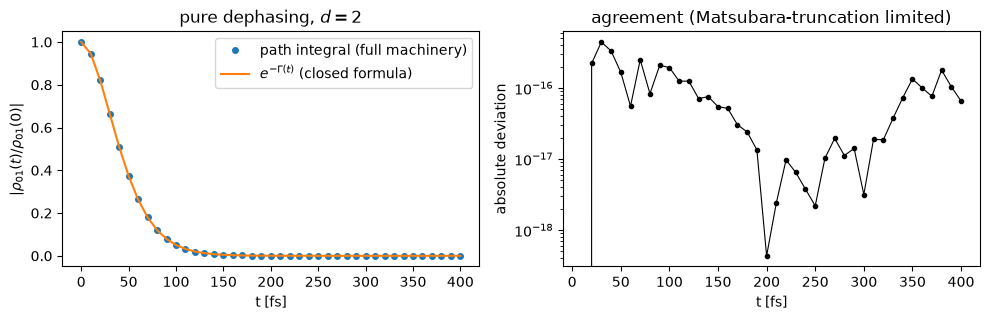

max |path integral - analytic| = 4.440892098500626e-16


In [26]:
# --- pure dephasing: full machinery vs closed formula ---------------------
a, nu = drude_expansion(LAM, GAM, beta, n_mats=200000)

def Gamma_analytic(tau):
    return 2*np.real(np.sum(a*(tau/nu + np.expm1(-nu*tau)/nu**2)))

H2 = np.diag([0.0, 200.0])                     # no hopping -> pure dephasing
pm2 = PathIntegralMap(H2, dt_fs=10.0, kmax=40, lam_cm=LAM, gamma_cm=GAM,
                      T_K=TEMP, eps=0.0, chi_max=4096)   # d=2, exact (eps=0)
maps2 = pm2.run(40, verbose=False)

alpha = 0 + 2*1                                # FB index of rho_01 (d=2)
t_fs2 = 10.0*np.arange(41)
coh_pi = np.array([np.abs(L[alpha, alpha]) for L in maps2])
coh_an = np.array([np.exp(-Gamma_analytic(t*FS_TO_CM)) for t in t_fs2])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.3))
ax1.plot(t_fs2, coh_pi, 'o', ms=4, label='path integral (full machinery)')
ax1.plot(t_fs2, coh_an, '-', label=r'$e^{-\Gamma(t)}$ (closed formula)')
ax1.set_xlabel('t [fs]'); ax1.set_ylabel(r'$|\rho_{01}(t)/\rho_{01}(0)|$')
ax1.legend(); ax1.set_title('pure dephasing, $d=2$')
ax2.semilogy(t_fs2[1:], np.abs(coh_pi - coh_an)[1:], 'k.-', lw=.8)
ax2.set_xlabel('t [fs]'); ax2.set_ylabel('absolute deviation')
ax2.set_title('agreement (Matsubara-truncation limited)')
plt.tight_layout(); plt.show()
print("max |path integral - analytic| =", np.abs(coh_pi - coh_an).max())

## 5. The bath correlation function and its exponential decomposition

### 5.1 $C(t)$ for the Drude bath

Everything the bath does enters through $C(t)$ (Sec. 4.4). For efficient $\eta$-integrals
(Sec. 6) we need it as a **sum of exponentials**. Insert the pole expansion
$\coth x=\frac1x+\sum_{n\ge1}\frac{2x}{x^2+n^2\pi^2}$ into the definition and close the
$\omega$-contour in the upper half plane; the pole of $J$ at $\omega=i\gamma$ and the
Matsubara poles of $\coth(\beta\omega/2)$ at $\omega=i\nu_n$ give, for $t\ge0$,

$$
\boxed{\;C(t)=\underbrace{\lambda\gamma\Big[\cot\big(\tfrac{\beta\gamma}{2}\big)-i\Big]}_{a_0}e^{-\gamma t}
+\sum_{n=1}^{\infty}\underbrace{\frac{4\lambda\gamma}{\beta}\,\frac{\nu_n}{\nu_n^{2}-\gamma^{2}}}_{a_n}\,
e^{-\nu_n t}\;}\qquad
\nu_n=\frac{2\pi n}{\beta}
$$

— the same $c_m e^{-\nu_m t}$ decomposition HEOM is built on ($\nu_1=1310$ cm$^{-1}$
$\hat=$ 4 fs at 300 K: the Matsubara terms are fast corrections on top of the 50 fs Drude
memory).

### 5.2 Two practical caveats (both verified in `selftest.py`)

* **UV behaviour.** Because $J\sim 2\lambda\gamma/\omega$ decays slowly,
  $\mathrm{Re}\,C(t)$ diverges *logarithmically* as $t\to0^+$; correspondingly
  $\sum_n a_n$ diverges harmonically and the series converges only pointwise for $t>0$.
  Every **integrated** quantity we need ($\eta$-coefficients) converges absolutely
  ($\sim\sum n^{-2}$).
* **Truncation.** Truncating at $N$ terms leaves a *relative* error
  $\sim\lambda\gamma\beta\,\Delta\tau/(\pi^2 N)$ in $\eta_0$; with $N=2\times10^5$
  (code default `n_mats`) this is $<10^{-6}$.


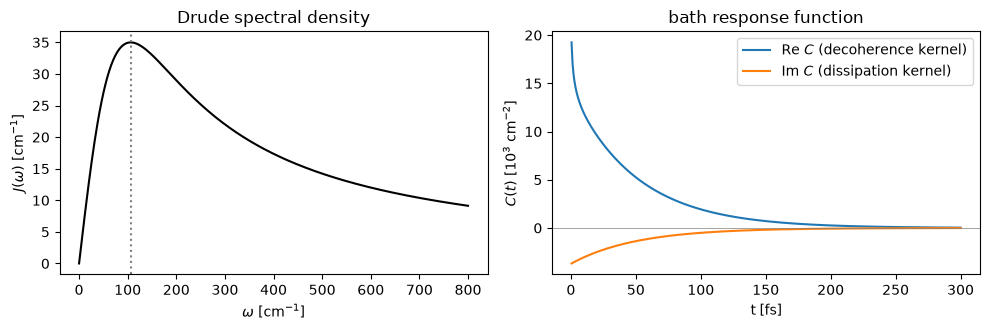

reorg. energy (quadrature) = 34.98817044096287  (should be 35.0 )
max |Im C + lam*gam*e^(-gam t)| = 4.547473508864641e-13


In [27]:
t_fs = np.linspace(0.5, 300, 400)
C = bath_correlation(t_fs * FS_TO_CM, a, nu)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
w = np.linspace(0, 800, 400)
ax1.plot(w, 2*LAM*GAM*w/(w**2+GAM**2), c='k')
ax1.axvline(GAM, ls=':', c='gray'); ax1.set_xlabel(r'$\omega$ [cm$^{-1}$]')
ax1.set_ylabel(r'$J(\omega)$ [cm$^{-1}$]'); ax1.set_title('Drude spectral density')
ax2.plot(t_fs, C.real/1e3, label=r'Re $C$ (decoherence kernel)')
ax2.plot(t_fs, C.imag/1e3, label=r'Im $C$ (dissipation kernel)')
ax2.set_xlabel('t [fs]'); ax2.set_ylabel(r'$C(t)$ [$10^3$ cm$^{-2}$]')
ax2.axhline(0, lw=.5, c='gray'); ax2.legend(); ax2.set_title('bath response function')
plt.tight_layout(); plt.show()

# sum rules:  (1/pi) int J/w dw = lambda ;  Im C(t) = -lam*gam*exp(-gam t) exactly
wq = np.linspace(1e-6, 2e5, 2_000_001)
print("reorg. energy (quadrature) =", np.trapezoid(2*LAM*GAM/np.pi/(wq**2+GAM**2), wq),
      " (should be", LAM, ")")
print("max |Im C + lam*gam*e^(-gam t)| =",
      np.abs(C.imag + LAM*GAM*np.exp(-GAM*t_fs*FS_TO_CM)).max())

In [28]:
# Matsubara truncation convergence at the most sensitive point (small t)
from scipy.integrate import quad
from scipy.special import sici

def C_quad(tau):
    Jf = lambda w: 2*LAM*GAM*w/(w**2+GAM**2)
    reig = lambda w: 4*LAM/(beta*GAM)/np.pi if w == 0 else Jf(w)/np.pi/np.tanh(beta*w/2)
    W = 2e4
    re = quad(reig, 0, W, weight='cos', wvar=tau, limit=2000)[0] \
         - (2*LAM*GAM/np.pi)*sici(W*tau)[1]
    return re + 1j*(-LAM*GAM*np.exp(-GAM*tau))

tau = 2.0 * FS_TO_CM
ref = C_quad(tau)
for N in (100, 1000, 10000, 200000):
    aN, nuN = drude_expansion(LAM, GAM, beta, n_mats=N)
    cN = bath_correlation(tau, aN, nuN)[0]
    print(f"N = {N:6d}:  rel. error of C(2 fs) = {abs(cN-ref)/abs(ref):.2e}")

N =    100:  rel. error of C(2 fs) = 3.85e-07
N =   1000:  rel. error of C(2 fs) = 3.85e-07
N =  10000:  rel. error of C(2 fs) = 3.85e-07
N = 200000:  rel. error of C(2 fs) = 3.85e-07


## 6. Discretization: Trotter splitting and the $\eta$-coefficients

### 6.1 Quasi-adiabatic propagator splitting

The path sum of Sec. 4.1 is exact for any $N$, but the one-step matrix elements
$\langle s_k|e^{-iH\Delta t}|s_{k-1}\rangle$ of the *full* $H = H_0 + H_B + H_{\rm coup}$  are unknown. Following
QUAPI/TEMPO, split symmetrically

$$
e^{-iH\Delta t}\;\approx\;e^{-iH_0\Delta t/2}\;e^{-i(H_B+H_{\rm coup})\Delta t}\;e^{-iH_0\Delta t/2}
\qquad(\text{error } \mathcal{O}(\Delta t^{3})\ \text{per step}),
$$

so that within each window the coupling eigenvalue — i.e. the path — is **piecewise
constant**: $s(t')=s_k$ for $t'\in[(k-1)\Delta t,k\Delta t]$. ("Quasi-adiabatic": the
splitting is exact in the limit where the system moves slowly compared to the slice
length; the error is a controlled Trotter error, extrapolated away by comparing
$\Delta t = 10$ vs $5$ fs in Sec. 11.)

Anstatt das System und das Bad gleichzeitig zu entwickeln, wird die Zeitentwicklung eines Schrittes $\Delta t$ in drei nacheinander ablaufende Phasen zerhackt:
- Schritt 1 (Zeit $\Delta t/2$): Das isolierte System entwickelt sich nur nach $H_0$. Das Bad ist ignoriert.
- Schritt 2 (Zeit $\Delta t$): Das System friert ein, und nur das Bad sowie die Wechselwirkung $H_B+H_{\rm coup}$ entwickeln sich.
- Schritt 3 (Zeit $\Delta t/2$): Das System darf sich noch einmal isoliert für den Rest der Zeit weiterentwickeln.

Wenn man das Matrixelement $\langle s_k \vert{} \dots \vert{} s_{k-1} \rangle$ mit dieser aufgespaltenen Form berechnet, steht der mittlere Operator $e^{-i(H_B+H_{\rm coup})\Delta t}$ völlig alleine da, ungestört von $H_0$.Da $H_0$ in diesem mittleren Teil fehlt, gibt es nichts, was das System dazu bringen könnte, seinen Zustand zu wechseln. Das System ist in diesem Zeitfenster gewissermaßen gelähmt.Das führt zu der stückweise konstanten (piecewise constant) Näherung:Für die gesamte Dauer dieses Intervalls $t' \in [(k-1)\Delta t, k\Delta t]$ bleibt das System exakt auf der Site $s_k$ sitzen. Die Kopplungsvariable ist nicht mehr eine kontinuierliche Funktion $s(t')$, sondern ein starrer Block: $s(t') = s_k$.Das Bad "sieht" das System also nicht flüssig wandern, sondern wie bei einem Daumenkino in diskreten, eingefrorenen Posen. Man nennt das "quasi-adiabatisch", weil das System im Vergleich zum Bad in diesem kurzen Zeitfenster als unendlich langsam (adiabatisch) und starr angenommen wird.

### 6.2 The influence functional becomes a finite sum

Wir betrachten den komplexen Exponenten (die Phase) des Einflussfunktionals, den wir als $\Phi$ definieren:$$\Phi = \int_0^t dt' \int_0^{t'} dt'' \big[s^+(t') - s^-(t')\big] \big[C(t'-t'') s^+(t'') - C^*(t'-t'') s^-(t'')\big]$$Um dieses Integral zu diskretisieren, zerteilen wir die Gesamtzeit $t$ in $N$ identische Zeitfenster der Länge $\Delta t$. Das $k$-te Zeitfenster definieren wir als das Intervall:$$I_k = \big[ (k-1)\Delta t, \, k\Delta t \big] \quad \text{für } k = 1, 2, \dots, N$$Die Trotter-Aufspaltung erlaubt uns die quasi-adiabatische Näherung: Wir nehmen an, dass die Systempfade innerhalb eines jeden Zeitfensters $I_k$ exakt konstant sind.$$s^\pm(t) = s_k^\pm \quad \text{für } t \in I_k$$ Das Integrationsgebiet ist das Dreieck $0 \le t'' \le t' \le t$ (da wir oben in $\Phi$ von die Integrationsgrenzen so gewählt haben). Wir können das kontinuierliche Doppelintegral als eine diskrete Doppelsumme über alle möglichen Paare von Zeitfenstern $(k, k')$ schreiben. Da $t''$ nie größer als $t'$ sein darf, kann der Index $k'$ maximal den Wert des aktuellen Index $k$ annehmen ($k' \le k$):$$\Phi = \sum_{k=1}^N \sum_{k'=1}^k \iint_{\text{Kachel } (k,k')} dt' dt'' \big[s_k^+ - s_k^-\big] \big[C(t'-t'') s_{k'}^+ - C^*(t'-t'') s_{k'}^-\big]$$

Eine Kachel ist die Kombination aus zwei Zeitintervallen.
- Das einzelne Zeitintervall $I_k$ ist ein eindimensionaler Zeitabschnitt auf der Zeitachse (z. B. von $20\text{ fs}$ bis $30\text{ fs}$ für das dritte Intervall, wenn $\Delta t = 10\text{ fs}$).
- Da wir ein Doppelintegral über zwei Zeiten ($t'$ und $t''$) berechnen, spannen diese beiden Zeitachsen eine zweidimensionale Fläche auf. Eine Kachel $(k, k')$ ist ein zweidimensionales Quadrat (oder auf der Diagonalen ein Dreieck) auf dieser Fläche. Sie repräsentiert die Fläche, auf der die aktuelle Zeit $t'$ im Intervall $I_k$ liegt und die vergangene Zeit $t''$ im Intervall $I_{k'}$ liegt.

$s_k$ ist kein kontinuierlicher Weg, sondern der feste Zustand des Systems während des gesamten Zeitintervalls $I_k$.Durch die Trotter-Aufspaltung nutzen wir die sogenannte quasi-adiabatische Näherung. Das bedeutet, wir nehmen an, dass das System innerhalb eines kurzen Zeitfensters $I_k$ (z. B. für die Dauer von $10\text{ fs}$) wie eingefroren auf einem einzigen Zustand verweilt.
- $s_k^+$ ist die konkrete Site (z. B. BChl-Molekül 1, 2, 3 oder 4), auf der das Exziton im Zeitfenster $k$ auf dem Vorwärtspfad (Ket) sitzt.
- $s_k^-$ ist die Site, auf der das Exziton im selben Zeitfenster $k$ auf dem Rückwärtspfad (Bra) sitzt.

Wenn dein Pfad für die ersten drei Zeitintervalle lautet: $s^+ = (1, 1, 2)$, dann bedeutet das:
- In Intervall 1 ($k=1$): Das System verweilt fest auf Site $s_1^+ = 1$.
- In Intervall 2 ($k=2$): Das System verweilt immer noch fest auf Site $s_2^+ = 1$.
- In Intervall 3 ($k=3$): Das System ist gesprungen und verweilt nun fest auf Site $s_3^+ = 2$.

Da die Systempfade $s_k^\pm$ und $s_{k'}^\pm$ auf der Kachel also exakt konstant sind, können wir sie als gewöhnliche skalare Faktoren komplett aus den Integralen herausziehen. Die verbleibende Struktur klammert reine Bad-Integrale ein:$$\Phi = \sum_{k=1}^N \sum_{k'=1}^k \big(s_k^+ - s_k^-\big) \left[ s_{k'}^+ \iint_{\text{Kachel}} dt' dt'' C(t'-t'') - s_{k'}^- \iint_{\text{Kachel}} dt' dt'' C^*(t'-t'') \right]$$Nun müssen wir nur noch diese reinen Bad-Integrale für zwei topologisch unterschiedliche Kachel-Arten berechnen: die Diagonale ($k = k'$) und die Nebendiagonalen ($k > k'$).

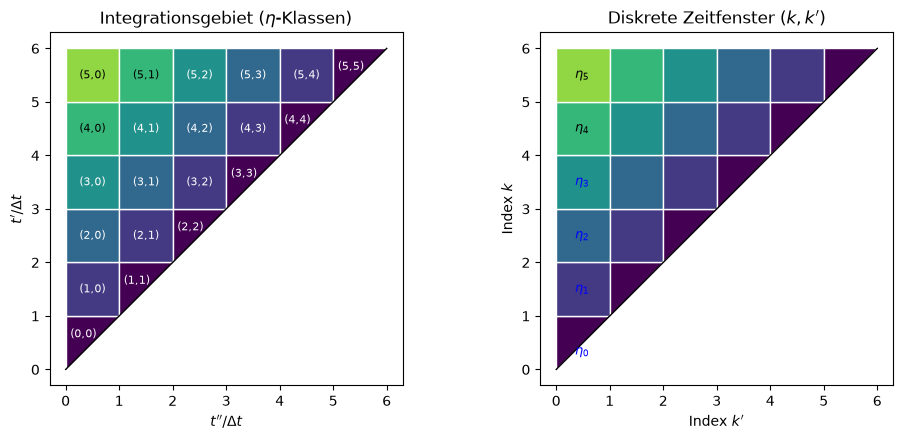

In [29]:
import matplotlib.pyplot as plt

# Parameter
dt_fs = 10.0
FS_TO_CM = 1.0 
dtau = dt_fs * FS_TO_CM
Nshow = 6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

for k in range(Nshow):
    for kp in range(k + 1):
        dk = k - kp
        colr = plt.cm.viridis(dk / Nshow)
        
        # Kacheln in BEIDEN Plots zeichnen
        for ax in (ax1, ax2):
            if dk == 0:
                ax.fill([kp, kp, kp+1], [kp, kp+1, kp+1], color=colr, ec='w', lw=1)
            else:
                ax.fill([kp, kp+1, kp+1, kp], [k, k, k+1, k+1], color=colr, ec='w', lw=1)
        
        # Beschriftung LINKS (Kacheln & Indizes)
        text_col = 'white' if dk < 4 else 'black'
        if dk == 0:
            ax1.text(kp + 0.33, k + 0.66, f"({k},{kp})", 
                     ha='center', va='center', fontsize=8, color=text_col)
        else:
            ax1.text(kp + 0.5, k + 0.5, f"({k},{kp})", 
                     ha='center', va='center', fontsize=8, color=text_col)
            
        # Beschriftung RECHTS (Eta-Klassen)
        if kp == 0:
            ax2.text(0.35, k + 0.45 if dk else 0.28, rf'$\eta_{{{dk}}}$',
                     fontsize=9, color='b' if dk < 4 else 'k')

# Formatierung rechter Plot (Fokus auf physikalische Zeit)
ax1.plot([0, Nshow], [0, Nshow], 'k-', lw=1)
ax1.set_aspect('equal')
ax1.set_xlabel(r"$t''/\Delta t$")
ax1.set_ylabel(r"$t'/\Delta t$")
ax1.set_title(r"Integrationsgebiet ($\eta$-Klassen)")

# Formatierung linker Plot (Fokus auf Kachel-Indizes)
ax2.plot([0, Nshow], [0, Nshow], 'k-', lw=1)
ax2.set_aspect('equal')
ax2.set_xlabel(r"Index $k'$")
ax2.set_ylabel(r"Index $k$")
ax2.set_title(r"Diskrete Zeitfenster $(k, k')$")



plt.tight_layout()
plt.show()

**Auswertung der Diagonalen-Kacheln ($k = k'$):** 

Auf der Diagonalen liegen die Zeiten $t'$ und $t''$ im exakt selben Zeitfenster $I_k$. Das Integrationsgebiet ist das Dreieck $t'' \le t'$.Wir transformieren die absoluten Zeiten $t'$ und $t''$ in relative Kachel-Koordinaten $s$ und $s'$, die jeweils bei $0$ am Anfang des Fensters starten:
- $t'(s) = (k-1)\Delta t + s$  (wobei $s$ von $0$ bis $\Delta t$ läuft)
- $t''(s') = (k-1)\Delta t + s'$ (wobei $s'$ von $0$ bis $s$ läuft, da $t'' \le t'$)

Die Zeitdifferenz ist einfach $t' - t'' = s - s'$. Das Integral für den Vorfaktor $\eta_0$ lautet:$$\begin{aligned} \eta_0 &= \int_{(k-1)\Delta t}^{k\Delta t} dt' \int_{(k-1)\Delta t}^{t'} dt'' \, C(t'-t'') \\ &= \int_0^{\Delta t} ds \int_0^s ds' \, C\big( ((k-1)\Delta t + s) - ((k-1)\Delta t + s') \big) \\ &= \int_0^{\Delta t} ds \int_0^s ds' \, C(s - s') \end{aligned}$$
Hier haben wir verwendet dass $\frac{dt'}{ds} = \frac{dt''}{ds'}=1$ Wie man sieht, fällt der Index $k$ vollständig heraus. Die Konstante $\eta_0$ ist für jedes Zeitfenster auf der Diagonalen exakt gleich.

**Auswertung der Off-Diagonalen-Kacheln ($k > k'$):**

Wenn $k > k'$ ist, liegt das Zeitfenster $t''$ komplett in der Vergangenheit von $t'$. Es gibt hier keine Einschränkung $t'' \le t'$ mehr innerhalb der Kachel, denn das gesamte Fenster $k'$ liegt vor dem Fenster $k$. Das Integrationsgebiet ist hier ein volles Quadrat der Größe $\Delta t \times \Delta t$.Wir definieren den zeitlichen Gitter-Abstand als $\Delta k = k - k'$ und transformieren wieder in relative Koordinaten:
- $t'(s) = (k-1)\Delta t + s$  (wobei $s \in [0, \Delta t]$)
- $t''(s') = (k'-1)\Delta t + s'$ (wobei $s' \in [0, \Delta t]$)

Wir bilden die Differenz der Zeiten:$$t' - t'' = \big( (k-1)\Delta t + s \big) - \big( (k'-1)\Delta t + s' \big) = (k - k')\Delta t + s - s' = \Delta k \Delta t + s - s'$$Das Integral für diese Quadrat-Kachel $\eta_{\Delta k}$ werten wir nun aus:$$\begin{aligned} \eta_{k-k'} &= \int_{(k-1)\Delta t}^{k\Delta t} dt' \int_{(k'-1)\Delta t}^{k'\Delta t} dt'' \, C(t'-t'') \\ &= \int_0^{\Delta t} ds \int_0^{\Delta t} ds' \, C\big( ((k-1)\Delta t + s) - ((k'-1)\Delta t + s') \big) \\ &= \int_0^{\Delta t} ds \int_0^{\Delta t} ds' \, C( \Delta k \Delta t + s - s' ) \end{aligned}$$Auch hier hängt das Integral nur noch von der relativen Distanz $\Delta k$ ab, nicht von den absoluten Zeiten.


Wir ersetzen nun die reinen Bad-Integrale in unserer aufgespaltenen Doppelsumme durch die Definitionen von $\eta_{k-k'}$. (Das Integral über $C^*$ ist identisch zu $\eta_{k-k'}^*$, da die Integrationsgrenzen reell sind).$$\begin{aligned} \Phi &= \sum_{k=1}^N \sum_{k'=1}^k \big(s_k^+ - s_k^-\big) \left[ s_{k'}^+ \left( \iint dt' dt'' C(t'-t'') \right) - s_{k'}^- \left( \iint dt' dt'' C^*(t'-t'') \right) \right] \\ \Phi &= \sum_{k=1}^N \sum_{k'=1}^k \big(s_k^+ - s_k^-\big) \Big( \eta_{k-k'} \, s_{k'}^+ - \eta_{k-k'}^* \, s_{k'}^- \Big) \end{aligned}$$Das diskretisierte Einflussfunktional ist dann schlicht $I = \exp\left\{-\frac{1}{\hbar} \Phi\right\}$:$$\boxed{ I = \exp\Bigg\{ -\frac{1}{\hbar} \sum_{k=1}^N \sum_{k'=1}^k \big(s_k^+ - s_k^-\big) \Big( \eta_{k-k'} \, s_{k'}^+ - \eta_{k-k'}^* \, s_{k'}^- \Big) \Bigg\} }$$Diese Formulierung ist hochgradig effizient. Anstatt während der System-Propagation mühsam Integrale lösen zu müssen, reduziert sich die Wirkung des hochkomplexen Bades auf einen vorab berechneten eindimensionalen Array von skalaren Konstanten $\eta = [\eta_0, \eta_1, \eta_2, \dots, \eta_{N-1}]$. Die Doppelsumme im Exponenten lässt sich dann im Code durch einfache Tensor-Kontraktionen oder vektorisierte Array-Operationen berechnen, was die Implementierung massiv beschleunigt.


Substituting the piecewise-constant paths into the boxed exponent of Sec. 4.4, the double
*integral* over $(t',t'')$ splits into a double *sum* over window pairs,

$$
I=\exp\Big\{-\frac{1}{\hbar}\sum_{k\ge k'}\big(s_k^+-s_k^-\big)
\big(\eta_{kk'}\,s_{k'}^+-\eta^*_{kk'}\,s_{k'}^-\big)\Big\},
$$

where each coefficient is the integral of $C$ over one **tile** of the triangular
integration domain $\{0<t''<t'<t\}$ (see the figure below): squares for $k>k'$, triangles
on the diagonal for $k=k'$. Time-translation invariance makes them depend only on
$\Delta k=k-k'$:

$$
\eta_0=\int_0^{\Delta\tau}\!\!ds\int_0^{s}\!ds'\,C(s-s'),
\qquad
\eta_{\Delta k}=\int_0^{\Delta\tau}\!\!ds\int_0^{\Delta\tau}\!\!ds'\,
C(\Delta k\,\Delta\tau+s-s'),\quad \Delta k\ge1 .
$$

Note what is and is not approximated: **the bath integration stays exact** — the only
approximation is that paths are sampled on the $\Delta t$ grid (Trotter). For paths that
truly are constant (Sec. 4.6) the tiling is exact and the discretized influence functional
reproduces the continuum result to machine precision.


### 6.3 Analytic evaluation for exponential $C$

**1. Auswertung der Diagonal-Kachel ($\eta_0$)**


With the exponential form of the BCF $C(\tau)=\sum_m a_m e^{-\nu_m\tau}$ the tile integrals are elementary:

Das Integral für das Zeitfenster auf der Diagonalen lautet:$$\eta_0 = \int_0^{\Delta\tau} ds \int_0^{s} ds' \, C(s-s')$$Wir setzen den $m$-ten Term der Korrelationsfunktion ein:$$\eta_0 = \sum_m a_m \int_0^{\Delta\tau} ds \int_0^{s} ds' \, e^{-\nu_m(s-s')}$$Schritt 1.1: Das innere Integral über $s'$ lösenDa im inneren Integral über $s'$ integriert wird, können wir $e^{-\nu_m s}$ als Konstante betrachten:$$\int_0^{s} e^{-\nu_m(s-s')} ds' = e^{-\nu_m s} \int_0^{s} e^{\nu_m s'} ds'$$Wir bilden die Stammfunktion für $e^{\nu_m s'}$:$$e^{-\nu_m s} \left[ \frac{1}{\nu_m} e^{\nu_m s'} \right]_{0}^{s} = e^{-\nu_m s} \frac{1}{\nu_m} \left( e^{\nu_m s} - e^0 \right) = \frac{1}{\nu_m} \left( e^{-\nu_m s} e^{\nu_m s} - e^{-\nu_m s} \right) = \frac{1}{\nu_m} \left( 1 - e^{-\nu_m s} \right)$$Schritt 1.2: Das äußere Integral über $s$ lösenNun setzen wir dieses Ergebnis in das äußere Integral ein:$$\int_0^{\Delta\tau} \frac{1}{\nu_m} \left( 1 - e^{-\nu_m s} \right) ds = \frac{1}{\nu_m} \left[ s - \left( -\frac{1}{\nu_m} e^{-\nu_m s} \right) \right]_0^{\Delta\tau}=\frac{1}{\nu_m} \left( \left( \Delta\tau + \frac{1}{\nu_m} e^{-\nu_m \Delta\tau} \right) - \left( 0 + \frac{1}{\nu_m} e^0 \right) \right)=\frac{1}{\nu_m^2} \left( \nu_m \Delta\tau + e^{-\nu_m \Delta\tau} - 1 \right)$$Ergebnis für $\eta_0$:Wenn wir nun die Summe und die Vorfaktoren $a_m$ wieder hinzufügen, erhalten wir:$$\eta_0 = \sum_m \frac{a_m}{\nu_m^2} \Big( \nu_m\Delta\tau + e^{-\nu_m\Delta\tau} - 1 \Big)$$

**2. Auswertung der Nebendiagonal-Kacheln ($\eta_{\Delta k}$ für $\Delta k \ge 1$)**

Für alle Zeitfenster abseits der Diagonalen haben wir ein volles Quadrat als Integrationsgebiet:$$\eta_{\Delta k} = \int_0^{\Delta\tau} ds \int_0^{\Delta\tau} ds' \, C(\Delta k\Delta\tau + s - s')$$Wir setzen wieder den $m$-ten Term ein und nutzen die Potenzgesetze, um den Exponenten vollständig aufzuspalten:$$\eta_{\Delta k} = \sum_m a_m \int_0^{\Delta\tau} ds \int_0^{\Delta\tau} ds' \, e^{-\nu_m \Delta k \Delta\tau} \cdot e^{-\nu_m s} \cdot e^{+\nu_m s'} = e^{-\nu_m \Delta k \Delta\tau} \left( \int_0^{\Delta\tau} e^{-\nu_m s} ds \right) \left( \int_0^{\Delta\tau} e^{\nu_m s'} ds' \right)$$

Schritt 2.2: Auswertung der beiden EinzelintegraleDas Integral über $s$:$$\int_0^{\Delta\tau} e^{-\nu_m s} ds = \left[ -\frac{1}{\nu_m} e^{-\nu_m s} \right]_0^{\Delta\tau} = -\frac{1}{\nu_m} \left( e^{-\nu_m \Delta\tau} - 1 \right) = \frac{1}{\nu_m} \left( 1 - e^{-\nu_m \Delta\tau} \right)$$Das Integral über $s'$:$$\int_0^{\Delta\tau} e^{\nu_m s'} ds' = \left[ \frac{1}{\nu_m} e^{\nu_m s'} \right]_0^{\Delta\tau} = \frac{1}{\nu_m} \left( e^{\nu_m \Delta\tau} - 1 \right)$$

Schritt 2.3: Zusammenfügen und algebraische UmformungDas Produkt der beiden Integrale ergibt:$$\frac{1}{\nu_m^2} \left( 1 - e^{-\nu_m \Delta\tau} \right) \left( e^{\nu_m \Delta\tau} - 1 \right)$$Jetzt kommt der entscheidende Trick bei der Umformung: Wir möchten die Therme so umordnen, dass wir das Quadrat $(1 - e^{-\nu_m \Delta\tau})^2$ erhalten. Dafür klammern wir aus dem zweiten Term $e^{\nu_m \Delta\tau}$ aus:$$\left( e^{\nu_m \Delta\tau} - 1 \right) = e^{\nu_m \Delta\tau} \left( 1 - e^{-\nu_m \Delta\tau} \right)$$Damit wird unser Integralprodukt zu:$$\frac{1}{\nu_m^2} \, e^{\nu_m \Delta\tau} \left( 1 - e^{-\nu_m \Delta\tau} \right)^2$$Jetzt multiplizieren wir noch den Kachel-Offset $e^{-\nu_m \Delta k \Delta\tau}$ (den wir in Schritt 2.1 nach vorne gezogen haben) wieder dazu:$$e^{-\nu_m \Delta k \Delta\tau} \cdot e^{\nu_m \Delta\tau} = e^{-\nu_m \Delta\tau (\Delta k - 1)}$$Ergebnis für $\eta_{\Delta k}$:Setzen wir nun alles mit der Summe über $m$ zusammen, ergibt sich die finale Formel:$$\eta_{\Delta k} = \sum_m \frac{a_m}{\nu_m^2} \, e^{-\nu_m (\Delta k - 1) \Delta\tau} \Big( 1 - e^{-\nu_m\Delta\tau} \Big)^2$$


$$
\eta_0=\sum_m \frac{a_m}{\nu_m^{2}}\Big(\nu_m\Delta\tau+e^{-\nu_m\Delta\tau}-1\Big),
\qquad
\eta_{\Delta k}=\sum_m \frac{a_m}{\nu_m^{2}}\,
e^{-\nu_m(\Delta k-1)\Delta\tau}\Big(1-e^{-\nu_m\Delta\tau}\Big)^{2}.
$$


### 6.4 Memory truncation

$|\eta_{\Delta k}|$ inherits the exponential decay of $C$
($e^{-\gamma\Delta k\Delta\tau}$ from the Drude pole; Matsubara terms die within one
slice). Beyond a **memory window** of $K$ steps ($K\Delta t=t_{\rm mem}$) the pair
couplings are dropped — the discrete analogue of "the bath forgets after a few
correlation times". Production: $t_{\rm mem}=250\ \mathrm{fs}=5\gamma^{-1}$; pushing to
350 fs changes the populations by $<3\times10^{-4}$ (Sec. 11).

**Genauer:**

Die Formel für die Nebendiagonal-Kacheln lautet:$$\eta_{\Delta k} = \sum_m \underbrace{\frac{a_m}{\nu_m^{2}}}_{\text{Amplitude}} \, \underbrace{e^{-\nu_m(\Delta k-1)\Delta\tau}}_{\text{Zerfalls-Faktor}} \, \underbrace{\Big(1-e^{-\nu_m\Delta\tau}\Big)^{2}}_{\text{Lokale Kachel-Konstante}}$$Hier ist der Zerfalls-Faktor $e^{-\nu_m(\Delta k-1)\Delta\tau}$ der entscheidende Teil. Er hängt als einziger Term von der zeitlichen Distanz $\Delta k = k - k'$ zwischen dem aktuellen Zeitfenster $k$ und dem vergangenen Zeitfenster $k'$ ab.

Warum wir die Summe in $I$ abbrechen können: Das Einflussfunktional $I$ berechnet sich aus einer Doppelsumme über alle aktuellen Zeiten $k$ und alle vergangenen Zeiten $k'$ bis zurück zum Startpunkt $k'=1$. Die Konstante $\eta_{\Delta k}$ gewichtet dabei, wie stark die Vergangenheit in die Gegenwart hineinwirkt.Wenn wir den Index $m=0$ (den Drude-Pol) betrachten, ist $\nu_0 = \gamma$. Der Zerfallsfaktor für die makroskopische Bad-Reorganisation lautet also $e^{-\gamma(\Delta k-1)\Delta\tau}$.
- Je weiter $k'$ in der Vergangenheit liegt, desto größer wird $\Delta k$.
- Da $\Delta k$ linear wächst, schrumpft der Term $e^{-\gamma(\Delta k-1)\Delta\tau}$ exponentiell gegen Null.
- Für die Matsubara-Terme ($m \ge 1$) ist $\nu_m$ so groß, dass dieser Term bereits für $\Delta k = 2$ praktisch exakt Null ist.

Ab einem gewissen zeitlichen Abstand $K$ (dem "Memory Window") ist der Exponent so negativ, dass der Taschenrechner (oder Computer) für den gesamten Term $\eta_{\Delta k}$ schlicht $0.0000\dots$ auswertet.Wenn $\eta_{\Delta k} \approx 0$ ist, liefert dieser Summand keinen Beitrag mehr zur großen Doppelsumme $\Phi$ im Exponenten des Einflussfunktionals:$$I = \exp\Bigg\{ -\frac{1}{\hbar} \sum_{k=1}^N \sum_{k'=1}^{k} \big( \dots \eta_{\Delta k} \dots \big) \Bigg\}$$Anstatt also für den aktuellen Zeitschritt $k$ die innere Summe über $k'$ mühsam bis ganz an den Anfang ($k'=1$) durchzurechnen, bricht man die innere Summe einfach bei $k' = k - K$ ab. Alles, was noch weiter zurückliegt, wird mit null gewichtet und ist physikalisch irrelevant ("Das Bad hat es vergessen"). Das reduziert den Rechenaufwand der Simulation drastisch von $O(N^2)$ auf $O(N \cdot K)$.

Was bedeutet die Differenz von $< 3 \times 10^{-4}$? Dieser Wert ist ein klassischer numerischer Konvergenztest. Man muss beweisen, dass das gewählte Abschneiden bei $t_{\rm mem} = 250\text{ fs}$ (also das Ignorieren aller Kacheln, die älter als $250\text{ fs}$ sind) die Physik nicht verfälscht.Dafür führt man die Simulation zweimal durch:
- Simulation A: Man bricht die Summe bei einem Gedächtnis von $250\text{ fs}$ ab. Alle $\eta_{\Delta k}$ für ältere Zeiten werden hart auf $0$ gesetzt.
- Simulation B: Man rechnet deutlich weiter in die Vergangenheit und nimmt alle $\eta_{\Delta k}$ bis zu einem Gedächtnis von $350\text{ fs}$ mit. Das heißt, man addiert winzig kleine, aber nicht exakt null betragende $\eta$-Werte im Bereich zwischen $250\text{ fs}$ und $350\text{ fs}$ dazu.

Am Ende der Simulation betrachtet man die physikalische Observable, für die man sich interessiert: Die Populationen (also die Diagonalelemente der reduzierten Dichtematrix, die angeben, mit welcher Wahrscheinlichkeit das Exziton auf BChl 1, 2 oder 3 sitzt). Da Wahrscheinlichkeiten Werte zwischen $0$ und $1$ sind, sagt die Angabe $< 3 \times 10^{-4}$ folgendes aus:Die errechnete Wahrscheinlichkeit (z.B. $P = 0.7421...$) aus Simulation A unterscheidet sich von Simulation B erst in der vierten Nachkommastelle (z.B. $P = 0.7423...$). Die durch das frühere Abschneiden weggelassenen $\eta$-Terme verändern das finale physikalische Ergebnis also um maximal $0.03\%$. Das ist numerisches Grundrauschen und rechtfertigt, das Gedächtnis aggressiv bei $250\text{ fs}$ abzuschneiden, um Rechenzeit zu sparen.

/tmp/ipykernel_934/2334278247.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.xlabel(r'$\Delta k$  (at $\Delta t=10$ fs)'); plt.legend(); plt.tight_layout(); plt.show()


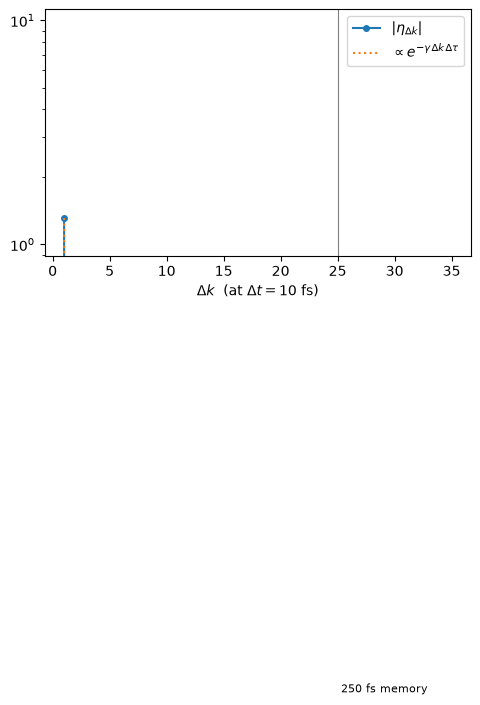

eta_0 = (1373.353200674352-349.6703710679978j)    eta_1 = (1.2681827945908621-0.3296289320022603j)


In [42]:
K = 25
eta = eta_coefficients(a, nu, dtau, K + 10)
plt.figure(figsize=(5.5, 3.2))
plt.semilogy(np.arange(1, K + 11), np.abs(eta[1:]), 'o-', ms=4,
             label=r'$|\eta_{\Delta k}|$')
plt.semilogy(np.arange(1, K + 11),
             np.abs(eta[1]) * np.exp(-GAM * dtau * (np.arange(1, K + 11) - 1)),
             ':', label=r'$\propto e^{-\gamma\,\Delta k\,\Delta\tau}$')
plt.axvline(K, c='gray', lw=.8); plt.text(K + .3, 1e-2, '250 fs memory', fontsize=8)
plt.xlabel(r'$\Delta k$  (at $\Delta t=10$ fs)'); plt.legend(); plt.tight_layout(); plt.show()
print("eta_0 =", eta[0], "   eta_1 =", eta[1])

## 7. Site-projector couplings: collapse to Kronecker deltas

Wenn man die zeitliche Dynamik des Gesamtsystems (System + Bad) betrachtet und die unzähligen, unbeobachteten Freiheitsgrade des Bades mathematisch herausintegriert (partielle Spur über das Bad), erhält man die exakte Pfadintegraldarstellung für die reduzierte Dichtematrix:$$\rho_S(s_f^+, s_f^-, t) = \int \mathcal{D}[s^+] \int \mathcal{D}[s^-] \, e^{\frac{i}{\hbar} \left(S_S[s^+] - S_S[s^-]\right)} \, \mathbf{I[s^+, s^-]} \, \rho_S(s_0^+, s_0^-, 0)$$

Die Komponenten dieser Formel im Detail:
- Die Summe über alle Historien ($\int \mathcal{D}[s^+] \int \mathcal{D}[s^-]$):Das System entwickelt sich nicht auf einem einzigen Pfad. Stattdessen wird über alle denkbaren Kombinationen von Pfaden summiert. $s^+(t')$ beschreibt dabei den Vorwärtspfad (die zeitliche Entwicklung des Ket-Vektors) und $s^-(t')$ den Rückwärtspfad (die Entwicklung des Bra-Vektors).- Die isolierte System-Dynamik ($e^{\frac{i}{\hbar} (S_S[s^+] - S_S[s^-])}$):Dieser Vorfaktor wird rein durch den elektronischen System-Hamiltonian $H_0$ (bzw. $H_S$) bestimmt. Er liefert die quantenmechanische Grund-Amplitude und Phase für jedes Pfadpaar, als wäre kein Bad vorhanden.
- Das Einflussfunktional ($I[s^+, s^-]$) als Gewichtungsfaktor:Genau hier greift die Umgebung ein. Das Einflussfunktional ordnet jedem einzelnen Pfadpaar $(s^+, s^-)$ ein komplexes Gewicht zu. Es fungiert als ein zeitlich nicht-lokaler Filter.

Was macht $I[s^+, s^-]$ physikalisch in der Dynamik?

Das Bad filtert die Pfadpaare basierend auf der Differenzkoordinate $\xi(t') = s^+(t') - s^-(t')$:
- Auf der Diagonale ($\xi = 0$): Wenn der Vorwärtspfad und der Rückwärtspfad exakt identisch sind ($s^+ = s^-$), wird der Exponent des Einflussfunktionals null, was $I = 1$ ergibt. Das bedeutet: Reine Wahrscheinlichkeiten (Populationen) werden vom Bad an dieser Stelle nicht direkt gedämpft.
- Abseits der Diagonale ($\xi \neq 0$): Sobald das System eine Quantensuperposition (Kohärenz) eingeht und Vorwärts- und Rückwärtspfad auseinanderlaufen (d.h. Bra und ket sind unterscheidlich -> $\langle i | \rho | j \rangle$) -> offdiagonalterm), schlägt das Einflussfunktional zu. Seine mathematische Struktur bewirkt zwei fundamentale Dinge:
    - Dekohärenz (Realteil von $C$): Es multipliziert die Amplitude dieses Pfadpaares mit einem reellen, gaußförmigen Dämpfungsfaktor. Das sorgt dafür, dass weit auseinanderliegende Pfade in der gigantischen Summe extrem schnell weggedämpft werden (die Dichtematrix wird auf die Diagonale gezwungen).
    - Dissipation / Reibung (Imaginärteil von $C$): Es fügt eine zusätzliche quantenmechanische Phase hinzu. Diese beschreibt die physikalische Rückwirkung ("Back-action"): Das System hat in der Vergangenheit das Bad ausgelenkt, und diese Bad-Schwingung schlägt zu einer späteren Zeit als Reibungskraft auf das System zurück, was zu Energieverlust und thermischer Relaxation führt.

In der obigen Formel steht das fettgedruckte $\mathbf{I[s^+, s^-]}$ für das gesamte Einflussfunktional der Umgebung. Wenn jede deiner 4 Sites $j$ an ihr eigenes, lokales und unabhängiges Bad gekoppelt ist, faktorisiert diese totale Spur über die Umgebungen. Das bedeutet, das totale Einflussfunktional ist das Produkt der Einflussfunktionale der einzelnen Bäder $j$:$$I[s^+, s^-] = \prod_{j=1}^{4} I_j[s^+, s^-]$$Setzen wir nun für jedes einzelne Bad $j$ die kontinuierliche, eingeboxtes Integralformel ein, erhalten wir:$$I[s^+, s^-] = \prod_{j=1}^{4} \exp\Bigg\{ -\frac{1}{\hbar}\int_0^t\! dt'\int_0^{t'}\!\!dt''\, \big[s_j^+(t')-s_j^-(t')\big]\big[C(t'-t'')\,s_j^+(t'')-C^*(t'-t'')\,s_j^-(t'')\big] \Bigg\}$$

Da das Produkt von Exponentialfunktionen der Summe ihrer Exponenten entspricht ($e^A \cdot e^B = e^{A+B}$), zieht das Produkt über die Bäder $j$ als Summe in den Exponenten hinein:$$I[s^+, s^-] = \exp\Bigg\{ -\frac{1}{\hbar} \sum_{j=1}^{4} \int_0^t\! dt'\int_0^{t'}\!\!dt''\, \big[s_j^+(t')-s_j^-(t')\big]\big[C(t'-t'')\,s_j^+(t'')-C^*(t'-t'')\,s_j^-(t'')\big] \Bigg\}$$

Wenn man nun noch die BCF $C(t)$ diskretisiert und die Summer über die Kacheln erhält, haben wir:
$$I = \exp\Bigg\{ -\frac{1}{\hbar} \sum_{k=1}^N \sum_{k'=1}^k \sum_{j=1}^{4} \big(s_{j,k}^+ - s_{j,k}^-\big) \Big( \eta_{\Delta k} \, s_{j,k'}^+ - \eta^*_{\Delta k} \, s_{j,k'}^- \Big) \Bigg\}$$

Im Pfadintegral-Formalismus zerlegen wir die Zeitentwicklung, indem wir in jedem Zeitschritt $k$ die Vollständigkeitsrelation der System-Ortsbasis (Site-Basis) $\mathbb{1} = \sum_{s}\vert{}s\rangle\langle s\vert{}$ einschieben. Dadurch zwingen wir das System in jedem Zeitfenster auf einen definierten Sitebasiszustand $\vert{}s_k\rangle$.
Wie in 4.4 erläutert muss müssen die $s^\pm_{k,j}$ eigenwerte zum Systemoperator $S_j = |j\rangle \langle j|$ sein. Es muss also gelten: $$\hat{S}_j \vert{}s^\pm_k\rangle = \big(\vert{}j\rangle\langle j\vert{}\big) \vert{}s^\pm_k\rangle = \vert{}j\rangle \langle j \vert{} s^\pm_k\rangle = \langle j \vert{} s^\pm_k\rangle \vert{}j\rangle = \delta_{s^\pm_k, j} \vert{}j\rangle = s^\pm_{k,j} \ket{s^\pm_k}$$
Da die Site-Basisvektoren orthogonal sind ($\langle j \vert{} s^\pm_k\rangle = 1$ falls $s^\pm_k = j$, sonst $0$), ist der Skalarfaktor vor dem Zustand exakt das Kronecker-Delta $\delta_{s^\pm_k, j}$. Somit gilt $$s^\pm_{j,k} = \langle s^\pm_k \vert{} \hat{S}_j \vert{} s^\pm_k \rangle = \langle s^\pm_k \vert{} j \rangle \langle j \vert{} s^\pm_k \rangle = \delta_{s^\pm_k, j} \cdot \delta_{s^\pm_k, j} = \delta_{s^\pm_k, j}$$

Aus dem abstrakten Wechselwirkungsterm der Pfade entsteht so durch Einsetzen der Eigenwerte die Summe über die Projektor-Deltas:
$$I = \exp\Bigg\{ -\frac{1}{\hbar} \sum_{k=1}^N \sum_{k'=1}^k \sum_{j=1}^{4} \big(\delta_{s_k^+,j}-\delta_{s_k^-,j}\big) \big(\eta_{\Delta k}\,\delta_{s_{k'}^+,j}-\eta^*_{\Delta k}\,\delta_{s_{k'}^-,j}\big) \Bigg\}$$

Wir werten die Summe über die lokalen Bäder $j$ Schritt für Schritt analytisch aus, indem wir den Exponenten der Exponentialfunktion isolieren und die mathematischen Eigenschaften des Kronecker-Deltas rigoros anwenden.Wir definieren den Exponenten innerhalb der Klammern als $\Phi$ und betrachten ein festes Kachel-Paar $(k, k')$. Der zu reduzierende Term für diese Kachel lautet:$$\Phi_{kk'} = \sum_{j=1}^{4} \big(s_{j,k}^+ - s_{j,k}^-\big) \Big( \eta_{\Delta k} \, s_{j,k'}^+ - \eta^*_{\Delta k} \, s_{j,k'}^- \Big)$$Hier ist die lückenlose Gleichungskette, die zeigt, wie die Summe über $j$ vollständig aufgelöst wird:$$\begin{aligned} \Phi_{kk'}  &= \sum_{j=1}^{4} \big(s_{j,k}^+ - s_{j,k}^-\big) \Big( \eta_{\Delta k} \, s_{j,k'}^+ - \eta^*_{\Delta k} \, s_{j,k'}^- \Big) \\ &\text{1. Einsetzen der Eigenwertbeziehungen des Site-Projektors } s_{j,k}^\pm = \delta_{s_k^\pm, j} \text{:} \\ &= \sum_{j=1}^{4} \big(\delta_{s_k^+, j} - \delta_{s_k^-, j}\big) \Big( \eta_{\Delta k} \, \delta_{s_{k'}^+, j} - \eta^*_{\Delta k} \, \delta_{s_{k'}^-, j} \Big) \\ &\text{2. Ausmultiplizieren der beiden Klammern (Distributivgesetz):} \\ &= \sum_{j=1}^{4} \left(      \eta_{\Delta k} \, \delta_{s_k^+, j} \, \delta_{s_{k'}^+, j}      - \eta^*_{\Delta k} \, \delta_{s_k^+, j} \, \delta_{s_{k'}^-, j}      - \eta_{\Delta k} \, \delta_{s_k^-, j} \, \delta_{s_{k'}^+, j}      + \eta^*_{\Delta k} \, \delta_{s_k^-, j} \, \delta_{s_{k'}^-, j}  \right) \\ &\text{3. Aufteilen der Summe auf die vier einzelnen Summanden (Linearität):} \\ &= \eta_{\Delta k} \sum_{j=1}^{4} \delta_{s_k^+, j} \, \delta_{s_{k'}^+, j}     - \eta^*_{\Delta k} \sum_{j=1}^{4} \delta_{s_k^+, j} \, \delta_{s_{k'}^-, j}     - \eta_{\Delta k} \sum_{j=1}^{4} \delta_{s_k^-, j} \, \delta_{s_{k'}^+, j}     + \eta^*_{\Delta k} \sum_{j=1}^{4} \delta_{s_k^-, j} \, \delta_{s_{k'}^-, j} \\ &\text{4. Anwenden der Delta-Kollaps-Identität } \sum_{j=1}^{4} \delta_{a, j} \delta_{b, j} = \delta_{ab} \text{ auf jeden Term:} \\ &= \eta_{\Delta k} \, \delta_{s_k^+ s_{k'}^+}     - \eta^*_{\Delta k} \, \delta_{s_k^+ s_{k'}^-}     - \eta_{\Delta k} \, \delta_{s_k^- s_{k'}^+}     + \eta^*_{\Delta k} \, \delta_{s_k^- s_{k'}^-} \end{aligned}$$Einbetten in das vollständige EinflussfunktionalWenn wir dieses exakte Ergebnis für $\Phi_{kk'}$ nun wieder in die gesamte Doppelsumme über die Kacheln im Exponenten einsetzen, erhalten wir das finale, recheneffiziente Einflussfunktional $I$:$$\boxed{ I[s^+, s^-] = \exp\Bigg\{ -\frac{1}{\hbar} \sum_{k=1}^N \sum_{k'=1}^k \Big( \eta_{\Delta k}\,\delta_{s_k^+ s_{k'}^+} - \eta^*_{\Delta k}\,\delta_{s_k^+ s_{k'}^-} - \eta_{\Delta k}\,\delta_{s_k^- s_{k'}^+} + \eta^*_{\Delta k}\,\delta_{s_k^- s_{k'}^-} \Big) \Bigg\} }$$

Wir betrachten die Interferenz zwischen zwei Zeitfenstern: der Gegenwart ($k$) und der Vergangenheit ($k'$), getrennt durch den Kachel-Abstand $\Delta k = k - k'$.Die Zustände auf dem Vorwärts- und Rückwärtspfad sind als Forward-Backward (FB) Indizes gegeben:In der Gegenwart ($k$): $\alpha_k = (s_k^+, s_k^-) = (0, 1)$. Das System befindet sich jetzt in einer Kohärenz zwischen Site 0 und Site 1.In der Vergangenheit ($k'$): $\alpha_{k'} = (s_{k'}^+, s_{k'}^-) = (0, 0)$. Das System befand sich früher in einer reinen Population auf Site 0.Für eine einfachere Schreibweise nennen wir die Indizes der Vergangenheit in den Deltas kurz $s'^+$ und $s'^-$, also $s'^+ = 0$ und $s'^- = 0$.

**Bsp:**

Wir betrachten die Interferenz zwischen zwei Zeitfenstern: der Gegenwart ($k$) und der Vergangenheit ($k'$), getrennt durch den Kachel-Abstand $\Delta k = k - k'$.Die Zustände auf dem Vorwärts- und Rückwärtspfad sind als Forward-Backward (FB) Indizes gegeben:
- In der Gegenwart ($k$): $\alpha_k = (s_k^+, s_k^-) = (0, 1)$. Das System befindet sich jetzt in einer Kohärenz zwischen Site 0 und Site 1.
- In der Vergangenheit ($k'$): $\alpha_{k'} = (s_{k'}^+, s_{k'}^-) = (0, 0)$. Das System befand sich früher in einer reinen Population auf Site 0.

Für eine einfachere Schreibweise nennen wir die Indizes der Vergangenheit in den Deltas kurz $s'^+$ und $s'^-$, also $s'^+ = 0$ und $s'^- = 0$.

Wir nehmen die vier Terme aus unserer hergeleiteten Exponenten-Formel und setzen die konkreten Zahlen ein:
- Erster Term ($\delta_{s_k^+ s'^+}$): Stimmt die heutige Vorwärts-Site ($0$) mit der vergangenen Vorwärts-Site ($0$) überein? Ja! $\implies \delta_{0,0} = \mathbf{1}$.
- Zweiter Term ($\delta_{s_k^+ s'^-}$): Stimmt die heutige Vorwärts-Site ($0$) mit der vergangenen Rückwärts-Site ($0$) überein? Ja! $\implies \delta_{0,0} = \mathbf{1}$.
- Dritter Term ($\delta_{s_k^- s'^+}$): Stimmt die heutige Rückwärts-Site ($1$) mit der vergangenen Vorwärts-Site ($0$) überein? Nein! $\implies \delta_{1,0} = \mathbf{0}$.
- Vierter Term ($\delta_{s_k^- s'^-}$): Stimmt die heutige Rückwärts-Site ($1$) mit der vergangenen Rückwärts-Site ($0$) überein? Nein! $\implies \delta_{1,0} = \mathbf{0}$.

Der resultierende Delta-Vektor lautet also genau wie im Text beschrieben: $(1, 1, 0, 0)$. Nun multiplizieren wir diese logischen Treffer mit den dazugehörigen Koeffizienten im Exponenten der Matrix $I_{\Delta k}$. Die Struktur im Exponenten lautet:$$-\eta_{\Delta k}\,\delta_{s_k^+s'^+} + \eta^*_{\Delta k}\,\delta_{s_k^+s'^-} + \eta_{\Delta k}\,\delta_{s_k^-s'^+} - \eta^*_{\Delta k}\,\delta_{s_k^-s'^-} = \eta_{\Delta k} \cdot (1) + \eta^*_{\Delta k} \cdot (1) + \eta_{\Delta k} \cdot (0) - \eta^*_{\Delta k} \cdot (0) = -\eta_{\Delta k} + \eta^*_{\Delta k}$$

Wir haben also:
$$
I_{\Delta k}(\alpha,\alpha')=\exp\Big[\frac{1}{\hbar} (
-\eta_{\Delta k}\,\delta_{s^+s'^+}+\eta^*_{\Delta k}\,\delta_{s^+s'^-}
+\eta_{\Delta k}\,\delta_{s^-s'^+}-\eta^*_{\Delta k}\,\delta_{s^-s'^-})\Big] = \exp\Big[
-\frac{1}{\hbar}(\eta_{\Delta k} + \eta^*_{\Delta k})\Big] ,
\qquad
I_0(\alpha)=e^{-2\,\mathrm{Re}\,\eta_0\,(1-\delta_{s^+s^-})} .
$$

Warum ist es eine $16 \times 16$ Matrix?

Die Dimension der Matrix ergibt sich direkt aus der Anzahl der Zustände, die der kombinierte Forward-Backward (FB) Index $\alpha$ annehmen kann.
- Die physikalische Basis: Das betrachtete FMO System besitzt $d = 4$ elektronische Zustände (Sites).
- Zwei Pfade gleichzeitig: Da wir im Pfadintegral-Formalismus die Zeitentwicklung der Dichtematrix betrachten, müssen wir den Zustand auf dem Vorwärtspfad ($s^+$ für den Ket) und auf dem Rückwärtspfad ($s^-$ für den Bra) simultan verfolgen. Jeder dieser beiden Indizes kann unabhängig voneinander die Werte $0, 1, 2$ oder $3$ annehmen.
- Kombination im Superoperator-Raum: Um die Zeitentwicklung als gewöhnliche Matrix-Vektor-Operation ausdrücken zu können, kollabieren wir dieses Indizes-Paar $(s^+, s^-)$ über die Relation $\alpha = s^+ + d \cdot s^-$ in einen einzigen flachen Index $\alpha$.
- Die Matrixgröße: Da es $4 \times 4 = 16$ mögliche Kombinationen für das Paar $(s^+, s^-)$ gibt, läuft der Index $\alpha$ von $0$ bis $15$. Die Pair Influence Matrix $I_{\Delta k}(\alpha, \alpha')$ verknüpft einen Zustand aus der Vergangenheit ($\alpha'$) mit einem Zustand in der Gegenwart ($\alpha$). Sie besitzt daher $16$ Zeilen und $16$ Spalten – ist also eine $16 \times 16$ Matrix.

Ein konkretes Beispiel für $\alpha$ und $\alpha'$

Nehmen wir an, wir betrachten zwei Zeitpunkte in deiner Simulation:
- Vergangenheit ($k'=2$): Das Exziton befindet sich auf Site 0. Sowohl der Vorwärts- als auch der Rückwärtspfad sind bei $0$. Das System befindet sich in einer reinen Population.$$\alpha' = (s_{k'}^+, s_{k'}^-) = (0, 0) \quad \longrightarrow \quad \alpha' = 0 + 4 \cdot 0 = \mathbf{0} \quad \text{}$$
- Gegenwart ($k=5$): Das Exziton hat sich überlagert und befindet sich nun in einer Kohärenz zwischen Site 1 und Site 2.$$\alpha = (s_k^+, s_k^-) = (1, 2) \quad \longrightarrow \quad \alpha = 1 + 4 \cdot 2 = \mathbf{9} \quad \text{}$$

Der Matrixeintrag $I_{\Delta k}(9, 0)$ der $16 \times 16$ Matrix beschreibt nun exakt das physikalische Gewicht für dieses Szenario: "Wie stark beeinflusst die Tatsache, dass das Exziton in Schritt 2 eine Population auf Site 0 war ($\alpha'=0$), die quantenmechanische Kohärenz zwischen Site 1 und 2 in Schritt 5 ($\alpha=9$)?"

Warum braucht man alle diese Kombinationen (Korrelationen)? Da das Bad nicht-Markovsch ist, zerfällt die Bad-Korrelationsfunktion $C(t'-t'')$ nicht unendlich schnell zu einem Delta-Peak. Das Proteingerüst und das umgebende Wasser reagieren träge.Wenn das Exziton in Schritt $k'$ bei der Site $s_{k'}^+$ die Ladung verschiebt, löst es eine lokale elektrostatische Reorganisation (eine Welle aus Dipol-Verschiebungen) im umgebenden Lösungsmittel aus. Diese Welle wandert nicht sofort ab, sondern das Bad speichert diese Information über eine charakteristische Gedächtniszeit ($t_{\rm mem} \approx 250\text{ fs}$).Wenn das System später im Schritt $k$ an den Orten $(s_k^+, s_k^-)$ ankommt, schwingt das Bad aufgrund der alten Auslenkung immer noch nach. Diese verbliebene Bad-Auslenkung wirkt als Kraft auf das System zurück (Reibung und Dephasierung).

**Was ist $I_0$?**

Wir betrachten die Formel für die Pair Influence Matrix $I_{\Delta k}(\alpha, \alpha')$ aus Abschnitt 7:$$I_{\Delta k}(\alpha,\alpha')=\exp\Big[ -\eta_{\Delta k}\,\delta_{s^+s'^+} + \eta^*_{\Delta k}\,\delta_{s^+s'^-} + \eta_{\Delta k}\,\delta_{s^-s'^+} - \eta^*_{\Delta k}\,\delta_{s^-s'^-} \Big]$$Das Lemma stellt nun eine Bedingung: Die Gegenwart (der spätere Slice $k$) soll diagonal sein. Diagonal bedeutet physikalisch, dass Vorwärts- und Rückwärtspfad auf demselben Molekül liegen ($s_k^+ = s_k^-$). Wir nennen diese Site einfach $s$.Wir setzen also $s_k^+ = s$ und $s_k^- = s$ in die vier Kronecker-Deltas ein:
- $\delta_{s_k^+ s'^+} \longrightarrow \delta_{s, s'^+}$
- $\delta_{s_k^+ s'^-} \longrightarrow \delta_{s, s'^-}$
- $\delta_{s_k^- s'^+} \longrightarrow \delta_{s, s'^+}$
- $\delta_{s_k^- s'^-} \longrightarrow \delta_{s, s'^-}$

Wenn wir diese Terme jetzt paarweise in den Exponenten einsetzen, sehen wir, wie sie sich paarweise ("pair up") exakt aufheben:$$\Big[ -\eta_{\Delta k}\,\delta_{s, s'^+} + \eta^*_{\Delta k}\,\delta_{s, s'^-} + \eta_{\Delta k}\,\delta_{s, s'^+} - \eta^*_{\Delta k}\,\delta_{s, s'^-} \Big] = 0$$Da der gesamte Exponent zu $0$ wird, gilt für die Exponentialfunktion:$$I_{\Delta k}(\alpha_{\rm diag}, \alpha') = e^0 \equiv 1$$Das bedeutet: Wenn das System in der Gegenwart auf einem Diagonalelement landet (einer reinen Population), ist es dem Bad für diesen Rechenschritt völlig egal, was in der Vergangenheit ($\alpha'$) passiert ist. Das Bad greift nicht modifizierend ein; der Faktor ist exakt $1$.2. 

Warum das die Spurerhaltung (Trace-Preservation) garantiert: In der Quantenmechanik ist die Spur (Trace) der Dichtematrix $\rho$ die Summe ihrer Diagonalelemente ($\sum_i \rho_{ii}$). Diese Spur muss immer exakt $1$ sein, weil sie die Summe aller Aufenthaltwahrscheinlichkeiten des Exzitons darstellt.Wenn wir nun wissen wollen, wie sich die Spur im allerletzten Zeitschritt der Simulation (dem finalen Slice $N$) verhält, schauen wir uns den Zustand $\alpha_N$ an. Da die Spur nur Diagonalelemente ausliest, interessieren uns für das Endergebnis ausschließlich die Zustände, bei denen $s_N^+ = s_N^-$ gilt ($\alpha_N = \alpha_{\rm diag}$).Da wir gerade bewiesen haben, dass für jeden diagonalen Zielzustand alle Influence-Matrizen der Vergangenheit zu $1$ kollabieren, wird die komplexe, nicht-Markovsche Bad-Kopplung für die Spur im letzten Schritt komplett transparent. Übrig bleibt für die Spurelemente nur noch der freie Vorwärts-Rückwärts-Propagator ($P = U^* \otimes U$). Da dieser aus unitären Operatoren besteht, verringert oder vermehrt er die Gesamtwahrscheinlichkeit nicht – er ist von Natur aus spurerhaltend.Das faszinierende Fazit: Obwohl wir die Zeit in grobe Intervalle $\Delta t$ gehackt haben (Trotter-Splitting) und das System stückweise einfrieren, bleibt die Spurerhaltung perfekt intakt. Die Diskretisierung erzeugt keinen künstlichen Verlust von Teilchen oder Wahrscheinlichkeiten.

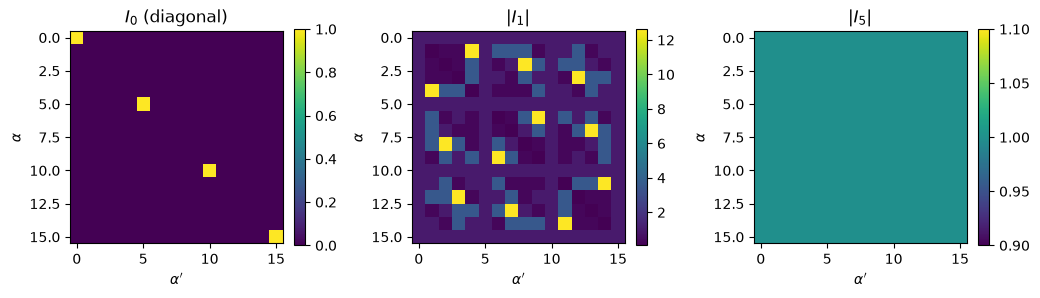

max |I_3[diag rows] - 1| = 0.0


In [40]:
Imats = influence_matrices(eta, d=4)
I0 = np.diag(Imats[0])
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))
for ax, (M, title) in zip(axes, [(np.abs(np.diag(I0)), r'$I_0$ (diagonal)'),
                                 (np.abs(Imats[1]), r'$|I_1|$'),
                                 (np.abs(Imats[5]), r'$|I_5|$')]):
    im = ax.imshow(M, cmap='viridis'); ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xlabel(r"$\alpha'$"); ax.set_ylabel(r"$\alpha$")
plt.tight_layout(); plt.show()

# trace-preservation lemma: rows of I_Delta with s+ = s- are identically 1
sp, sm = np.arange(16) % 4, np.arange(16) // 4
print("max |I_3[diag rows] - 1| =", np.abs(Imats[3][sp == sm] - 1).max())

### 1. Linker Plot: $I_0$ (diagonal)
Dieser Plot zeigt die Matrix des Same-Window Self-Factors $I_0$.
- Was man sieht: Nur vier helle gelbe Punkte (Wert 1.0) auf der Hauptdiagonale, und zwar genau bei den Forward-Backward (FB) Indizes $\alpha = 0, 5, 10$ und $15$.
- Die Physik dahinter: Diese Indizes entsprechen exakt den vier reinen Populationen ($s^+ = s^-$), bei denen das Exziton auf derselben Site sitzt (z. B. $0+4\cdot0=0$ oder $1+4\cdot1=5$). Wie wir beim Trace-preservation lemma gelernt haben, ist hier das Dämpfungsglied im Exponenten null, und die Matrix liefert genau den Wert $1.0$. Alle anderen Einträge (die Kohärenzen, bei denen $s^+ \neq s^-$ gilt) werden durch $I_0$ sofort massiv gedämpft, weshalb der Rest der Matrix tiefviolett (Wert nahe 0) ist.

### 2. Mittlerer Plot: $\vert{}I_1\vert{}$
Dieser Plot zeigt die Kopplungsmatrix für den zeitlichen Abstand von genau einem Zeitschritt ($\Delta k = 1$).
- Was man sieht: Eine hochgradig strukturierte Matrix mit einem regelmäßigen Blockmuster. Die hellen gelben Werte schießen hier sogar bis über 12 hinauf (siehe Farbskala).
- Die Physik dahinter: Das Bad hat hier ein extrem aktives, frisches "Kurzzeitgedächtnis". Wenn das System im vorherigen Zeitschritt auf einer bestimmten Site war ($\alpha'$), korreliert das Bad diese historische Position massiv mit der aktuellen Position ($\alpha$). Das führt zu starken Phasenverschwindungen (Dissipation) und Dämpfungen (Dekohärenz), je nachdem, welche Pfade miteinander wechselwirken. Das Blockmuster spiegelt die $4 \times 4$-Struktur der FMO-Sites wider.

### 3. Rechter Plot: $\vert{}I_5\vert{}$
Dieser Plot zeigt die Kopplungsmatrix für einen größeren zeitlichen Abstand von 5 Zeitschritten ($\Delta k = 5$). bei $\Delta t = 10\text{ fs}$ entspricht das einem Blick zurück von $50\text{ fs}$ in die Vergangenheit.
- Was man sieht: Der Plot ist vollkommen flach, homogen jadegrün und die Farbskala rechts zeigt, dass jeder einzelne Eintrag der Matrix exakt den Wert 1.0 besitzt.
- Die Physik dahinter: Hier schlägt das Memory Truncation (Abschnitt 6.4) bzw. das Abklingen der Bad-Korrelation voll zu. Die Koeffizienten $\eta_{\Delta k}$ sterben aufgrund des exponentiellen Drude-Zerfalls ($e^{-\gamma \Delta k \Delta \tau}$) extrem schnell aus. Nach 5 Schritten ist $\eta_5 \approx 0$. Wenn $\eta \to 0$ geht, wird der gesamte Exponent in der Influence-Matrix null, und die Matrix wird zu einer reinen Eins-Matrix ($e^0 = 1$). Das Bad hat die Vergangenheit nach dieser Zeit schlicht vergessen und übt keine Korrelationen mehr zwischen damals und heute aus.

## 8. The discrete path sum for $\mathcal{L}(t_N)$

### 8.1 Forward–backward propagator

The free system evolution over one window acts on both paths at once. 
$$\rho(t + \Delta t) = U \, \rho(t) \, U^\dagger \quad \text{und daher} \quad \text{vec}(\rho(t+\Delta t)) = \text{vec}(U \rho(t) U^\dagger) = (U^* \otimes U) \text{vec}(\rho(t)) \quad \text{wobei} \quad U = e^{-\frac{i}{\hbar} H_0 \Delta t}$$

With $U_h=e^{-iH_0\Delta\tau/2}$ (half step), $\text{vec}(\rho(t)) \equiv \ket{\rho(t)}$ and $P_h=\bar U_h\otimes U_h$ and hence $P =P_h P_h = (\bar{U}_h \otimes U_h) (\bar{U}_h \otimes U_h) = (\bar{U}_h \bar{U}_h) \otimes (U_h U_h) = (e^{-i H_0 \frac{\Delta \tau}{2}} e^{-i H_0 \frac{\Delta \tau}{2}} ) \otimes (e^{-i H_0 \frac{\Delta \tau}{2}} e^{-i H_0 \frac{\Delta \tau}{2}} )^* = U \otimes U^*$ we have:

$$\vert{}\rho(t + \Delta \tau)\rangle = P \, \vert{}\rho(t)\rangle$$

The symmetric splitting places half-propagators at the very beginning and end; between
two windows they merge into full steps $P$.

For the vectorized density Matrix, we usually write $\vert{}\rho\rangle = \sum_{\alpha} \rho_{\alpha} \vert{}\alpha\rangle$, where the index $\alpha$ runs over the 4*4016 elements of the density matrix $\rho$ and and $\rho_\alpha$ is the correspondig entry of that element. Hence we have:

$$\alpha = s^+ + d \cdot s^- \quad \text{mit} \quad \text{sites}=s^\pm \in \{0, 1, 2, 3\} \quad \text{und} \quad d=4 \quad \implies \alpha \in \{0, \dots, 15\}$$

Die Aneinanderreihung der Operatoren über die Gesamtzeit $t_N = N \cdot \Delta \tau$ folgt dem Muster:$$\text{Dynamik} = \underbrace{P_h}_{\text{Ende}} \, \cdot \, \underbrace{P \cdot P \dots P \cdot P}_{N-1 \text{ volle Schritte}} \, \cdot \, \underbrace{P_h}_{\text{Start}}$$In expliziter Indizierung entlang der diskreten Pfade $\alpha_k$ ausgedrückt:$$(P_h)_{\beta\alpha_N} \left[\prod_{k=2}^{N}P_{\alpha_k\alpha_{k-1}}\right] (P_h)_{\alpha_1\alpha_0} \quad \text{}$$Durch die Unitarität verschmelzen die inneren halben Schritte an den Schnittstellen der Zeitfenster exakt zu den vollen Schritten:$$P_h \cdot P_h = P \quad \text{}$$

### 8.2 The full expression

Herleitung der Pfadintegral formel ausgehend von den Formeln $$\rho_S(s_f^+, s_f^-, t) = \int \mathcal{D}[s^+] \int \mathcal{D}[s^-] \, e^{\frac{i}{\hbar} (S_S[s^+] - S_S[s^-])} \, I[s^+, s^-] \, \rho_S(s_0^+, s_0^-, 0).$$

$$\begin{aligned} I[s^+, s^-] &= \exp\Bigg\{ -\frac{1}{\hbar} \sum_{k=1}^N \sum_{k'=1}^k \Big( \eta_{\Delta k}\,\delta_{s_k^+ s_{k'}^+} - \eta^*_{\Delta k}\,\delta_{s_k^+ s_{k'}^-} - \eta_{\Delta k}\,\delta_{s_k^- s_{k'}^+} + \eta^*_{\Delta k}\,\delta_{s_k^- s_{k'}^-} \Big) \Bigg\} \\ &= \prod_{k=1}^N \prod_{k'=1}^k \exp\Bigg\{ -\frac{1}{\hbar} \Big( \eta_{\Delta k}\,\delta_{s_k^+ s_{k'}^+} - \eta^*_{\Delta k}\,\delta_{s_k^+ s_{k'}^-} - \eta_{\Delta k}\,\delta_{s_k^- s_{k'}^+} + \eta^*_{\Delta k}\,\delta_{s_k^- s_{k'}^-} \Big) \Bigg\} \end{aligned}$$

**1. Diskretisierung und Vektorisierung (Liouville-Raum):**
Wir wandeln die kontinuierlichen Pfadintegrale in diskrete Summen über die Zeitpunkte $t_k = k \cdot \Delta \tau$ um. Gleichzeitig fassen wir die Vorwärts- und Rückwärtspfade $(s_k^+, s_k^-)$ an jedem Knotenpunkt zu einem einzigen Multi-Index $\alpha_k$ zusammen:$$\int \mathcal{D}[s^+] \int \mathcal{D}[s^-] \quad \longrightarrow \quad \sum_{s_1^\pm, \dots, s_N^\pm} \quad \stackrel{\alpha_k = s_k^+ + 4 \cdot s_k^-}{\xrightarrow{\hspace{1.5cm}}} \quad \sum_{\alpha_1, \dots, \alpha_N}$$
D.h. die Gesamtheit der Pfade besteht aus allen Übergängen zwischen elementen von $\rho(t)$ und $\rho(t+ \Delta t)$. Ein einziger spezifischer Pfad könnte so aussehen:$$\alpha_0=3 \quad \longrightarrow \quad \alpha_1=1 \quad \longrightarrow \quad \alpha_2=0 \quad \longrightarrow \quad \alpha_3=0$$Physikalisch übersetzt heißt dieser Pfad:Das System startet im angeregten Zustand ($\rho_{11}$). Im ersten Zeitschritt geht es in einen kohärenten Überlagerungszustand über ($\rho_{10}$). Im zweiten Schritt fällt es in den Grundzustand ($\rho_{00}$) und verbleibt dort im dritten Schritt. Die Summe $\sum_{\alpha_1, \dots, \alpha_N}$ generiert alle erdenklichen Kombinationen solcher Pfade. Bei unserem $d=2$ System und 3 Zeitschritten gibt es an jedem Knotenpunkt 4 Möglichkeiten. Für die inneren Schritte gibt es also $4 \times 4 \times 4 = 64$ völlig verschiedene Pfade.

Die Dichtematrix an sich wird als Vektor aufgefasst: $\rho_S(s_0^+, s_0^-, 0) \to \vert{}\rho(0)\rangle$ mit den Komponenten $\rho_{\alpha_0}$. Die Abbildung (Map) $\mathcal{L}$ transformiert $\alpha_0$ zum finalen Zustand $\beta$.

**2. Der Teil der freien Systemdynamik (S_S)**
Der Exponent der System-Wirkung $e^{\frac{i}{\hbar} (S_S[s^+] - S_S[s^-])}$ beschreibt die freie ungestörte Entwicklung entlang der Pfade. Durch das Trotter-Splitting (symmetrische Halbschritte am Rand, volle Schritte innen) schreiben wir das Integral exakt als Matrixmultiplikation um:$$e^{\frac{i}{\hbar} (S_S[s^+] - S_S[s^-])} \quad \longrightarrow \quad (P_h)_{\beta\alpha_N} \left[\prod_{k=2}^{N}P_{\alpha_k\alpha_{k-1}}\right] (P_h)_{\alpha_1\alpha_0}$$Hierbei ist $\alpha_0$ der Startindex, $\alpha_1 \dots \alpha_N$ sind die inneren Pfadindizes, und $\beta$ ist der offene Endindex.

Dies kan nman über folgende Überlegung motivieren. Wie nutzen die Matrixelemente von $\hat{\rho}_S(t) = \hat{U}(t) \, \hat{\rho}_S(0) \, \hat{U}^\dagger(t)$:

$$\langle s_f^+ \vert{} \hat{\rho}_S(t) \vert{} s_f^- \rangle = \int ds_0^+ \int ds_0^- \, \langle s_f^+ \vert{} \hat{U}(t) \vert{} s_0^+ \rangle \, \langle s_0^+ \vert{} \hat{\rho}_S(0) \vert{} s_0^- \rangle \, \langle s_0^- \vert{} \hat{U}^\dagger(t) \vert{} s_f^- \rangle$$

Nach Feynman lässt sich der Propagator $K$ als Summe (Integral) über alle möglichen Pfade $s(t)$ ausdrücken, gewichtet mit der Wirkung $S_S[s] = \int L(s, \dot{s}) dt$.Für den Vorwärts-Propagator $K$ (die Links-Multiplikation mit $\hat{U}$) verläuft der Pfad $s^+$ von $s_0^+$ nach $s_f^+$:$$K(s_f^+, s_0^+, t) = \langle s_f^+ \vert{} \hat{U}(t) \vert{} s_0^+ \rangle = \int_{s_0^+}^{s_f^+} \mathcal{D}[s^+] \, e^{\frac{i}{\hbar} S_S[s^+]}$$

Setzen wir nun beide Pfadintegrale zurück in die Gleichung der Dichtematrix ein:$$\begin{aligned} \rho_S(s_f^+, s_f^-, t) &= \int ds_0^+ \int ds_0^- \left( \int \mathcal{D}[s^+] \, e^{\frac{i}{\hbar} S_S[s^+]} \right) \rho_S(s_0^+, s_0^-, 0) \left( \int \mathcal{D}[s^-] \, e^{-\frac{i}{\hbar} S_S[s^-]} \right) \\ &= \int \mathcal{D}[s^+] \int \mathcal{D}[s^-] \left( e^{\frac{i}{\hbar} S_S[s^+]} \cdot e^{-\frac{i}{\hbar} S_S[s^-]} \right) \rho_S(s_0^+, s_0^-, 0) \qquad \Big\vert{} \text{Potenzgesetze anwenden} \\ &= \int \mathcal{D}[s^+] \int \mathcal{D}[s^-] \, e^{\frac{i}{\hbar} (S_S[s^+] - S_S[s^-])} \, \rho_S(s_0^+, s_0^-, 0) \end{aligned}$$

Somit kann man zeigen dass:
$$\begin{aligned} e^{\frac{i}{\hbar} (S_S[s^+] - S_S[s^-])}  &= \text{Gewicht der ungestörten Systemdynamik für einen spezifischen Pfad} \\ &= \langle \beta \vert{} \, \mathcal{U}_{\text{frei}}(t_N, 0) \, \vert{} \alpha_0 \rangle_{\text{entlang der Knoten } \alpha_k} \\ &= \langle \beta \vert{} \, P^N \, \vert{} \alpha_0 \rangle_{\text{entlang } \alpha_k} \qquad \qquad \qquad \qquad \quad \;\; \Big\vert{}\; \text{Zeitentwicklung als } N \text{ diskrete Schritte} \\ &= \langle \beta \vert{} \, \underbrace{(P_h P_h) \cdot (P_h P_h) \cdots (P_h P_h)}_{N \text{ volle Schritte}} \, \vert{} \alpha_0 \rangle_{\text{entlang } \alpha_k} \quad \Big\vert{}\; \text{Symmetrisches Splitting: } P = P_h \cdot P_h \\ &= \langle \beta \vert{} \, P_h \cdot \underbrace{(P_h P_h) \cdots (P_h P_h)}_{N-1 \text{ Klammerpaare}} \cdot P_h \, \vert{} \alpha_0 \rangle_{\text{entlang } \alpha_k} \quad \Big\vert{}\; \text{Assoziativgesetz (Klammern umgruppieren)} \\ &= \langle \beta \vert{} \, P_h \cdot \underbrace{P \cdot P \cdots P}_{N-1 \text{ volle Schritte}} \cdot P_h \, \vert{} \alpha_0 \rangle_{\text{entlang } \alpha_k} \qquad \Big\vert{}\; \text{Rücksubstitution: innere } P_h P_h = P \\ &= \langle \beta \vert{} P_h \vert{} \alpha_N \rangle \left( \prod_{k=2}^N \langle \alpha_k \vert{} P \vert{} \alpha_{k-1} \rangle \right) \langle \alpha_1 \vert{} P_h \vert{} \alpha_0 \rangle \quad \; \Big\vert{}\; \text{Eintragen der Pfadindizes als Matrixelemente} \\ &= (P_h)_{\beta\alpha_N} \left[ \prod_{k=2}^{N} P_{\alpha_k\alpha_{k-1}} \right] (P_h)_{\alpha_1\alpha_0} \end{aligned}$$


**3. Zerlegung des Einflussfunktionals (I-Teil):** Das Einflussfunktional $I[s^+, s^-]$ enthält eine Doppelsumme im Exponenten. Wir nutzen $e^{A+B} = e^A e^B$, um die Summe in ein Produkt aufzuspalten. Wir trennen die Summe in Terme der gleichen Zeit ($k=k'$) und verschiedener Zeiten ($k>k'$):

$$\begin{aligned} I[s^+, s^-] = \underbrace{ \left[ \prod_{k=1}^N \exp\Big\{ \text{Term für } k=k' \Big\} \right] }_{\text{Produkt der lokalen Einflüsse } I_0(\alpha_k)} \;\cdot\; \underbrace{ \left[ \prod_{k=1}^N \prod_{k'=1}^{k-1} \exp\Big\{ \text{Term für } k>k' \Big\} \right] }_{\text{Produkt der nicht-lokalen Einflüsse } I_{k-k'}(\alpha_k, \alpha_{k'})} \end{aligned}$$

- 3.1 Lokale Terme (Zeitgleicher Einfluss, $k=k'$): Hier ist $\Delta k = k - k' = 0$. Die Indizes sind am selben Zeitschritt, hängen also nur von $\alpha_k$ ab. Da $\delta_{s_k^\pm s_k^\pm} = 1$:$$I_0(\alpha_k) = \exp\Bigg\{ -\frac{1}{\hbar} \Big( \eta_{0} - \eta^*_{0}\,\delta_{s_k^+ s_{k}^-} - \eta_{0}\,\delta_{s_k^- s_{k}^+} + \eta^*_{0} \Big) \Bigg\}$$
- 3.2 Nicht-lokale Terme (Gedächtnis, $k>k'$): Hier verschränken sich verschiedene Zeitschritte. Die Interaktion verknüpft $\alpha_k$ mit einem vergangenen Zustand $\alpha_{k'}$ über die Zeitdifferenz $\Delta k$:$$I_{k-k'}(\alpha_k, \alpha_{k'}) = \exp\Bigg\{ -\frac{1}{\hbar} \Big( \eta_{\Delta k}\,\delta_{s_k^+ s_{k'}^+} - \eta^*_{\Delta k}\,\delta_{s_k^+ s_{k'}^-} - \eta_{\Delta k}\,\delta_{s_k^- s_{k'}^+} + \eta^*_{\Delta k}\,\delta_{s_k^- s_{k'}^-} \Big) \Bigg\}$$

**4. Memory Truncation (Gedächtnis-Abbruch):** Da die Bad-Korrelationsfunktionen $\eta_{\Delta k}$ für große Zeitdifferenzen $\Delta k$ abklingen, schneiden wir das Gedächtnis bei einer maximalen Schrittzahl $K$ ab. Die Bedingung für das zweite Produkt wird eingeschränkt:$$\prod_{k>k'} I_{k-k'}(\alpha_k, \alpha_{k'}) \quad \longrightarrow \quad \prod_{k>k',\;k-k'\le K} I_{k-k'}(\alpha_k, \alpha_{k'})$$

**5. Zusammenbau zur vollständigen Map:** Wir setzen nun alle diskreten Teile (Freie Dynamik + Lokaler Einfluss + Abgeschnittener nicht-lokaler Einfluss) zusammen. Wir definieren die Tensor-Map $\mathcal{L}(t_N)$, welche den Anfangszustand $\alpha_0$ auf den Endzustand $\beta$ abbildet, indem wir über alle möglichen Zwischenpfade $\alpha_1 \dots \alpha_N$ summieren:$$\rho_\beta(t_N) = \sum_{\alpha_0} \mathcal{L}(t_N)_{\beta\,\alpha_0} \rho_{\alpha_0}(0)$$Die Map selbst ergibt sich durch das Ausmultiplizieren aller Propagatoren und Einfluss-Matrizen entlang der Indizes:$$\mathcal{L}(t_N)_{\beta\,\alpha_0} =\sum_{\alpha_1\ldots\alpha_N} \underbrace{(P_h)_{\beta\alpha_N}}_{\text{End-Halbschritt}} \underbrace{\left[\prod_{k=2}^{N}P_{\alpha_k\alpha_{k-1}}\right]}_{\text{Innere volle Schritte}} \underbrace{\left[\prod_{k=1}^{N}I_0(\alpha_k)\right]}_{\text{Lokale } \eta\text{-Tiles}} \underbrace{\left[\prod_{k>k',\;k-k'\le K} I_{k-k'}(\alpha_k,\alpha_{k'})\right]}_{\text{Nicht-lokale } \eta\text{-Tiles mit Cutoff } K} \underbrace{(P_h)_{\alpha_1\alpha_0}}_{\text{Start-Halbschritt}} \tag{1}$$

The cell below evaluates this formula *literally* — three nested loops, nothing hidden —
for $N=2$ and compares to the production code. `selftest.py` extends this to $N=4$, with
and without memory truncation ($10^{-14}$ agreement), and to the $\lambda=0$ limit where
the sum must telescope to $\bar U(t)\otimes U(t)$.

# The discrete path sum for $\mathcal{L}(t_N)$
Mit der Definition $U_{s_k^+ s_{k-1}^+} \equiv \langle s_k^+ \vert{} e^{-i H_S \Delta t} \vert{} s_{k-1}^+ \rangle$ können wir den Ausdruck aus der letzten Zeile schreiben als:
$$\rho_S(s_N^+,s_N^-;\,t) = \sum_{\{s^\pm\}} \Big(\prod_{k=1}^N U_{s_k^+ s_{k-1}^+}\Big)\, \rho_S(s_0^+,s_0^-;0)\, \Big(\prod_{k=1}^N U_{s_k^- s_{k-1}^-}\Big)^{\!\!*} \, I[s^+,s^-]$$
Unser Ziel ist es nun diesen Ausdruck zu vektorisieren um ihn als **Matrix mal Vektor** $\;\mathrm{vec}(\rho_S(s_N^+,s_N^-;\,t)) = \mathcal{L}(t_N)\,\mathrm{vec}(\rho_S(s_0^+,s_0^-;0))\;$ schreiben zu können. Summiert wird über die inneren $s_1^\pm,\dots,s_{N-1}^\pm$ und die Startindizes $s_0^\pm$; die äußeren $s_N^\pm$ sind fest. Das erlaubt es uns dieselbe Map $\mathcal{L}(t_N)$ auf alle möglichen Startmatrixelemente anzuwenden ohne sie jedes mal neu berechnen zu müssen.


### Schritt 1 — Vektorisierung (column-stacking) und der Liouville-Index $\alpha$

Um eine $d\times d$-Dichtematrix ($d=4$) zu vektorisieren, stapeln wir ihre Spalten übereinander zu einem $D=d^2=16$-Vektor. Ein element dieses Vektors lässt sich dann mit dem Index $\alpha$ indizieren:
$$\mathrm{vec}(\rho)_\alpha = \rho_{s^+ s^-} = \langle s^+|\rho|s^-\rangle,\qquad \alpha \equiv (s^+-1) + d\,(s^--1) \in \{0,\dots,15\}.$$
Der **Liouville- bzw. Vorwärts-Rückwärts-(FB-)Index** $\alpha$ fasst also das Paar $(s^+,s^-)$ zu *einer* Zahl zusammen: $s^+$ (ket, „Zeile") ist der Vorwärtspfad, $s^-$ (bra, „Spalte") der Rückwärtspfad. Zu jedem Zeitschritt $k$ wird $(s_k^+,s_k^-) \mapsto \alpha_k$. Damit ist der Startvektor $\mathrm{vec}(\rho_S(0))_{\alpha_0} = \rho_S(s_0^+,s_0^-;0)$ und der gesuchte äußere Index heißt $\beta \equiv \alpha_N = (s_N^+,s_N^-)$. *(Das sind genau die 16 Werte pro Zeitschritt, die in der ersten Zelle eingeführt wurden.)*

### Schritt 2 — die freie FB-Propagation $P$ (und der Halbschritt $P_h$)

Dan wir hier nur mit Matrixelementen (Skalaren) hantieren, müssen wir nichts wirklich vektorisieren. Wir können jedoch die oboge Notation $\alpha_k = (s_k^+,s_k^-)$ einführen um den Operator $P_{\alpha_k \alpha_{k-1}}$ zu definieren:

$$\begin{aligned} \mathrm{vec}(\rho_S(t))_{\alpha_N} = \rho_S(s_k^+,s_k^-;\,t) &= \sum_{\{s^\pm\}} \Big(\prod_{k=1}^N U_{s_k^+ s_{k-1}^+}\Big)\, \rho_S(s_0^+,s_0^-;0)\, \Big(\prod_{k=1}^N U_{s_k^- s_{k-1}^-}\Big)^{\!\!*} \, I[s^+,s^-]  \\ &= \sum_{\{s^\pm\}} \Big(\prod_{k=1}^N U_{s_k^+ s_{k-1}^+}\Big) \Big(\prod_{k=1}^N \bar{U}_{s_k^- s_{k-1}^-}\Big) \, \rho_S(s_0^+,s_0^-;0) \, I[s^+,s^-] \\ &= \sum_{\alpha_0, \dots, \alpha_{N-1}} \Bigg( \prod_{k=1}^N \underbrace{\Big( U_{s_k^+ s_{k-1}^+} \, \bar{U}_{s_k^- s_{k-1}^-} \Big)}_{\equiv \; P_{\alpha_k \alpha_{k-1}} \;=\; (\bar{U} \otimes U)_{\alpha_k \alpha_{k-1}}}\Bigg) \, I[s^+,s^-] \, \rho_S(s_0^+,s_0^-;0) = \sum_{\alpha_0, \dots, \alpha_{N-1}} \Bigg( \prod_{k=1}^N P_{\alpha_k \alpha_{k-1}} \Bigg) \, I[s^+,s^-] \, \mathrm{vec}(\rho_S(0))_{\alpha_0}\end{aligned}$$

In der normalen Quantenmechanik propagiert der Operator $U$ einen Zustandsvektor (eine Wellenfunktion $\vert{}\psi\rangle$). Da wir es hier aber mit einem offenen Quantensystem zu tun haben, arbeiten wir mit der Dichtematrix $\rho$.Wenn wir die $(4 \times 4)$-Dichtematrix des FMO-Komplexes als einen Vektor der Länge 16 umschreiben (Vektorisierung), wechseln wir in den sogenannten Liouville-Raum.Der Operator $P$ ist der Liouville-Propagator (oder Superoperator). Er ist eine $16 \times 16$-Matrix, die diesen 16-elementigen Vektor propagiert. Er entwickelt also nicht einfach "ein Element" der Dichtematrix, sondern er treibt den gesamten Zustand (Vorwärts- und Rückwärtspfad gleichzeitig) einen Zeitschritt voran. $P_{\alpha_k, \alpha_{k-1}}$ ist ein Element der Matrix, und kann wie in $P_{(3,2), (1,1)} = U_{3, 1} \cdot \bar{U}_{2, 1} = U_{3, 1} \cdot U_{2, 1}^*$ gezeigt berechnet werden.
- $U_{3, 1}$ ist die quantenmechanische Amplitude dafür, dass die Wellenfunktion auf dem Vorwärtspfad von Site 1 auf Site 3 springt.
- $U_{2, 1}^*$ ist die konjugiert komplexe Amplitude dafür, dass sie auf dem Rückwärtspfad von Site 1 auf Site 2 springt.

Das Produkt dieser beiden Zahlen ist das Gewicht, mit dem die anfängliche Population $\rho_{11}$ in die neue Kohärenz $\rho_{32}$ einfließt. Die Summe bedeutet also dass wir in jedem Zeitschritt $k$ über alle möglichen Werte von $\alpha_k$ summieren. Dabei kann $\alpha_k$ z.B. die Werte $\alpha_k=(1,1)$ oder $\alpha_k=(1,2)$ oder $\alpha_k=(3,3)$,... annehmen. Eine beliebige Folge wäre z.B: 
- $\alpha_0 = (1,1)$ (Start auf Site 1)
- $\alpha_1 = (1,2)$ (Übergang in eine Kohärenz)
- $\alpha_2 = (3,3)$ (Kollaps auf Site 3)

Die Summe läuft über alle diese möglichen Folgen, d.h über alle möglichen Kombinationen der Werte von $\alpha_k$.


### Schritt 3 — das Einflussfunktional in FB-Indizes: $I_0$ und $I_{\Delta k}$

Das in der vorigen Zelle hergeleitete Einflussfunktional
$$I[s^+,s^-] = \exp\Big\{-\tfrac1\hbar \sum_{k=1}^N \sum_{k'=1}^k \big(\eta_{\Delta k}\,\delta_{s_k^+ s_{k'}^+} - \eta^*_{\Delta k}\,\delta_{s_k^+ s_{k'}^-} - \eta_{\Delta k}\,\delta_{s_k^- s_{k'}^+} + \eta^*_{\Delta k}\,\delta_{s_k^- s_{k'}^-}\big)\Big\}$$
hängt ausschließlich von den Zustands-Paaren – also den kombinierten Liouville-Indizes $\alpha$ – ab. Um diese komplexe Exponenten-Struktur in numerisch handhabbare Matrizen zu übersetzen, spalten wir die Doppelsumme auf. Wir trennen sie in einen zeitlokalen Anteil (die Diagonale mit $k'=k$, also $\Delta k = 0$) und einen Memory-Anteil (die Nebendiagonale mit $k' < k$, also $\Delta k \ge 1$). Mithilfe der Identität $e^{\sum(\dots)} = \prod e^{(\dots)}$ zerfällt das Funktional in ein Produkt aus zwei gut interpretierbaren Faktoren:

**1. Der zeitlokale Faktor $I_0(\alpha_k)$**

Werten wir das Bad für exakt denselben Zeitschritt aus ($k'=k$), treten in den Kronecker-Deltas gleiche Zeiten auf. Da jede Site natürlich mit sich selbst identisch ist, gilt $\delta_{s_k^+ s_k^+} = \delta_{s_k^- s_k^-} = 1$. Die Kreuzterme sind logischerweise symmetrisch ($\delta_{s_k^+ s_k^-} = \delta_{s_k^- s_k^+}$).Dadurch vereinfacht sich der gesamte Ausdruck in der Klammer zu $(\eta_0 + \eta_0^*)\,(1 - \delta_{s_k^+ s_k^-}) = 2\,\mathrm{Re}(\eta_0)\,(1-\delta_{s_k^+ s_k^-})$. Das liefert unseren lokalen Faktor:$$I_0(\alpha_k) = \exp\Big\{-\tfrac1\hbar\, 2\,\mathrm{Re}(\eta_0)\,\big(1 - \delta_{s_k^+ s_k^-}\big)\Big\}$$Physikalisch sehen wir hier den mikroskopischen Ursprung der Dekohärenz: Für reine Populationszustände (die Vorwärts- und Rückwärtsindizes sind identisch, $s_k^+ = s_k^-$) wird die runde Klammer zu Null und der Faktor damit exakt $I_0 = 1$. Populationen bleiben also instantan ungedämpft. Sobald jedoch eine Quantenkohärenz vorliegt ($s_k^+ \neq s_k^-$), springt der Vorfaktor an und dämpft die Amplitude exponentiell.

**2. Der nichtlokale Memory-Faktor $I_{\Delta k}(\alpha_k,\alpha_{k'})$** 

Für alle vergangenen Zeitschritte ($k' < k$) erfasst das Modell das "Gedächtnis" des Bades über den zeitlichen Abstand $\Delta k = k-k'$. Hier bleibt die ursprüngliche Struktur der Kronecker-Deltas unverändert, da wir Vorwärts- und Rückwärtspfade zu zwei unterschiedlichen Zeiten auf Gleichheit prüfen:$$I_{\Delta k}(\alpha_k,\alpha_{k'}) = \exp\Big\{-\tfrac1\hbar\big(\eta_{\Delta k}\,\delta_{s_k^+ s_{k'}^+} - \eta^*_{\Delta k}\,\delta_{s_k^+ s_{k'}^-} - \eta_{\Delta k}\,\delta_{s_k^- s_{k'}^+} + \eta^*_{\Delta k}\,\delta_{s_k^- s_{k'}^-}\big)\Big\}$$

Zusammengesetzt lässt sich das gesamte Einflussfunktional nun als elegantes Produkt über die Zeitsegmente schreiben:$$I[s^+,s^-] = \prod_{k=1}^N I_0(\alpha_k) \prod_{k>k'} I_{k-k'}(\alpha_k,\alpha_{k'})$$
Da der Vorwärts- und Rückwärtsindex $s^\pm$ jeweils 4 Werte annehmen kann, gibt es genau 16 mögliche Liouville-Zustände $\alpha$. Dementsprechend bilden sowohl der lokale Faktor $I_0$ als auch die Memory-Faktoren $I_{\Delta k}$ numerische $16\times16$-Matrizen.In der algorithmischen Umsetzung (Funktion influence_matrices) entsprechen diese Bausteine exakt den berechneten Objekten: `I0` repräsentiert die lokale Matrix und `Imats` speichert die Liste der nichtlokalen Memory-Matrizen für wachsende $\Delta k$.

### Schritt 4 — Zusammensetzen: die Map als offene Pfadsumme

Setzen wir nun alle Bausteine – die System-Propagatoren (hier als $P$ zusammengefasst) und das faktorisierte Einflussfunktional – in unsere Ausgangsgleichung ein und klammern den Startzustand $\mathrm{vec}(\rho_S(0))_{\alpha_0}$ aus, erhalten wir die finale Struktur der Zeitentwicklung:$$\mathrm{vec}(\rho_S(t))_{\alpha_N} = \sum_{\alpha_0} \underbrace{\Bigg[\sum_{\alpha_1\ldots\alpha_{N-1}} \prod_{k=1}^N P_{\alpha_k\alpha_{k-1}} \prod_{k=1}^N I_0(\alpha_k) \prod_{k>k'} I_{k-k'}(\alpha_k,\alpha_{k'})\Bigg]}_{=\;\mathcal{L}(t_N)_{\alpha_N,\,\alpha_0}} \, \mathrm{vec}(\rho_S(0))_{\alpha_0}.$$Der riesige Klammerausdruck bildet exakt die gesuchte Matrix der dynamischen Abbildung (den Liouville-Propagator $\mathcal{L}$). Ihr Zeilenindex ist der Endzustand $\alpha_N$, ihr Spaltenindex der Startzustand $\alpha_0$. Um ein einzelnes Matrixelement dieses Propagators zu berechnen, summiert die innere Summe über sämtliche verborgenen Zwischenschritte ($\alpha_1,\dots,\alpha_{N-1}$) des Pfades.(Hinweis zur Genauigkeit: Diese spezifische Form entspricht einer „einseitigen“ Trotter-Anordnung, bei der der äußerste Index $\alpha_N$ direkt der letzte Pfadknoten ist. Diese asymmetrische Aufspaltung bringt einen systematischen Diskretisierungsfehler der Ordnung $\mathcal{O}(\Delta t)$ mit sich, weshalb $\Delta t$ klein genug gewählt werden muss).

Warum steht die Summe über $\alpha_0$ ganz außen? Wir trennen die Dynamik des Quantensystems strikt von seinen spezifischen Anfangsbedingungen. Das Bad und der Hamiltonoperator des Systems interessieren sich nicht dafür, in welchem Zustand das System gestartet ist. Die Regeln, wie sich das System von einem Zustand $\alpha_0$ in einen Zustand $\alpha_N$ entwickelt (die Übergangsgewichte), sind immer gleich. Der gesamte Klammerausdruck berechnet genau diese Regeln und ist völlig unabhängig von $\rho_S(0)$.

Wenn man sicher weiß was der Anfangszustand $\alpha_0$ ist (z.B excitation auf site 1), dann muss man nicht über $\alpha_0$ summieren, sondern startet einach bei diesem Wert. Wenn man nur mit einer bestimmten Wahrscheinlichkeit in einem Zustand startet, dann muss man die Summe ausrechnen:

- Wenn du zu 100 % sicher weißt, dass das System in einem ganz bestimmten Zustand (z. B. Index $\alpha_0 = 1$) startet, dann besteht der Startvektor $\mathrm{vec}(\rho_S(0))$ aus lauter Nullen – bis auf exakt eine $1$ an der Stelle $\alpha_0 = 1$.Die Summe über $\alpha_0$ steht formal zwar immer noch da, aber da alle Einträge bis auf einen $0$ sind, kollabiert die Summe zu einem einzigen Term. Es bleibt genau eine Spalte der Propagator-Matrix übrig:$$\mathrm{vec}(\rho_S(t))_{\alpha_N} = \mathcal{L}(t_N)_{\alpha_N,\,1} \cdot 1$$Die Summe fällt also "in der Praxis" weg, weil du einfach nur die eine Spalte aus dem Liouville-Propagator herauspflückst, die deinem festen Startzustand entspricht.

- Wenn das System anfangs nicht exakt lokalisiert ist, sondern z. B. mit 30 % Wahrscheinlichkeit in Zustand 1 und mit 70 % Wahrscheinlichkeit in Zustand 2 startet (oder quantenmechanische Superpositionen/Kohärenzen besitzt), dann hat der Vektor $\mathrm{vec}(\rho_S(0))$ mehrere Einträge ungleich Null.
In diesem Fall musst du die Summe ausführen. Physikalisch bedeutet das: Die Dynamik ist linear. Die Summe berechnet die Zeitentwicklung für jeden möglichen Startzustand separat (die verschiedenen Spalten von $\mathcal{L}$) und mischt diese Endresultate am Schluss genau mit den Gewichten zusammen, die durch die anfänglichen Wahrscheinlichkeiten $\mathrm{vec}(\rho_S(0))_{\alpha_0}$ vorgegeben waren.

### Schritt 5 — symmetrische Trotter-Anordnung $\Rightarrow$ die Halbschritte $P_h$

In der asymmetrischen Form ($e^{-i H_S \Delta t} e^{-i H_B \Delta t}$) lässt man das System einen ganzen Schritt propagieren und schaltet dann das Bad ein. Das erzeugt einen systematischen Fehler (Bias), da System und Bad in der Realität simultan wirken.Die symmetrische Form $e^{-iH\Delta t} = e^{-iH_S\Delta t/2}\, e^{-i(H_B+H_{\rm int})\Delta t}\, e^{-iH_S\Delta t/2} + \mathcal O(\Delta t^3)$ zentriert die Wirkung des Bades. Das System propagiert ungestört für einen halben Zeitschritt, dann interagiert es mit dem Bad, und dann propagiert es für einen weiteren halben Schritt. Das Bad wird also exakt in die Mitte des Zeitintervalls gelegt. Dadurch heben sich die Fehler erster Ordnung auf, und die Genauigkeit steigt von $\mathcal{O}(\Delta t)$ auf $\mathcal{O}(\Delta t^2)$. Somit lautet die finale Formel:

$$\boxed{\;\mathcal{L}(t_N)_{\beta\,\alpha_0} =\sum_{\alpha_1\ldots\alpha_N} \underbrace{(P_h)_{\beta\alpha_N}}_{\text{End-Halbschritt}} \underbrace{\left[\prod_{k=2}^{N}P_{\alpha_k\alpha_{k-1}}\right]}_{\text{Innere volle Schritte}} \underbrace{\left[\prod_{k=1}^{N}I_0(\alpha_k)\right]}_{\text{Lokale } \eta\text{-Tiles}} \underbrace{\left[\prod_{k>k',\;k-k'\le K} I_{k-k'}(\alpha_k,\alpha_{k'})\right]}_{\text{Nicht-lokale } \eta\text{-Tiles, Cutoff } K} \underbrace{(P_h)_{\alpha_1\alpha_0}}_{\text{Start-Halbschritt}}\;} \tag{1}$$

Wenn wir die Produkte für ein kurzes Beispiel mit $N=2$ Zeitschritten für einen Summanden chronologisch (also so, wie die Zeit wirklich abläuft) aufschreiben, sieht man sofort, wie System und Bad ineinandergreifen. Zuvor noch eine kurze Erinnerung:
- $k$ ist unsere aktuelle Zeit. Er zählt einfach mit, an welchem physikalischen Knotenpunkt (an welcher Site) (1 bis $N$) wir gerade angekommen sind.
- $k'$ ist der Erinnerungs-Index des Bades. Wenn wir an Knoten $k$ stehen, blickt $k'$ in die Vergangenheit zurück und läuft von $1$ bis zur Gegenwart $k$ (also $k' \le k$).
    - Ist $k' = k$, bewertet das Bad die Gegenwart (lokaler Faktor $I_0$).
    - Ist $k' < k$, erinnert sich das Bad an einen früheren Schritt (Memory-Faktor $I_{k-k'}$). Dabei berechhnet $I[\alpha_k, \alpha_{k'}]$ für jedes $k$, den einfluss vom Bad zur Zeit $k'$:
        - $I_1(\alpha_k, \alpha_{k-1})$ (Gedächtnis $\Delta=1$): Ein Einfluss vom Bad, der den Zustand von gestern ($k-1$) mit heute ($k$) koppelt.
        - $I_2(\alpha_k, \alpha_{k-2})$ (Gedächtnis $\Delta=2$): Ein Einfluss, der vorgestern ($k-2$) mit heute ($k$) koppelt.

Schritt 1: System (Der Anlauf): Wir starten zur Zeit $0$ im Zustand $\alpha_0$. Das System macht seinen ersten freien Halbschritt, um genau in die Mitte des ersten Zeitfensters zu gelangen.
- Werte: Hier gibt es noch keine Bad-Indizes. Wir bewegen uns auf den Knoten $k=1$ zu.
- Faktor: $(P_h)_{\alpha_1 \alpha_0}$

Schritt 2: Bad (Auswertung an Knoten $k=1$): Wir sind am ersten Knoten angekommen. Also ist $k = 1$.Jetzt wird das Bad ausgewertet. Der Erinnerungs-Index $k'$ läuft von $1$ bis $k$. Da $k=1$ ist, kann $k'$ nur den Wert $1$ annehmen.
- $k=1, k'=1$: Das Bad bewertet den aktuellen Zustand $\alpha_1$. Da $k-k' = 0$, liefert dies den lokalen Faktor.
- Warum gibt es kein Memory? Weil wir erst beim ersten Schritt sind. Es gibt noch keine Vergangenheit, an die sich das Bad erinnern könnte.
- Faktor: $I_0(\alpha_1)$

Schritt 3: System (Voller Schritt): Das System fliegt ungestört vom ersten Knoten $\alpha_1$ zum zweiten Knoten $\alpha_2$.
- Werte: Wir lassen $k=1$ hinter uns und bewegen uns auf $k=2$ zu.
- Faktor: $P_{\alpha_2 \alpha_1}$

Schritt 4: Bad (Auswertung an Knoten $k=2$): Wir sind am zweiten Knoten angekommen. Also ist jetzt $k = 2$.Das Bad wird wieder ausgewertet. Der Erinnerungs-Index $k'$ läuft nun von $1$ bis $k=2$. Er nimmt also zwei Werte an:
- $k=2, k'=2$ (Die Gegenwart): Das Bad bewertet den aktuellen Zustand $\alpha_2$. Die Differenz ist $\Delta k = 0$. Das liefert den lokalen Faktor für den neuen Knoten. $\rightarrow I_0(\alpha_2)$
- $k=2, k'=1$ (Die Vergangenheit): Das Bad spürt jetzt eine Verschränkung mit dem, was beim letzten Knoten passiert ist. Die Zeitdifferenz ist $\Delta k = 2 - 1 = 1$. Das liefert den ersten Memory-Faktor. $\rightarrow I_1(\alpha_2, \alpha_1)$
- Faktor: Beide werden multipliziert: $I_0(\alpha_2) \cdot I_1(\alpha_2, \alpha_1)$

Schritt 5: System (Der Auslauf): Die eigentlichen $N=2$ Zeitschritte sind vorbei. Um die exakte Dichtematrix an der Zielzeit abzulesen, muss das System noch den letzten ausstehenden Halbschritt vom Knoten $\alpha_2$ in den beobachteten Endzustand $\beta$ machen.
- Werte: Keine Bad-Auswertung mehr, reine System-Dynamik.
- Faktor: $(P_h)_{\beta \alpha_2}$

Wenn du all das multiplizierst, hast du chronologisch exakt die Formel aus deinem Beispiel erzeugt:$$\text{Pfadgewicht} = \underbrace{(P_h)_{\beta \alpha_2}}_{\text{Schritt 5}} \cdot \underbrace{\Big[ I_0(\alpha_2) I_1(\alpha_2, \alpha_1) \Big]}_{\text{Schritt 4: } k=2} \cdot \underbrace{P_{\alpha_2 \alpha_1}}_{\text{Schritt 3}} \cdot \underbrace{I_0(\alpha_1)}_{\text{Schritt 2: } k=1} \cdot \underbrace{(P_h)_{\alpha_1 \alpha_0}}_{\text{Schritt 1}}$$

Hierbei ist $\text{Pfadgewicht}$ ein Summand in $\sum_{\alpha_1\ldots\alpha_N}$. Um das Pfadgewicht für den Zeitschritt $k=2$ auszurechnen, braucht man die Werte $\alpha_0$ und $\alpha_1$ vom vorherigen Zeitschritt.

```
Zeit:   t=0        0.5 Δt          1.5 Δt          2.5 Δt          3.5 Δt         t_end
         │           │               │               │               │               │
Start    │           │               │               │               │               │      Ziel
[ α₀ ] ──(Ph)──> [ α₁ ] ───(P)───> [ α₂ ] ───(P)───> [ α₃ ] ───(P)───> [ α₄ ] ──(Ph)──> [ β ]
                     │               │               │               │
                     ▼               ▼               ▼               ▼
k (Aktuell):        k=1             k=2             k=3             k=4

Lokal (Δk=0):      I₀(α₁)          I₀(α₂)          I₀(α₃)          I₀(α₄)
                     │               │               │               │
Memory (Δk=1):       │             I₁(α₂,α₁)       I₁(α₃,α₂)       I₁(α₄,α₃)
                     │                               │               │
Memory (Δk=2):       │                               I₂(α₃,α₁)       I₂(α₄,α₂)
                     │                                               │
Memory (Δk=3):       │                                               I₃(α₄,α₁)
```

### Schritt 6 — Ablesen und Bedeutung

- $\mathcal{L}(t_N)$ ist die $16\times16$-Matrix des exakten nicht-Markovschen Superpropagators $\mathcal{E}_{t_N,0}$ (Papier-Gl. 12): $\;\mathrm{vec}(\rho(t_N)) = \mathcal{L}(t_N)\,\mathrm{vec}(\rho(0))$.
- $\beta$ und $\alpha_0$ sind **offen** — sie sind die Zeilen bzw. Spalten der Matrix. Die inneren $\alpha_1,\dots,\alpha_N$ sind die aufsummierten **Pfadknoten**. Weil $\alpha_0$ offen bleibt, liefert eine einzige Kontraktion die **ganze** Map (nicht nur eine Spalte) — das ist der Kern der TEMPO/TNPI-Implementierung.
- Der Cutoff $k-k' \le K$ (Gedächtnistiefe) lässt nur die nichtlokalen $I_{\Delta k}$ mit $\Delta k \le K$ zu (da $\eta_{\Delta k}\to 0$ für große $\Delta k$); Aufwand $\mathcal O(N\cdot K)$ statt $\mathcal O(N^2)$.
- Diese $\mathcal{L}(t_N)$ ist der Input der **Grid-Pipeline**: $\mathcal{L} \to$ Choi-Matrix $\to$ Kraus-Operatoren $M_k \to$ Dynamik $\rho(t_N) = \sum_k M_k\,\rho(0)\,M_k^\dagger$.

# Tensor-network contraction (TEMPO / TNPI)

Start: Die ausformulierte Pfadsumme mit Cutoff $K$:$$\begin{aligned} \mathcal{L}(t_N)_{\beta\,\alpha_0} &= \sum_{\alpha_1\ldots\alpha_N} \underbrace{(P_h)_{\beta\alpha_N}}_{\text{End}} \underbrace{\left[\prod_{k=2}^{N}P_{\alpha_k\alpha_{k-1}}\right]}_{\text{Freie Schritte}} \underbrace{\left[\prod_{k=1}^{N}I_0(\alpha_k)\right]}_{\text{Lokale Tiles}} \underbrace{\left[\prod_{k>k',\;k-k'\le K} I_{k-k'}(\alpha_k,\alpha_{k'})\right]}_{\text{Gedächtnis-Tiles}} \underbrace{(P_h)_{\alpha_1\alpha_0}}_{\text{Start}} \end{aligned}$$

Wir schauen uns an, welche Gewichte an der Perle $k$ „andocken“:
- $P_{\alpha_k\alpha_{k-1}}$ (Freier Schritt): Das System geht von $k-1$ nach $k$. Das ist wie ein normaler Markov-Prozess.
- $I_0(\alpha_k)$ (Lokal): Ein Gewicht, das nur vom Zustand genau jetzt abhängt. Durch das Produkt $\prod_{k=1}^N$ haben wir diesen Term $N$ mal. Einmal für jedes $\alpha_k$.
- $I_1(\alpha_k, \alpha_{k-1})$ (Gedächtnis $\Delta=1$): Ein Einfluss vom Bad, der den Zustand von gestern ($k-1$) mit heute ($k$) koppelt. Es berechnet also die Korrelation zwischen zeitlich direkt benachbarten Zeitschritten ($\Delta k = 1$). Durch das Produkt $\prod_{k=2}^N$ wird diese Kopplung für jedes benachbarte Paar entlang des gesamten Pfades bis zur Zeit $N$ evaluiert (also $(2,1), (3,2), (4,3) \dots (N, N-1)$).
- $I_2(\alpha_k, \alpha_{k-2})$ (Gedächtnis $\Delta=2$): Ein Einfluss, der vorgestern ($k-2$) mit heute ($k$) koppelt. Es berechnet also die Korrelation zwischen übernächsten Nachbarn, also Zeitschritten mit dem Abstand $\Delta k = 2$. Das Produkt $\prod_{k=3}^N$ iteriert auch hier wieder über alle gültigen Pfadkombinationen mit diesem zeitlichen Abstand im gesamten Intervall (also $(3,1), (4,2), (5,3) \dots (N, N-2)$).

Da $K=2$, gibt es kein $I_3$ oder höher. Die Wechselwirkung ist strikt abgeschnitten.

Schritt 1: Umordnen und Gruppieren nach Zeitschritt $k$Wir sortieren das riesige Produkt um. Alles, was an einer bestimmten Perle $k$ "neu" an physikalischen Gewichten hinzukommt ($P$, $I_0$ und die Historien-Tiles $I_1 \dots I_K$), wird zusammengefasst. Wir nennen dieses gebündelte physikalische Gewicht $W(\alpha_k, \alpha_{k-1}, \dots, \alpha_{k-K})$.$$\begin{aligned} &= \sum_{\alpha_1\ldots\alpha_N} (P_h)_{\beta\alpha_N} \left[ \prod_{k=1}^{N} \Big( P_{\alpha_k\alpha_{k-1}} I_0(\alpha_k) I_1(\alpha_k,\alpha_{k-1}) \cdots I_K(\alpha_k,\alpha_{k-K}) \Big) \right] (P_h)_{\alpha_1\alpha_0} \\ &= \sum_{\alpha_1\ldots\alpha_N} (P_h)_{\beta\alpha_N} \left[ \prod_{k=1}^{N} W(\alpha_k, \alpha_{k-1}, \dots, \alpha_{k-K}) \right] (P_h)_{\alpha_1\alpha_0} \end{aligned}$$Schritt 2: Einführung des "Gedächtnis-Bonds" $c_k$Wir zwingen das System, an jedem Schnitt $k$ exakt die letzten $K$ Zustände zu speichern. Dafür erfinden wir den Sammel-Index $c_k = (\alpha_{k-K+1}, \dots, \alpha_k)$. Mathematisch realisieren wir das, indem wir eine Summe über alle möglichen Zustände von $c_k$ sowie eine Indikatorfunktion $\mathbb{1}[\dots]$ einschieben. Diese Funktion wirkt wie ein strenger Filter: Sie ist nur $1$, wenn das Fenster exakt die korrekten $\alpha$'s enthält, ansonsten $0$.$$\begin{aligned} &= \sum_{\alpha_1\ldots\alpha_N} \underbrace{\sum_{c_1\dots c_N}}_{\text{Summe über Bonds}} (P_h)_{\beta\alpha_N} \left[ \prod_{k=1}^{N} W(\alpha_k, \alpha_{k-1}, \dots, \alpha_{k-K}) \cdot \mathbb{1}\big[\,c_k = (\alpha_{k-K+1}, \dots, \alpha_k)\,\big] \right] (P_h)_{\alpha_1\alpha_0} \end{aligned}$$

Stell dir vor, du bist an der Stelle $k$ und willst die Gewichte berechnen, die zu $\alpha_k$ gehören. Du brauchst dafür $\alpha_{k-1}$ (für $P$ und $I_1$) und $\alpha_{k-2}$ (für $I_2$). Siehe Diagramm 4 im Bild der obigen Zelle. Was passiert im nächsten Schritt $k+1$? Dort brauchst du $\alpha_k$ und $\alpha_{k-1}$ um die Gewichte $P, I_1$ und $I_2$ für $\alpha_{k+1}$ zu berechnen. Die Information über $\alpha_{k-2}$ wird nie wieder benötigt, da die Reichweite $K=2$ ist!Wir müssen also an jedem Schnitt zwischen zwei Zeitschritten immer exakt die letzten $K=2$ Zustände in unserem „Arbeitsspeicher“ mitführen. Dieses Informationspaket ist das Bond $c$.

- Das eingehende Fenster (bevor wir $\alpha_k$ verarbeiten) ist: $c_{k-1} = (\alpha_{k-2}, \alpha_{k-1})$
- Das ausgehende Fenster (nachdem wir $\alpha_k$ verarbeitet haben) ist: $c_k = (\alpha_{k-1}, \alpha_k)$

Ein Bond $c$ ist also nichts anderes als ein Sammel-Index. Wenn $\alpha$ jeweils 16 mögliche Werte annehmen kann, dann gibt es $16 \times 16 = 256$ mögliche Kombinationen für das Fenster $c$. Das Bond hat die Dimension $16^K = 256$.

Schritt 3: Konstruktion der Update-Maschine $G^{(k)}$Wir lesen die vergangenen Zustände $(\alpha_{k-K}, \dots, \alpha_{k-1})$ nun direkt aus dem eingehenden Bond $c_{k-1}$ ab. Das physikalische Gewicht $W$ hängt damit effektiv nur noch vom neuen Zustand $\alpha_k$ und der komprimierten Vergangenheit $c_{k-1}$ ab. Dieses Gewicht und die Filter-Logik verschmelzen wir zu unserem dreibeinigen Tensor $G^{(k)}$. (Anmerkung: Für $k=1$ absorbiert der Tensor den Start-Halbschritt, und $\alpha_0$ übernimmt formal die Rolle von $c_0$).$$\begin{aligned} &= \sum_{\alpha_1\ldots\alpha_N} \sum_{c_1\dots c_N} (P_h)_{\beta\alpha_N} \left[ \prod_{k=1}^{N} \underbrace{W(\alpha_k, c_{k-1}) \cdot \mathbb{1}\big[\,c_k = (\alpha_{k-K+1}, \dots, \alpha_k)\,\big]}_{=\; G^{(k)}_{c_{k-1},\,\alpha_k,\,c_k}} \right] \\ &= \sum_{\alpha_1\ldots\alpha_N} \sum_{c_1\dots c_N} (P_h)_{\beta\alpha_N} \Big[ G^{(N)}_{c_{N-1},\alpha_N,c_N} \cdots G^{(2)}_{c_1,\alpha_2,c_2} \cdot G^{(1)}_{\alpha_0,\alpha_1,c_1} \Big] \end{aligned}$$

Der Tensor $G^{(k)}$ ist die mathematische Maschine, die den Schritt von $c_{k-1}$ zu $c_k$ durchführt. Er hat drei „Beine“ (Indizes):
- $c_{k-1}$ (Eingang): Das Wissen über die Vergangenheit (hier: $\alpha_{k-2}, \alpha_{k-1}$).
- $\alpha_k$ (Lokal): Der Zustand, den das System jetzt einnimmt.
- $c_k$ (Ausgang): Das aktualisierte Wissen, das in die Zukunft gereicht wird (hier: $\alpha_{k-1}, \alpha_k$).

Ohne die Delta-Funktion $\mathbb{1}\big[\,c_k = (\alpha_{k-K+1}, \dots, \alpha_k)\,\big]_{=\; G^{(k)}_{c_{k-1},\,\alpha_k,\,c_k}}$ würde der algorithmus zur Berechnung eines Pfades die Historien aller anderen Pfade hernehmen. Die Historie eines Pfades soll aber nur von seiner eigenen Vorgeschichte abhängen.

Schritt 4: Faktorisierung durch das Distributivgesetz (Die Kontraktion)Jetzt greift der enorme Vorteil der Tensornetzwerke: Da $G^{(1)}$ nur von $\alpha_1$ abhängt, $G^{(2)}$ nur von $\alpha_2$ usw., können wir die gigantische äußere Summe $\sum_{\alpha_1 \dots \alpha_N}$ "in die Klammern hineinziehen". Wir summieren an jedem Knoten $k$ nur noch lokal über den einen physikalischen Zustand $\alpha_k$ (wir kontrahieren die physikalischen Beine). Das Ergebnis dieser lokalen Summen sind reine Matrizen $M^{(k)}$, die fortan nur noch über die Bond-Indizes $c$ miteinander verbunden sind.$$\begin{aligned} &= \sum_{c_1\dots c_N} \underbrace{\Big( \sum_{\alpha_1} G^{(1)}_{\alpha_0,\alpha_1,c_1} \Big)}_{\equiv\; M^{(1)}_{\alpha_0 c_1}} \cdot \underbrace{\Big( \sum_{\alpha_2} G^{(2)}_{c_1,\alpha_2,c_2} \Big)}_{\equiv\; M^{(2)}_{c_1 c_2}} \cdots \underbrace{\Big( \sum_{\alpha_N} (P_h)_{\beta\alpha_N}\, G^{(N)}_{c_{N-1},\alpha_N,c_N} \Big)}_{\equiv\; \tilde{M}^{(N)}_{c_{N-1} c_N, \beta}} \end{aligned}$$

Schritt 5: Index-Shift zur ZielgleichungDeine angegebene Zielgleichung betrachtet als formales Endresultat explizit eine Sequenz von genau $K$ Update-Schritten (z. B. indem $N=K$ gesetzt wird, oder indem wir isoliert den finalen Memory-Block eines längeren Propagators betrachten). Um die Notation exakt auf deine Struktur abzubilden, transformieren wir den Laufindex der Schritte $k \in [1, K]$ in den korrespondierenden physikalischen Index $\alpha_{N-K+k}$.(Für $k=1$ wandelt sich $\alpha_1$ so zu $\alpha_{N-K+1}$, für $k=2$ wird es $\alpha_{N-K+2}$, und beim letzten Schritt $k=K$ landen wir exakt bei $\alpha_N$). Mit dieser Verschiebung landen wir fehlerfrei bei deiner Zielformel:$$\begin{aligned} \mathcal{L}(t_N)_{\beta\,\alpha_0} &= \sum_{c_1 \dots c_K} \underbrace{\Big( \sum_{\alpha_{N-K+1}} G^{(1)}_{\alpha_0\,\alpha_{N-K+1}\,c_1} \Big)}_{M^{(1)}_{\alpha_0 c_1}} \underbrace{\Big( \sum_{\alpha_{N-K+2}} G^{(2)}_{c_1\,\alpha_{N-K+2}\,c_2} \Big)}_{M^{(2)}_{c_1 c_2}} \cdots \underbrace{\Big( \sum_{\alpha_N} (P_h)_{\beta \alpha_N}\, G^{(K)}_{c_{K-1}\,\alpha_N\,c_K} \Big)}_{\tilde M^{(K)}_{c_{K-1} c_K,\,\beta}}. \end{aligned}$$



# Beispiel für K=3
Wir betrachten ein System mit Gedächtnistiefe $K=3$. Das Bond (unser gleitendes Fenster) speichert immer exakt 3 Werte.
Wir schauen uns einen Ausschnitt tief im Inneren der Kette an, konkret den Übergang der Zeiten $k=4$ und $k=5$. 

1. Die Definitionen für $K=3$: Das eingehende Bond (die Vergangenheit) an Site $k=4$ ist:$$c_3 = (\alpha_1, \alpha_2, \alpha_3)$$Der Tensor $G^{(k)}$ für ein beliebiges $k$ (mit $k > 3$, sodass das Fenster voll ist) sieht so aus:$$G^{(k)}_{c_{k-1},\, \alpha_k,\, c_k} = \underbrace{\Big[ P_{\alpha_k \alpha_{k-1}} I_0(\alpha_k) I_1(\alpha_k, \alpha_{k-1}) I_2(\alpha_k, \alpha_{k-2}) I_3(\alpha_k, \alpha_{k-3}) \Big]}_{\equiv\, W(\alpha_k,\, c_{k-1}) \text{ (Alle Gewichte an Site } k)} \cdot \mathbb{1}\big[\,c_k = (\alpha_{k-2}, \alpha_{k-1}, \alpha_k)\,\big]$$2. Der Tensor an Site $k=4$: Wir setzen $k=4$ ein. Der Tensor nimmt das Fenster $c_3$, den neuen Zustand $\alpha_4$ und produziert das neue Fenster $c_4$. Um die Summation gleich deutlich zu machen, geben wir dem ausgehenden Bond $c_4$ hier formelle Dummy-Variablen, sagen wir $c_4 = (\gamma_2, \gamma_3, \gamma_4)$:$$G^{(4)}_{c_3,\, \alpha_4,\, c_4} = \Big[ P_{\alpha_4 \alpha_3} I_0(\alpha_4) I_1(\alpha_4, \alpha_3) I_2(\alpha_4, \alpha_2) I_3(\alpha_4, \alpha_1) \Big] \cdot \mathbb{1}\big[\,\gamma_2=\alpha_2,\, \gamma_3=\alpha_3,\, \gamma_4=\alpha_4\,\big]$$3. Der Tensor an Site $k=5$: Einen Schritt weiter bei $k=5$ nimmt der Tensor das Fenster $c_4$, den neuen Zustand $\alpha_5$ und produziert $c_5$. Wir lesen die vergangenen Zustände jetzt aus den Dummy-Variablen von $c_4$ aus:$$G^{(5)}_{c_4,\, \alpha_5,\, c_5} = \Big[ P_{\alpha_5 \gamma_4} I_0(\alpha_5) I_1(\alpha_5, \gamma_4) I_2(\alpha_5, \gamma_3) I_3(\alpha_5, \gamma_2) \Big] \cdot \mathbb{1}\big[\,c_5 = (\gamma_3, \gamma_4, \alpha_5)\,\big]$$4. Die Kontraktion (Wie die Mathematik das Fenster schiebt)Jetzt kommt der entscheidende Beweis, wie das Tensornetzwerk die Pfadsumme exakt rekonstruiert. In der Tensor-Kette werden die benachbarten Tensoren über den gemeinsamen Bond-Index $c_4$ aufsummiert (kontrahiert). Wir lassen die physikalischen Beine $\alpha_4, \alpha_5$ noch offen.Wir berechnen das Produkt $T = \sum_{c_4} G^{(4)} G^{(5)}$:$$T_{c_3,\, \alpha_4,\, \alpha_5,\, c_5} = \sum_{\gamma_2, \gamma_3, \gamma_4} G^{(4)}_{(\alpha_1, \alpha_2, \alpha_3),\, \alpha_4,\, (\gamma_2, \gamma_3, \gamma_4)} \;\cdot\; G^{(5)}_{(\gamma_2, \gamma_3, \gamma_4),\, \alpha_5,\, c_5}$$Wir setzen die Definitionen ein. Die Summe $\sum_{\gamma_2, \gamma_3, \gamma_4}$ läuft über $16^3 = 4096$ mögliche Kombinationen. Aber: Der erste Tensor enthält die Indikatorfunktion $\mathbb{1}[\gamma_2=\alpha_2,\, \gamma_3=\alpha_3,\, \gamma_4=\alpha_4]$.Diese Funktion ist fast überall Null. Sie überlebt nur für exakt einen einzigen Term in der gesamten Summe, nämlich wenn $\gamma_2=\alpha_2$, $\gamma_3=\alpha_3$ und $\gamma_4=\alpha_4$ gilt.Die Summe kollabiert sofort, und wir können diese Werte für die $\gamma$'s direkt in den zweiten Tensor $G^{(5)}$ einsetzen:$$T_{c_3,\, \alpha_4,\, \alpha_5,\, c_5} = \underbrace{\Big[ P_{\alpha_4 \alpha_3} I_0(\alpha_4) I_1(\alpha_4, \alpha_3) I_2(\alpha_4, \alpha_2) I_3(\alpha_4, \alpha_1) \Big]}_{\text{Gewichte aus } k=4} \cdot \underbrace{\Big[ P_{\alpha_5 \alpha_4} I_0(\alpha_5) I_1(\alpha_5, \alpha_4) I_2(\alpha_5, \alpha_3) I_3(\alpha_5, \alpha_2) \Big]}_{\text{Gewichte aus } k=5} \cdot \mathbb{1}\big[\,c_5 = (\alpha_3, \alpha_4, \alpha_5)\,\big] = G^{(4)}_{c_3,\, \alpha_4,\, c_4} \cdot G^{(5)}_{c_4,\, \alpha_5,\, c_5}$$

### 8.3 What "exact" means here

Three controlled error sources, each pushed below line width and certified in Sec. 11:
symmetric-Trotter error $\mathcal{O}(\Delta t^2)$ (global), memory cutoff
($e^{-\gamma t_{\rm mem}}$), and SVD truncation $\varepsilon$ (Sec. 9). The bath itself,
its temperature, and all system–bath correlations within the memory window are treated
**exactly** — no weak-coupling, Markov, secular, or perturbative approximation anywhere.

In [32]:
# the boxed formula, evaluated literally for N = 2 (16^2 paths)
pm = PathIntegralMap(H, dt_fs, kmax=3, lam_cm=LAM, gamma_cm=GAM, T_K=TEMP,
                     eps=0.0, chi_max=4096)
Ph, P = pm.Ph, pm.P
I0v, I1 = pm.I0, pm.Imats[1]

L2 = np.zeros((16, 16), complex)
for a1 in range(16):
    for a2 in range(16):
        w = P[a2, a1] * I0v[a2] * I0v[a1] * I1[a2, a1]
        L2 += w * np.outer(Ph[:, a2], Ph[a1, :])
print("N=2 explicit loops vs production code:",
      np.abs(L2 - pm.run(2, verbose=False)[2]).max())

# and the N=4 brute force (16^4 paths) incl. memory truncation
maps_mps = pm.run(4, verbose=False)
maps_bf  = brute_force_maps(H, dt_fs, 4, kmax=3, lam_cm=LAM, gamma_cm=GAM, T_K=TEMP)
print("N=4 MPS contraction vs brute force  :",
      max(np.abs(maps_mps[k] - maps_bf[k]).max() for k in range(5)))
one = vec(np.eye(4))
print("trace preservation |1^T L - 1^T|    :",
      np.abs(one.conj() @ maps_mps[4] - one.conj()).max())

N=2 explicit loops vs production code: 3.7763474892778605e-15
N=4 MPS contraction vs brute force  : 1.1510786873388833e-14
trace preservation |1^T L - 1^T|    : 4.444530020960833e-15


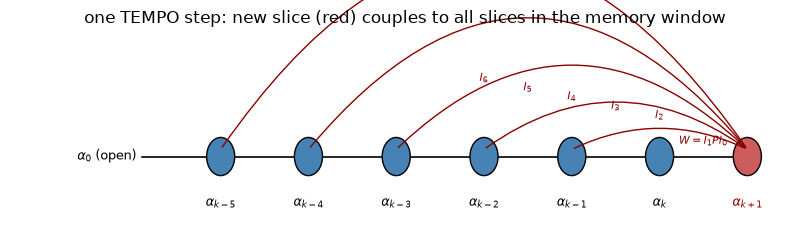

In [33]:
# schematic of the step-(k+1) tensor network
fig, ax = plt.subplots(figsize=(8.2, 2.6))
Kv = 6
for i in range(Kv):
    ax.add_patch(plt.Circle((i, 0), 0.16, fc='steelblue', ec='k', zorder=3))
    ax.text(i, -0.42, rf'$\alpha_{{k-{Kv-1-i}}}$' if i < Kv-1 else r'$\alpha_k$',
            ha='center', fontsize=9)
ax.add_patch(plt.Circle((Kv, 0), 0.16, fc='indianred', ec='k', zorder=3))
ax.text(Kv, -0.42, r'$\alpha_{k+1}$', ha='center', fontsize=9, color='darkred')
ax.plot(range(Kv), [0]*Kv, 'k-', lw=1.2, zorder=1)
ax.plot([Kv-1, Kv], [0, 0], 'k-', lw=1.2, zorder=1)
ax.text(Kv-0.5, 0.10, r'$W=I_1PI_0$', fontsize=8, ha='center', color='darkred')
for dlt in range(2, Kv+1):
    x0 = Kv - dlt
    ax.annotate('', xy=(Kv, 0.06), xytext=(x0, 0.06),
                arrowprops=dict(arrowstyle='-', color='darkred', lw=1,
                                connectionstyle=f'arc3,rad={-0.12*dlt}'))
    ax.text((x0+Kv)/2, 0.16 + 0.078*dlt, rf'$I_{{{dlt}}}$', fontsize=8,
            ha='center', color='darkred')
ax.plot([-0.9, 0], [0, 0], 'k-', lw=1.2)
ax.text(-0.95, 0.0, r'$\alpha_0$ (open)', ha='right', va='center', fontsize=9)
ax.set_xlim(-2.4, Kv+0.6); ax.set_ylim(-0.7, 1.05); ax.axis('off')
ax.set_title('one TEMPO step: new slice (red) couples to all slices in the memory window')
plt.tight_layout(); plt.show()

<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:94: SyntaxWarning: invalid escape sequence '\e'
<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:94: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_5156/3648544575.py:87: SyntaxWarning: invalid escape sequence '\e'
  'title': "Diagramm 3: Lokale $\eta$-Tiles ($I_0$)",
/tmp/ipykernel_5156/3648544575.py:94: SyntaxWarning: invalid escape sequence '\e'
  'title': "Diagramm 4: Nicht-lokale $\eta$-Tiles, Cutoff K=2 ($I_{k-k'}$)",


Plot gespeichert unter anatomy_tempo_couplings.png


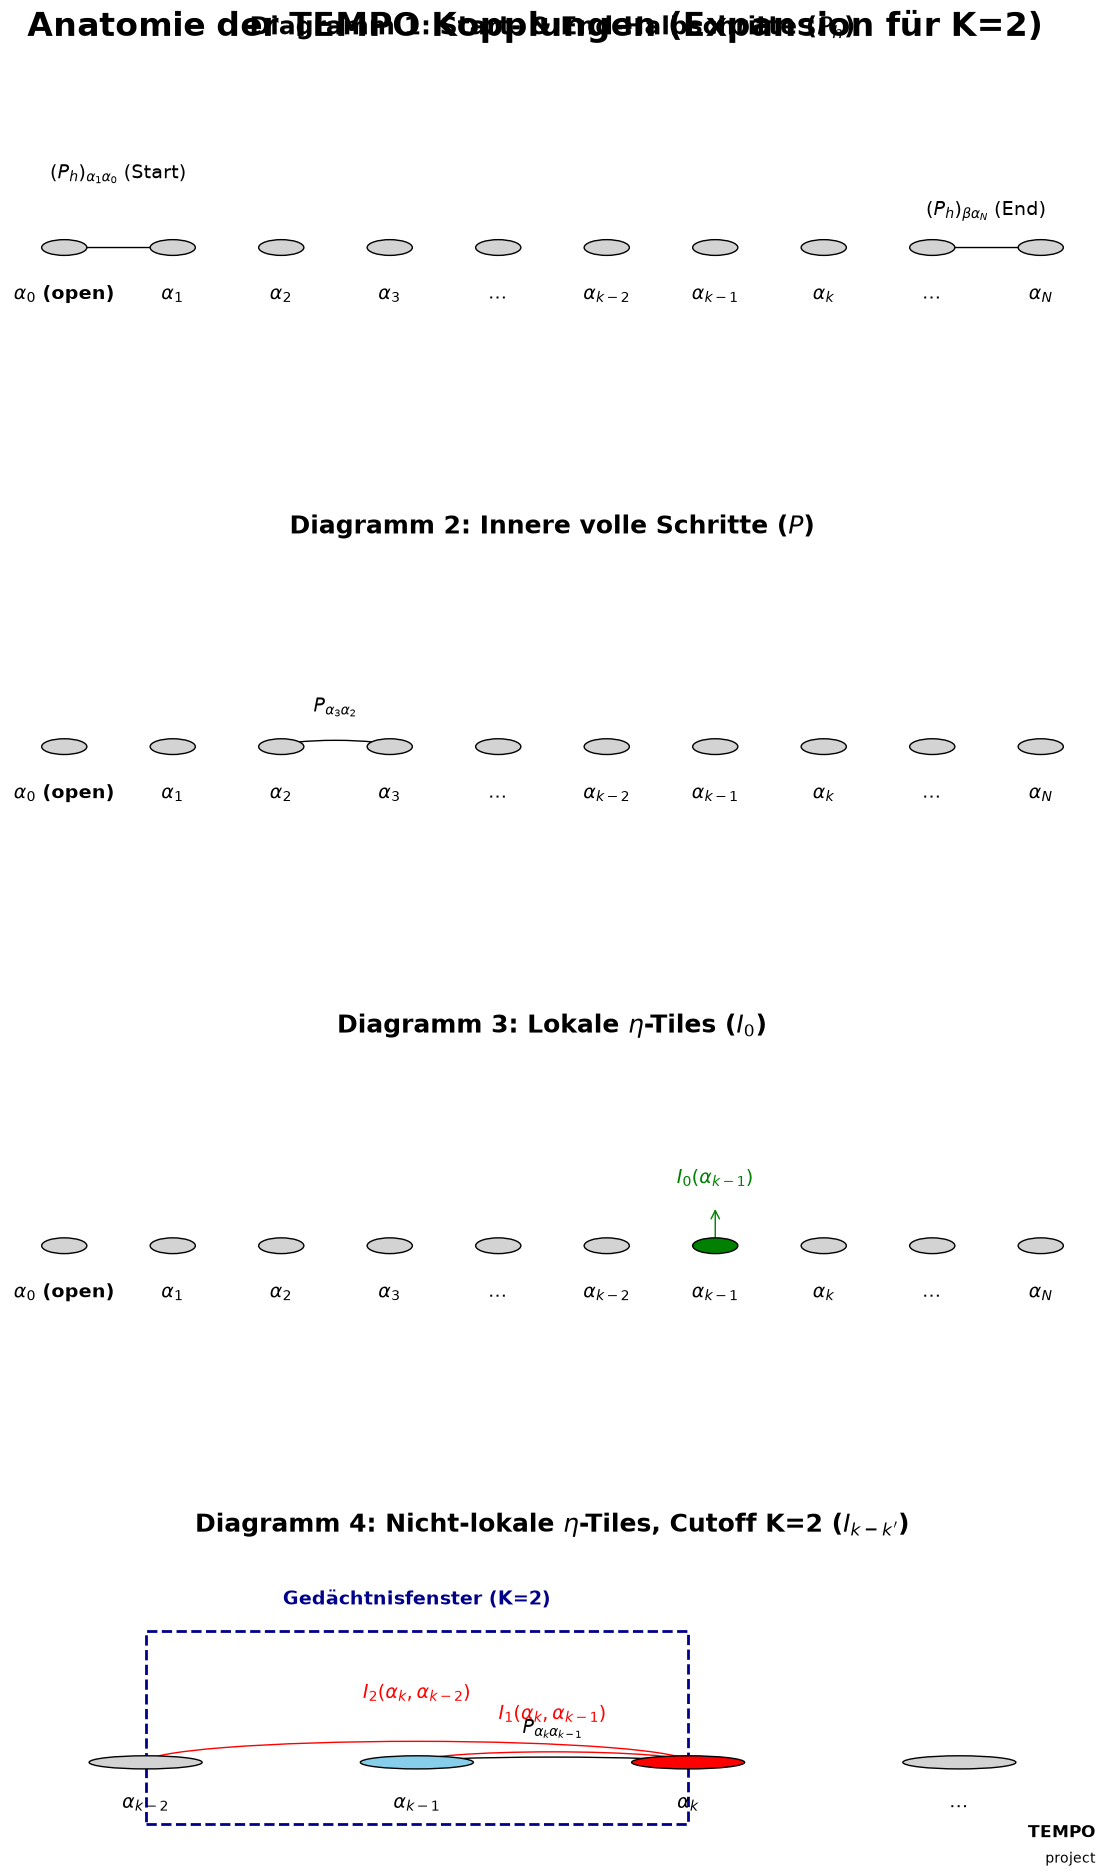

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- Allgemeine Diagramm-Einstellungen ---
plt.rcParams['text.usetex'] = False  # Setzen Sie dies auf True, falls LaTeX vollständig konfiguriert ist.
plt.rcParams['font.size'] = 14       # Erhöhte Standardschriftgröße für bessere Lesbarkeit
plt.rcParams['font.family'] = 'sans-serif' # Nur generische Familie, keine spezifischen Schriftarten

# --- Hilfsfunktionen zum Zeichnen ---
def draw_chain(ax, nodes_info, chain_y=0):
    for node in nodes_info:
        node_x = node['x']
        node_color = node.get('color', 'lightgray')
        node_label = node['label']
        # Knoten zeichnen
        ellipse = patches.Ellipse((node_x, chain_y), width=25, height=15, facecolor=node_color, edgecolor='black', zorder=2)
        ax.add_patch(ellipse)
        # Beschriftung hinzufügen
        ax.text(node_x, chain_y - 35, node_label, ha='center', va='top', fontsize=14, weight='bold')

def draw_propagator_arc(ax, start_x, end_x, y=0, color='black', style='-', label=None):
    if start_x == end_x: return
    center_x = (start_x + end_x) / 2
    height = abs(end_x - start_x) * 0.2 # Erhöhte Höhe proportional zur Distanz
    arc = patches.Arc((center_x, y), width=abs(end_x - start_x), height=height, angle=0, theta1=0, theta2=180, color=color, linestyle=style, zorder=1)
    ax.add_patch(arc)
    if label:
        ax.text(center_x, y + height + 15, label, ha='center', va='bottom', fontsize=14, color=color, weight='bold') # Text weiter oben

def draw_tile_arc(ax, start_x, end_x, y=0, color='red', label=None):
    if start_x == end_x: return
    center_x = (start_x + end_x) / 2
    height = abs(end_x - start_x) * 0.4 # Nicht-lokale Tiles werden deutlich höher gezeichnet
    arc = patches.Arc((center_x, y), width=abs(end_x - start_x), height=height, angle=0, theta1=0, theta2=180, color=color, zorder=1)
    ax.add_patch(arc)
    if label:
        ax.text(center_x, y + height + 20, label, ha='center', va='bottom', fontsize=14, color=color, weight='bold') # Text weiter oben

def draw_halfstep_arrow(ax, start_x, end_x, y=0, color='black', label=None, label_pos='top'):
    arrow = patches.FancyArrowPatch((start_x, y), (end_x, y), arrowstyle='->', mutation_scale=15, color=color, shrinkA=0, shrinkB=0, zorder=1)
    ax.add_patch(arrow)
    if label:
        label_y = y + 25 if label_pos == 'top' else y - 25
        va = 'bottom' if label_pos == 'top' else 'top'
        ax.text((start_x + end_x) / 2, label_y, label, ha='center', va=va, fontsize=14, color=color)

def draw_local_tile_arrow(ax, node_x, y=0, color='green', label=None):
    arrow = patches.FancyArrowPatch((node_x, y + 7.5), (node_x, y + 35), arrowstyle='->', mutation_scale=15, color=color, shrinkA=0, shrinkB=0, zorder=1)
    ax.add_patch(arrow)
    if label:
        ax.text(node_x, y + 55, label, ha='center', va='bottom', fontsize=14, color=color, weight='bold')

# --- Knoten-Platzierung und Ketten-Setup ---
node_spacing = 60
nodes = [
    {'x': 0, 'label': r'$\alpha_0$ (open)'},
    {'x': node_spacing, 'label': r'$\alpha_1$'},
    {'x': node_spacing*2, 'label': r'$\alpha_2$'},
    {'x': node_spacing*3, 'label': r'$\alpha_3$'},
    {'x': node_spacing*4, 'label': r'$\dots$'},
    {'x': node_spacing*5, 'label': r'$\alpha_{k-2}$'},
    {'x': node_spacing*6, 'label': r'$\alpha_{k-1}$'},
    {'x': node_spacing*7, 'label': r'$\alpha_k$'},
    {'x': node_spacing*8, 'label': r'$\dots$'},
    {'x': node_spacing*9, 'label': r'$\alpha_N$'},
]

# --- Daten für die vier Diagramme ---
chains_data = [
    {
        'title': "Diagramm 1: Start- & End-Halbschritte ($P_h$)",
        'nodes': [dict(node, color='lightgray') for node in nodes],
        'actions': [
            {'type': 'halfstep', 'start_idx': 0, 'end_idx': 1, 'label': r'$(P_h)_{\alpha_1\alpha_0}$ (Start)'},
            {'type': 'halfstep', 'start_idx': 8, 'end_idx': 9, 'label': r'$(P_h)_{\beta\alpha_N}$ (End)'},
        ]
    },
    {
        'title': "Diagramm 2: Innere volle Schritte ($P$)",
        'nodes': [dict(node, color='lightgray') for node in nodes],
        'actions': [
            {'type': 'propagator', 'start_idx': 2, 'end_idx': 3, 'label': r'$P_{\alpha_3\alpha_2}$'},
        ]
    },
    {
        'title': "Diagramm 3: Lokale $\eta$-Tiles ($I_0$)",
        'nodes': [dict(node, color='lightgray' if node['label'] != r'$\alpha_{k-1}$' else 'green') for node in nodes],
        'actions': [
            {'type': 'local', 'idx': 6, 'label': r'$I_0(\alpha_{k-1})$'},
        ]
    },
    {
        'title': "Diagramm 4: Nicht-lokale $\eta$-Tiles, Cutoff K=2 ($I_{k-k'}$)",
        # Zoom-Subset der Knoten für dieses Diagramm definieren
        'nodes': [
            {'x': node_spacing*5, 'label': r'$\alpha_{k-2}$', 'color': 'lightgray'},
            {'x': node_spacing*6, 'label': r'$\alpha_{k-1}$', 'color': 'skyblue'},
            {'x': node_spacing*7, 'label': r'$\alpha_k$', 'color': 'red'},
            {'x': node_spacing*8, 'label': r'$\dots$', 'color': 'lightgray'},
        ],
        'memory_window': True,
        'actions': [
            {'type': 'tile', 'start_idx': 1, 'end_idx': 2, 'label': r'$I_1(\alpha_k, \alpha_{k-1})$', 'color': 'red'},
            {'type': 'tile', 'start_idx': 0, 'end_idx': 2, 'label': r'$I_2(\alpha_k, \alpha_{k-2})$', 'color': 'red'},
            # Zeigt zum Vergleich auch den P-Propagator
            {'type': 'propagator', 'start_idx': 1, 'end_idx': 2, 'label': r'$P_{\alpha_k\alpha_{k-1}}$', 'color': 'black'}
        ]
    }
]

# --- Diagramm-Erstellung ---
fig, axes = plt.subplots(4, 1, figsize=(14, 20)) # Etwas höher für bessere Lesbarkeit
plt.subplots_adjust(hspace=0.9, top=0.94, bottom=0.06)
fig.suptitle('Anatomie der TEMPO Kopplungen (Expansion für K=2)', fontsize=24, weight='bold')

# Iteriert durch jedes Diagramm
for ax, chain_info in zip(axes, chains_data):
    ax.set_title(chain_info['title'], fontsize=18, weight='bold', pad=40) # Größerer Titel, mehr Abstand
    ax.axis('off')

    # Knoten zeichnen und X-Limits setzen
    nodes_to_draw = chain_info['nodes']
    if chain_info.get('memory_window', False):
        ax.set_xlim(node_spacing*4.5, node_spacing*8.5) # Subset-Zoom
        ax.set_ylim(-100, 200) # Mehr Platz nach oben für hohe Bögen
        draw_chain(ax, nodes_to_draw, chain_y=0)
        # Gedächtnisfenster-Rahmen zeichnen
        window_rect = patches.Rectangle((node_spacing*5, -70), width=node_spacing*2, height=220, linewidth=2, edgecolor='darkblue', linestyle='--', facecolor='none', zorder=1)
        ax.add_patch(window_rect)
        ax.text(node_spacing*6, 175, r'Gedächtnisfenster (K=2)', ha='center', va='bottom', fontsize=14, color='darkblue', weight='bold')
    else:
        ax.set_xlim(-node_spacing/2, node_spacing*9.5) # Vollketten-Sicht
        ax.set_ylim(-100, 150)
        draw_chain(ax, nodes_to_draw, chain_y=0)

    # Aktionen auf diesem Diagramm ausführen
    for action in chain_info['actions']:
        if action['type'] == 'halfstep':
            start_x = nodes[action['start_idx']]['x']
            end_x = nodes[action['end_idx']]['x']
            # Spezielle Positionierung für D1 Start-HS
            if action['label'].endswith('(Start)'):
                 ax.text((start_x + end_x) / 2, 60, action['label'], ha='center', va='bottom', fontsize=14, color='black')
                 draw_halfstep_arrow(ax, start_x, end_x, color='black', label=None)
            else:
                draw_halfstep_arrow(ax, start_x, end_x, label=action['label'])
        elif action['type'] == 'propagator':
             # X-Positionen aus der gezeichneten Knotenliste holen
            x_map = {n['label']: n['x'] for n in nodes_to_draw}
            start_label = nodes_to_draw[action['start_idx']]['label']
            end_label = nodes_to_draw[action['end_idx']]['label']
            start_x = x_map[start_label]
            end_x = x_map[end_label]
            draw_propagator_arc(ax, start_x, end_x, color=action.get('color', 'black'), label=action.get('label'))
        elif action['type'] == 'local':
            node_x = nodes[action['idx']]['x']
            draw_local_tile_arrow(ax, node_x, label=action['label'])
        elif action['type'] == 'tile':
             # X-Positionen aus der gezoomten Knotenliste holen
            x_map = {n['label']: n['x'] for n in nodes_to_draw}
            start_label = nodes_to_draw[action['start_idx']]['label']
            end_label = nodes_to_draw[action['end_idx']]['label']
            start_x = x_map[start_label]
            end_x = x_map[end_label]
            draw_tile_arc(ax, start_x, end_x, color=action.get('color', 'red'), label=action.get('label'))

# --- Finaler Schliff ---
logo_x = node_spacing*8.5
logo_y = -90
axes[3].text(logo_x, logo_y, 'TEMPO', ha='right', va='bottom', fontsize=12, weight='bold')
axes[3].text(logo_x, logo_y - 12, 'project', ha='right', va='top', fontsize=10)

# Ausgabe-Dateiname
final_filename = "anatomy_tempo_couplings.png"
plt.savefig(final_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot gespeichert unter {final_filename}")

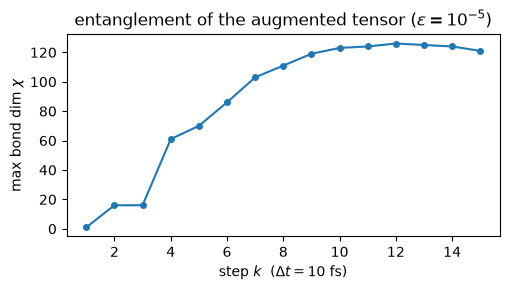

per-step wall times [s]: [ 0.    2.55  1.21  5.18  7.71 12.83 15.01 25.38 20.01 50.06 26.42 19.15
 25.03 36.55]


In [34]:
# small demonstration run: watch the bond dimension saturate (~1 min)
import time
pm = PathIntegralMap(H, dt_fs, kmax=K, lam_cm=LAM, gamma_cm=GAM, T_K=TEMP,
                     eps=1e-5, chi_max=512)
T0 = (pm.I0[:, None] * pm.Ph).T
mps = [T0[:, :, None].copy()]
chis, times = [1], [0.0]
for k in range(2, 16):
    t1 = time.time()
    mps = pm._step(mps)
    times.append(time.time() - t1)
    chis.append(max(t.shape[2] for t in mps))
plt.figure(figsize=(5.2, 3))
plt.plot(range(1, 16), chis, 'o-', ms=4)
plt.xlabel('step $k$  ($\\Delta t = 10$ fs)'); plt.ylabel(r'max bond dim $\chi$')
plt.title(r'entanglement of the augmented tensor ($\varepsilon=10^{-5}$)')
plt.tight_layout(); plt.show()
print("per-step wall times [s]:", np.round(times[1:], 2))

### Implementierung von $\mathcal{L}(t_N)_{\beta\,\alpha_0}$
Um zu erklären wie wir dieses riesige Produkt implementieren, starten wir mit folgender Formel: 
$$\begin{aligned}\mathcal{L}(t_N)_{\beta\,\alpha_0} &= \sum_{\alpha_1\ldots\alpha_N} \sum_{c_1\dots c_N} (P_h)_{\beta\alpha_N} \left[ \prod_{k=1}^{N} W^{(k)}(\alpha_k, c_{k-1}) \cdot \mathbb{1}\big[\,c_k = (\alpha_{k-K+1}, \dots, \alpha_k)\,\big]\right] \end{aligned}$$Wenn wir die Indizes explizit ausschreiben, können wir das Produkt der noch unkomprimierten Kette mit den Indizes $y_k$ als Summe notieren:$$\text{Gesamt} \equiv \sum_{y_1 \dots y_{N-1}} W^{(1)}_{\alpha_0, \alpha_1, y_1} \cdot W^{(2)}_{y_1, \alpha_2, y_2} \cdot W^{(3)}_{y_2, \alpha_3, y_3} \cdot W^{(4)}_{y_3, \alpha_4, y_4} \dots W^{(N)}_{y_{N-1}, \alpha_N, y_N}$$

Hierbei ist $W^{(1)}_{\alpha_0, \alpha_1, y_1}$ ein 3D Tensor (z.B $16 \times 16 \times 16)$ und der Index $y_i$ gibt an über welche Dimension man bei der Matrixmultiplikation summiert (so wie bei $\text{Result} = \sum_m A_{k,l,m} \cdot B_{m,n,o}$). Wir werden den 3D tensor $W^{(1)}_{\alpha_0, \alpha_1, y_1}$ in eine 2D Matrix $W^{(1)}_{\alpha_0, \alpha_1, y_1}$ verwandeln um eine Matrixmultiplikation durchführen zu können. Dieses $W^{(1)}_{(\alpha_0, \alpha_1), y_1}$ werden wir später $M^{(1)}_{(\alpha_0, \alpha_1), y_1}$ nennen. 

Das $W$ enthält theoretisch alle Kopplungen aller Kombinationen des gesamten Zeitfensters. Das sind die Indizes $(\alpha_0, \alpha_1)$ (für $K=2$ ist das $16 \times 16$) und muss dieses ganze Zeitfenster an das nächste zeitfenster koppeln das wieder 16 eingangskanäle für 16 Matrixelemente hat. Das ist der Index $y_1$. Hätten wir kein Fenster Fenster der Größe $K=2$ mit $(\alpha_o,...,\alpha_1)$ sondern eines der Größe $K$, dann hätten wir $(\alpha_0,...,\alpha_{K-1}) \equiv (\alpha_0, c_k)$. Machen wir ein Bsp für eine Liuoville Dimension von 16  und $K=2$. 
- Dann haben wir im ersten Zeitfenster $(\alpha_0, \alpha_1)$ und daher $16 \times 16$ Kombinationen von Übergängen. Diese $(16,16)$ - Felder koppeln wieder an 16 neue Matrixelemente im nächsten Zeitschritt ($k=3$). Daher kommen die Terme $W^{(1)}_{(16,16), 16}$. 
- Bei $k=3$ haben wir also die Kopllung des (16,16) Blocks (256 Spalten) mit 16 neuen Matrixelementen (16 Zeilen). Bei $k=3$ hat man dann schon 16*256=4096 Einträge. Diese koppeln bei $k=4$ wieder an 16 neue Matrixelemente. 
- Daher hat man bei $k=4$ schon 256 Zeilen die alle Matrixelemente des (16,16) Blocks von $k=3$ beinhalten und 4096 Spalten da jedes dieser 256 Einträge mit 16 neuen Einträgen von $k=4$ koppelt.

$$W^{(1)}_{(\alpha_0, \alpha_1),\, y_1} = \begin{pmatrix}  W^{(1)}_{(1,1), 1} & W^{(1)}_{(1,1), 2} & \dots & W^{(1)}_{(1,1), 16} \\  W^{(1)}_{(1,2), 1} & W^{(1)}_{(1,2), 2} & \dots & W^{(1)}_{(1,2), 16} \\  \vdots & \vdots & \ddots & \vdots \\  W^{(1)}_{(16,16), 1} & W^{(1)}_{(16,16), 2} & \dots & W^{(1)}_{(16,16), 16}  \end{pmatrix} \qquad W^{(2)}_{(y_1, \alpha_2),\, y_2} = \begin{pmatrix}  W^{(2)}_{(1,1), 1} & W^{(2)}_{(1,1), 2} & \dots & W^{(2)}_{(1,1), 256} \\  W^{(2)}_{(1,2), 1} & W^{(2)}_{(1,2), 2} & \dots & W^{(2)}_{(1,2), 256} \\  \vdots & \vdots & \ddots & \vdots \\  W^{(2)}_{(16,16), 1} & W^{(2)}_{(16,16), 2} & \dots & W^{(2)}_{(16,16), 256}  \end{pmatrix}$$

$$W^{(3)}_{(y_2, \alpha_3),\, y_3} = \begin{pmatrix}  W^{(3)}_{(1,1), 1} & W^{(3)}_{(1,1), 2} & \dots & W^{(3)}_{(1,1), 4096} \\  W^{(3)}_{(1,2), 1} & W^{(3)}_{(1,2), 2} & \dots & W^{(3)}_{(1,2), 4096} \\  \vdots & \vdots & \ddots & \vdots \\  W^{(3)}_{(256,16), 1} & W^{(3)}_{(256,16), 2} & \dots & W^{(3)}_{(256,16), 4096}  \end{pmatrix} \qquad W^{(4)}_{(y_3, \alpha_4),\, y_4} = \begin{pmatrix}  W^{(4)}_{(1,1), 1} & W^{(4)}_{(1,1), 2} & \dots & W^{(4)}_{(1,1), 65536} \\  \vdots & \vdots & \ddots & \vdots \\  W^{(4)}_{(4096,16), 1} & W^{(4)}_{(4096,16), 2} & \dots & W^{(4)}_{(4096,16), 65536}  \end{pmatrix}$$

Diese Matrizen sind viel zu groß um sie mit einander zu multiplizieren. Daher müssen wir eine Geschickte singular value decomposition machen, die das Problem löst. Das sehen wir in der nächsten Zellen.

### Singular Value Decomposition (SVD)

Zuerst beweisen wir, dass die SVD einer eingabematrix $X$ die Vektoren $u_i$ findet, die in die Richtung der größten Varianz zeigen. Hier sind die $u_i$ Spaltenvektoren von $U$ welches sich durch die SVD von $X$ ergibt: $$X = U \Sigma V^\dagger$$ Alle Matrizen sind hier $n \times n$ Matrizen. Damit die SVD wirklich die Varianz misst, müssen wir annehmen, dass unsere Matrix $X$ zentriert ist (der Mittelwert jeder Zeile ist null). Um die Richtungen der größten Varianz zu finden, führen wir die Covarianzmatrix $C$ ein: $C = X X^\dagger$. Mit $X = U \Sigma V^\dagger$ kann man das schreiben als: 
$$C = (U \Sigma V^\dagger) \cdot (U \Sigma V^\dagger)^\dagger = (U \Sigma V^\dagger) \cdot (V \Sigma^\dagger U^\dagger) = U \Sigma (V^\dagger V) \Sigma U^\dagger = U \Sigma I \Sigma U^\dagger = U \Sigma^2 U^\dagger$$
Wenn wir die Gleichung von rechts mit $U$ multiplizieren (und bedenken, dass $U^\dagger U = I$), erhalten wir:$$C U = U \Sigma^2$$Betrachten wir das für einen einzelnen Spaltenvektor $\vec{u}_i$ aus der Matrix $U$, steht dort exakt die klassische Eigenwertgleichung:$$C \vec{u}_i = \sigma_i^2 \vec{u}_i$$
- Die Vektoren $\vec{u}_i$ (die Spalten von $U$) sind die Eigenvektoren der Kovarianzmatrix. In der Mathematik der Kovarianzmatrizen zeigen die Eigenvektoren physikalisch/geometrisch exakt in die Richtungen der unabhängigen Varianzen der Daten.
- Die quadrierten Singulärwerte $\sigma_i^2$ sind die zugehörigen Eigenwerte. Sie geben exakt den Betrag der Varianz in dieser Richtung an.

Da die SVD standardmäßig so sortiert ist, dass der größte Singulärwert $\sigma_1$ ganz oben links steht, gehört die erste Spalte von $U$ ($\vec{u}_1$) zwingend zum größten Eigenwert $\sigma_1^2$.

**Die rSVD:** 

Wir können keine normale SVD einer großen Matrix machen und daher können wir die Vektoren $u_i$, die die Richtung der meisten Information angeben nicht bestimmen. Wir wollen daher eine kleine Basis finden, die den wichtigsten Teil von $M$ (die größten Singulärwerte) gut beschreibt.
Wenn wir $M$ mit einer rein gausschen Zufallsmatrix $G$ multiplizieren ($Y_0 = MG$), erhalten wir Vektoren, die zufällig im Bildraum von $M$ liegen. Die Zahl $k$ der Spalten von $G$ gibt die Zahl der Spalten der Matrix $Y$ und somit die Zahl der Basisvektoren die wir später finden wollen an. $k$ wird meist aus dem vorherigen zeitschritt geschätzt (`rank_hint`) und noch mit einer Konstante (hier 64) addiert um sicherzustellen dass $G$ groß genung ist um nicht zufällig eine Richtung nicht enthält. Anstelle einer ganzen Matrix $G$ betrachten wir erstmal die Multiplikation von $M = U \Sigma V^\dagger$ mit einer Spalte $g$ von $G$:
$$\vec{y} = M \vec{g} = U \Sigma V^\dagger \vec{g}$$

$V^\dagger$ ist eine Rotationsmatrix (unitär). Wenn man einen Vektor aus normalverteiltem Rauschen ($\vec{g}$) im Raum dreht, bleibt er ein Vektor aus normalverteiltem Rauschen. Wir definieren also den Vektor $\vec{g}' = V^\dagger \vec{g}$. Somit ist jeder einzelne seiner Einträge $g'_i$ ist eine Zufallszahl ungleich Null. Er hat also in jeder mathematischen Dimension einen Anteil.

Jetzt schreiben wir die verbleibende Multiplikation $U \Sigma \vec{g}'$ komponentenweise als Summe auf.Die Matrix $U$ besteht aus den Spaltenvektoren $\vec{u}_1, \vec{u}_2, \dots, \vec{u}_n$ (das sind unsere gesuchten linken Singulärvektoren).Die Matrix $\Sigma$ enthält die Singulärwerte $\sigma_1, \sigma_2, \dots, \sigma_n$ auf der Diagonalen. Wenn wir das ausmultiplizieren, ergibt sich $\vec{y}$ als eine Linearkombination aller Singulärvektoren:$$\vec{y} = \sum_{i=1}^n (\sigma_i \cdot g'_i) \cdot \vec{u}_i$$
Der resultierende Vektor $\vec{y}$ ist ein "Mix" aus allen möglichen Richtungen $\vec{u}_i$, wobei $\sigma_i \cdot g'_i$ das Gewicht für jede Richtung ist. Wenn $\sigma_1 = 1000$ (eine dominante Richtung) und $\sigma_{100} = 0.1$ (eine unwichtige Richtung) ist, dann hat der Vektor $\vec{y}$ tausendmal mehr Anteil in Richtung $\vec{u}_1$ als in Richtung $\vec{u}_{100}$. Der Vektor $\vec{y}$ wird also unausweichlich fast parallel zu den stärksten Richtungen gezogen. Das gilt also für alle Vektoren $y$. Verallgemeinern wir das auf eine Matrix $Y$ mit Spaltenvektoren $y$ erhlten wir $Y = U \Sigma V^\dagger G$. Hier enthält $Y$ lauter vektoren die stark in die Richtung des größten Singulärvektors $u_i$ (der zum größten Singulärwerts $\sigma_i$ gehört) zeigen der die Richutng der größten Varianz, also der meisten Information angibt. 

Oft ist es so dass die Singulärwerte alle ähnlich groß sind. Um die richtung der größten Singulärwerte schneller zu finden, können wir die Gleichung mithilfe von $U U^\dagger = V V^\dagger = I$ wie folgt modifizieren:$$Y = M M^\dagger M G = (U \Sigma V^\dagger)(V \Sigma U^\dagger) (U \Sigma V^\dagger) G = (U \Sigma^2 U^\dagger) \cdot (U \Sigma V^\dagger) = U \Sigma^3 V^\dagger G$$
Für einen Vektor $y$ heist das: $$\vec{y}_{\text{power}} = \sum_{i=1}^n (\sigma_i^3 \cdot g'_i) \cdot \vec{u}_i$$
Ist $\sigma_i$ nun groß wird seine Größe durch die Potenz noch zusätzlich verstärkt und wir finden die singuläre Richtung $u_i$ der größten Varianz am schnellsten. Wir können die Matrix $Y$ also finden, indem wir die Matrix $M$ mit $G$ multiplizieren, was sehr billig ist.

**Die QR-Zerlegung:**

Alle Vekroren $y$ in $Y$ zeigen nun in die Richtung der größten Varianz und bestehen jetzt fast ausschließlich aus den dominantesten Vektoren (wie $\vec{u}_1, \vec{u}_2, \vec{u}_3$). Sie sind also beinahe parallel. Das ist jedoch ungünstig wenn wir eine Basis aus mehereren Vektoren finden wollen. Daher verwenden wir die QR-Zerlegung. Sie macht folgendes:
- Sie nimmt die erste Spalte von $Y$ und normiert sie auf die Länge 1. Man bekommt: $\vec{q}_1 = \frac{\vec{y}_1}{\lVert\vec{y}_1\rVert}$. Das ist unsere erste neue Basisrichtung (sie zeigt schon sehr stark in Richtung $\vec{u}_1$).
- Sie nimmt die zweite Spalte von $Y$. Da diese fast parallel zur ersten ist, zieht der Algorithmus den gesamten Anteil ab, der in die erste Richtung zeigt. Übrig bleibt nur der kleine Rest, der in eine neue, orthogonale Richtung zeigt. Dieser Rest wird wieder auf Länge 1 gestreckt. Man bekommt also: $\vec{v}_2 = \vec{y}_2 - (\vec{q}_1^\dagger \vec{y}_2)\vec{q}_1 \quad$ $\rightarrow \quad \vec{q}_2 = \frac{\vec{v}_2}{\lVert\vec{v}_2\rVert}$
- Das wiederholt sich für alle $k$ Spalten. Jedes Mal wird alles abgezogen, was wir schon durch die bisherigen Basisvektoren wissen. Am Ende stehen in $Q = (\vec{q_1},....,\vec{q_k})$ genau $k$ Vektoren, die denselben Raum wie $Y$ abdecken, aber alle im $90^\circ$-Winkel zueinander stehen.

Also haben wir eine Matrix $Y$, deren Spalten den wichtigsten Unterraum von $M$ (shape: $m \times n$) aufspannen. Mit der QR-Zerlegung $$Q, R = \text{qr}(Y)$$ machen wir aus diesen Spalten einfach nur eine saubere, orthonormale Basis $Q$. $R$ enthält die mathematischen "Mischungsverhältnisse". Es beschreibt exakt, wie die Spalten der Matrix $Y$ aus unserer neu gefundenen Basis $Q$ zusammengesetzt sind. Es gilt ja per Definition:$$Y = Q \cdot R$$Lass uns das an einem kleinen Beispiel mit 3 Spalten ($k=3$) visualisieren:$$\begin{pmatrix} \vert & \vert & \vert \\ \vec{y}_1 & \vec{y}_2 & \vec{y}_3 \\ \vert & \vert & \vert \end{pmatrix} = \begin{pmatrix} \vert & \vert & \vert \\ \vec{q}_1 & \vec{q}_2 & \vec{q}_3 \\ \vert & \vert & \vert \end{pmatrix} \cdot \begin{pmatrix} r_{11} & r_{12} & r_{13} \\ 0 & r_{22} & r_{23} \\ 0 & 0 & r_{33} \end{pmatrix}$$Wenn man diese Matrizenmultiplikation Zeile für Spalte auflöst, sieht man die Struktur des Gram-Schmidt-Verfahrens:
- $\vec{y}_1 = r_{11}\vec{q}_1$. Die erste Spalte von $Y$ zeigt komplett in die Richtung von $\vec{q}_1$. Der Wert $r_{11}$ ist einfach die Länge (Norm) des Vektors $\vec{y}_1$.
- $\vec{y}_2 = r_{12}\vec{q}_1 + r_{22}\vec{q}_2$. Die zweite Spalte von $Y$ wird aus zwei Teilen zusammengebaut: Ein Teil ($r_{12}$) zeigt in die Richtung der ersten Basis $\vec{q}_1$, und der verbleibende Rest ($r_{22}$) bildet die neue Richtung $\vec{q}_2$.
- $\vec{y}_3 = r_{13}\vec{q}_1 + r_{23}\vec{q}_2 + r_{33}\vec{q}_3$ und so weiter.

$Q$ hat die Dimension $m \times k$ (wobei $k \ll n, m$).Da $Q$ den Bildraum von $M$ (fast) perfekt einfängt, gilt die Näherung ($Q$ ist eine Orthogonalbasis -> $Q^\dagger Q = I$):$$M \approx Q Q^\dagger M$$(Zur Erinnerung: $Q Q^\dagger$ ist der mathematische Projektionsoperator auf den Raum von $Q$. Was schon in dem Raum liegt, ändert sich durch die Projektion nicht). Wir definieren die kleine Matrix $B$ (shape: $k \times n$) als die Projektion von $M$ auf unsere Basis:$$B = Q^\dagger M$$Dann machen wir eine exakte SVD von diesem winzigen $B$:$$B = U_b \Sigma_b V_b^\dagger$$Setzen wir dieses $B$ nun in unsere Näherungsgleichung für $M$ von oben ein:$$M \approx Q \cdot B = Q \cdot (U_b \Sigma_b V_b^\dagger) = (Q U_b) \Sigma_b V_b^\dagger$$Ist das eine gültige SVD für $M$? Eine SVD erfordert, dass die linke Matrix orthogonale Spalten hat. Prüfen wir das für unsere neue linke Matrix $\tilde{U} = Q U_b$:$$\tilde{U}^\dagger \tilde{U} = (Q U_b)^\dagger (Q U_b) = U_b^\dagger U_b = I$$ Da $U_b$ aus einer exakten SVD stammt, ist auch dieses Produkt $I$. $\tilde{U}$ ist also strikt unitär! Daher dürfen wir die SVD von der kleinen Matrix $B$ berechnen und das linke Ergebnis einfach mit $Q$ multiplizieren. Das Resultat $((Q U_b), \Sigma_b, V_b^\dagger)$ ist eine mathematisch vollkommen legitime und extrem genaue SVD der ursprünglichen riesigen Matrix $M$ – nur eben auf die wesentlichen $k$ Dimensionen beschränkt. Die Matrix $\Sigma_b$ enthält in ihrer Diagonale die $k$ wichtigsten Singulärwerte ($B$ hat shape $k \times n$).

Da unsere Hilfsbasis $Q$ die gesamte relevante Information (Varianz) von $M$ bereits fehlerfrei eingefangen hat, hat die kleine Projektion $B$ exakt dieselben dominanten Singulärwerte $\Sigma_B$ wie das riesige Original $M$. Wir können die Diagonaleinträge $\sigma_1, \dots, \sigma_k$ also einfach 1:1 übernehmen. Sie geben an, wie viel Information (oder physikalisches Gewicht) in der jeweiligen Richtung steckt. Wir haben also eine vollständige, gültige (abgeschnittene) Singulärwertzerlegung der gigantischen Matrix $M$ gefunden:
$$M \approx \sum_{i=1}^k \tilde{\sigma}_i \cdot \tilde{\vec{u}}_i \cdot \tilde{\vec{v}}_i^\dagger$$

**Zusammenfassend:**
- Die SVD $X = U \Sigma V^\dagger$ findet die Richtung der größten Varianz. Die $\vec{u_i}$ aus $U = (\vec{u_1},...,\vec{u_k})$ sind genau diese Richtungen.
- $Y = M \cdot G$: findet die Richtung der stärksten Varianz. Alle $\vec{y_i}$ in $Y = (\vec{y_1},...,\vec{y_k})$ zeigen in eine Richtung die von $\vec{u_1}, \vec{u_2}, \vec{u_3}...$ dominiert wird.
- QR-Zerlegung: $Q, R = \text{qr}(Y)$: Macht aus den Spaltenvektoren von $Y$ eine Basis $Q = (\vec{q_1},...,\vec{q_k})$.
- $B = Q^\dagger M$ projeziert die große Matrix $M$ mit der neu gefundenen Basis $Q$ auf ein kleines $B$.
- Da $B$ so klein ist, können wir eine exakte SVD machen: $B = U_b \Sigma_b V_b^\dagger$. Daraus folgt: $M \approx Q \cdot B = Q \cdot (U_b \Sigma_b V_b^\dagger) = (Q U_b) \Sigma_b V_b^\dagger = \sum_{i=1}^k \tilde{\sigma}_i \cdot \tilde{\vec{u}}_i \cdot \tilde{\vec{v}}_i^\dagger$
- Wir können die große Matrix $M$ also durch die $k$ wichtigsten Singulärwerte annähern







### Use the rSVD and truncation
Das Produkt $\text{Gesamt}$ ist viel zu groß, um es auf einmal auszurechnen (die inneren Indizes $y_k$ würden exponentiell wachsen). Deshalb arbeiten wir uns sequenziell von links nach rechts durch. Das $W^{(k)}$ ist also einfach der nächste Baustein aus unserer globalen Formel, der jetzt an die Reihe kommt. Um die Dimension zu verringern, machen wir an jeder Stelle eine SVD und schneiden bei der maximalen Bond-Dimension $\chi$ ab. Hierzu beginnen wir mit der Formel von oben:

$$\begin{aligned}\mathcal{L}(t_N)_{\beta\,\alpha_0} &= \sum_{\alpha_1\ldots\alpha_N} \sum_{c_1\dots c_N} (P_h)_{\beta\alpha_N} \left[ \prod_{k=1}^{N} W^{(k)}(\alpha_k, c_{k-1}) \cdot \mathbb{1}\big[\,c_k = (\alpha_{k-K+1}, \dots, \alpha_k)\,\big]\right] \end{aligned}$$Wenn wir die Indizes explizit ausschreiben, können wir das Produkt der noch unkomprimierten Kette mit den Indizes $y_k$ als Summe notieren:$$\text{Gesamt} \equiv \sum_{y_1 \dots y_{N-1}} W^{(1)}_{\alpha_0, \alpha_1, y_1} \cdot W^{(2)}_{y_1, \alpha_2, y_2} \cdot W^{(3)}_{y_2, \alpha_3, y_3} \cdot W^{(4)}_{y_3, \alpha_4, y_4} \dots W^{(N)}_{y_{N-1}, \alpha_N, y_N}$$

Das $W$ enthält theoretisch alle Kopplungen aller Kombinationen des gesamten Zeitfensters. Das sind die Indizes $(\alpha_0, \alpha_1)$ (für $K=2$ ist das $16 \times$) und muss dieses ganze Zeitfenster an das nächste zeitfenster koppeln das wieder 16 eingangskanäle für 16 Matrixelemente hat. Das ist der Index $y_1$.
Dieses Produkt ist viel zu groß, um es auf einmal auszurechnen (die inneren Indizes $y_k$ würden exponentiell wachsen). Deshalb arbeiten wir uns sequenziell von links nach rechts durch. Das $W^{(k)}$ ist also einfach der nächste Baustein aus unserer globalen Formel, der jetzt an die Reihe kommt. Um die Dimension zu verringern, machen wir an jeder Stelle eine SVD und schneiden bei der maximalen Bond-Dimension $\chi$ ab. Hierzu definieren wir für den ersten Schritt:$$\text{SVD}\Big[W^{(1)}_{\alpha_0, \alpha_1, y_1}\Big] \approx \sum_{c_1=1}^{\chi} U^{(1)}_{(\alpha_0, \alpha_1), c_1} \Sigma^{(1)}_{c_1} (V^\dagger)^{(1)}_{c_1, y_1} \equiv \sum_{c_1=1}^{\chi} G^{(1)}_{\alpha_0, \alpha_1, c_1} C^{(1)}_{c_1, y_1}$$wobei $G^{(1)}_{\alpha_0, \alpha_1, c_1} = U^{(1)}_{(\alpha_0, \alpha_1), c_1}$ und $C^{(1)}_{c_1, y_1} = \Sigma^{(1)}_{c_1} (V^\dagger)^{(1)}_{c_1, y_1}$. Mit der Definition $M^{(i)}_{c_{i-1}, \alpha_i, y_i} = \sum_{y_{i-1}} C^{(i-1)}_{c_{i-1}, y_{i-1}} W^{(i)}_{y_{i-1}, \alpha_i, y_i}$ erhalten wir für alle weiteren Schritte:$$\text{SVD}\Big[M^{(i)}_{(c_{i-1}, \alpha_i), y_i}\Big] \approx \sum_{c_i=1}^{\chi} U^{(i)}_{(c_{i-1}, \alpha_i), c_i} \Sigma^{(i)}_{c_i} (V^\dagger)^{(i)}_{c_i, y_i} \equiv \sum_{c_i=1}^\chi G^{(i)}_{c_{i-1}, \alpha_i, c_i} C^{(i)}_{c_i, y_i}$$Verwenden wir diese Definitionen in unserer Kette, können wir die SVD (inklusive der Trunkierung auf $\chi$) von links nach rechts durchschieben:

$$\begin{aligned}  \text{Gesamt} &= \sum_{ {\color{#FF5555}{y_1}}, {\color{#66CCFF}{y_2}} \dots} \underbrace{\underset{(256 \times {\color{#FF5555}{16}})}{W^{(1)}_{\alpha_0, \alpha_1, {\color{#FF5555}{y_1}}}}}_{\text{SVD}} \cdot \underset{({\color{#FF5555}{16}} \times 16 \times {\color{#66CCFF}{256}})}{W^{(2)}_{{\color{#FF5555}{y_1}}, \alpha_2, {\color{#66CCFF}{y_2}}}} \cdot \underset{({\color{#66CCFF}{256}} \times 16 \times {\color{#55FF55}{4096}})}{W^{(3)}_{{\color{#66CCFF}{y_2}}, \alpha_3, {\color{#55FF55}{y_3}}}} \dots \\  &\approx \sum_{ {\color{#FF5555}{y_1}}, {\color{#66CCFF}{y_2}} \dots} \sum_{ {\color{#D388FF}{c_1}}=1}^{{\color{#D388FF}{\chi_1}}} \Big( \underset{(256 \times {\color{#D388FF}{\chi_1}})}{G^{(1)}_{(\alpha_0, \alpha_1), {\color{#D388FF}{c_1}}}} \cdot \underset{({\color{#D388FF}{\chi_1}} \times {\color{#FF5555}{16}})}{C^{(1)}_{{\color{#D388FF}{c_1}}, {\color{#FF5555}{y_1}}}} \Big) \cdot \underset{({\color{#FF5555}{16}} \times 16 \times {\color{#66CCFF}{256}})}{W^{(2)}_{{\color{#FF5555}{y_1}}, \alpha_2, {\color{#66CCFF}{y_2}}}} \cdot \underset{({\color{#66CCFF}{256}} \times 16 \times {\color{#55FF55}{4096}})}{W^{(3)}_{{\color{#66CCFF}{y_2}}, \alpha_3, {\color{#55FF55}{y_3}}}} \dots \\  &= \sum_{ {\color{#66CCFF}{y_2}}, {\color{#55FF55}{y_3}} \dots} \sum_{ {\color{#D388FF}{c_1}}=1}^{{\color{#D388FF}{\chi_1}}} \underset{(256 \times {\color{#D388FF}{\chi_1}})}{G^{(1)}_{(\alpha_0, \alpha_1), {\color{#D388FF}{c_1}}}} \cdot \underbrace{\Big( \sum_{{\color{#FF5555}{y_1}}} \underset{({\color{#D388FF}{\chi_1}} \times {\color{#FF5555}{16}})}{C^{(1)}_{{\color{#D388FF}{c_1}}, {\color{#FF5555}{y_1}}}} \cdot \underset{({\color{#FF5555}{16}} \times 16 \times {\color{#66CCFF}{256}})}{W^{(2)}_{{\color{#FF5555}{y_1}}, \alpha_2, {\color{#66CCFF}{y_2}}}} \Big)}_{\substack{\equiv M^{(2)}_{{\color{#D388FF}{c_1}}, \alpha_2, {\color{#66CCFF}{y_2}}} \rightarrow \text{SVD} \\ \mathbf{( ({\color{#D388FF}{\chi_1}} \cdot 16) \times {\color{#66CCFF}{256}} )}}} \cdot \underset{({\color{#66CCFF}{256}} \times 16 \times {\color{#55FF55}{4096}})}{W^{(3)}_{{\color{#66CCFF}{y_2}}, \alpha_3, {\color{#55FF55}{y_3}}}} \dots \\  &\approx \sum_{ {\color{#66CCFF}{y_2}}, {\color{#55FF55}{y_3}} \dots} \sum_{ {\color{#D388FF}{c_1}}=1}^{{\color{#D388FF}{\chi_1}}} \sum_{ {\color{#00FFFF}{c_2}}=1}^{{\color{#00FFFF}{\chi_2}}} \underset{(256 \times {\color{#D388FF}{\chi_1}})}{G^{(1)}_{(\alpha_0, \alpha_1), {\color{#D388FF}{c_1}}}} \cdot \Big( \underset{(({\color{#D388FF}{\chi_1}} \cdot 16) \times {\color{#00FFFF}{\chi_2}})}{G^{(2)}_{({\color{#D388FF}{c_1}}, \alpha_2), {\color{#00FFFF}{c_2}}}} \cdot \underset{({\color{#00FFFF}{\chi_2}} \times {\color{#66CCFF}{256}})}{C^{(2)}_{{\color{#00FFFF}{c_2}}, {\color{#66CCFF}{y_2}}}} \Big) \cdot \underset{({\color{#66CCFF}{256}} \times 16 \times {\color{#55FF55}{4096}})}{W^{(3)}_{{\color{#66CCFF}{y_2}}, \alpha_3, {\color{#55FF55}{y_3}}}} \dots \\  &= \sum_{ {\color{#55FF55}{y_3}} \dots} \sum_{ {\color{#D388FF}{c_1}}=1}^{{\color{#D388FF}{\chi_1}}} \sum_{ {\color{#00FFFF}{c_2}}=1}^{{\color{#00FFFF}{\chi_2}}} \underset{(256 \times {\color{#D388FF}{\chi_1}})}{G^{(1)}_{(\alpha_0, \alpha_1), {\color{#D388FF}{c_1}}}} \cdot \underset{(({\color{#D388FF}{\chi_1}} \cdot 16) \times {\color{#00FFFF}{\chi_2}})}{G^{(2)}_{({\color{#D388FF}{c_1}}, \alpha_2), {\color{#00FFFF}{c_2}}}} \cdot \underbrace{\Big( \sum_{{\color{#66CCFF}{y_2}}} \underset{({\color{#00FFFF}{\chi_2}} \times {\color{#66CCFF}{256}})}{C^{(2)}_{{\color{#00FFFF}{c_2}}, {\color{#66CCFF}{y_2}}}} \cdot \underset{({\color{#66CCFF}{256}} \times 16 \times {\color{#55FF55}{4096}})}{W^{(3)}_{{\color{#66CCFF}{y_2}}, \alpha_3, {\color{#55FF55}{y_3}}}} \Big)}_{\substack{\equiv M^{(3)}_{{\color{#00FFFF}{c_2}}, \alpha_3, {\color{#55FF55}{y_3}}} \rightarrow \text{SVD} \\ \mathbf{( ({\color{#00FFFF}{\chi_2}} \cdot 16) \times {\color{#55FF55}{4096}} )}}} \dots \\  &\quad \vdots \\  &= \sum_{ {\color{#FF66FF}{y_N}} } \sum_{ {\color{#D388FF}{c_1}} \dots {\color{#FF9999}{c_{N-1}}} }^{ {\color{#D388FF}{\chi_1}} \dots {\color{#FF9999}{\chi_{N-1}}} } \underset{(256 \times {\color{#D388FF}{\chi_1}})}{G^{(1)}_{\dots}} \cdots \underset{(({\color{#FFFF55}{\chi_{N-2}}} \cdot 16) \times {\color{#FF9999}{\chi_{N-1}}})}{G^{(N-1)}_{\dots}} \cdot \underbrace{\Big( \sum_{{\color{#FFB347}{y_{N-1}}}} \underset{({\color{#FF9999}{\chi_{N-1}}} \times {\color{#FFB347}{\text{riesig}}})}{C^{(N-1)}_{{\color{#FF9999}{c_{N-1}}}, {\color{#FFB347}{y_{N-1}}}}} \cdot \underset{({\color{#FFB347}{\text{riesig}}} \times 16 \times \mathbf{{\color{#FF66FF}{1}}})}{W^{(N)}_{{\color{#FFB347}{y_{N-1}}}, \alpha_N, {\color{#FF66FF}{y_N}}}} \Big)}_{\substack{\equiv M^{(N)}_{{\color{#FF9999}{c_{N-1}}}, \alpha_N, {\color{#FF66FF}{y_N}}} \rightarrow \text{SVD} \\ \mathbf{( ({\color{#FF9999}{\chi_{N-1}}} \cdot 16) \times {\color{#FF66FF}{1}} )}}} \\  &\approx \sum_{ {\color{#D388FF}{c_1}} \dots {\color{#BBFF66}{c_N}} }^{ {\color{#D388FF}{\chi_1}} \dots {\color{#BBFF66}{\chi_N}} } \underbrace{G^{(1)}_{\alpha_0, \alpha_1, {\color{#D388FF}{c_1}}}}_{(16 \times 16 \times {\color{#D388FF}{\chi_1}})} \cdot \underbrace{G^{(2)}_{{\color{#D388FF}{c_1}}, \alpha_2, {\color{#00FFFF}{c_2}}}}_{({\color{#D388FF}{\chi_1}} \times 16 \times {\color{#00FFFF}{\chi_2}})} \cdot \underbrace{G^{(3)}_{{\color{#00FFFF}{c_2}}, \alpha_3, {\color{#FFFF55}{c_3}}}}_{({\color{#00FFFF}{\chi_2}} \times 16 \times {\color{#FFFF55}{\chi_3}})} \cdots \underbrace{G^{(N)}_{{\color{#FF9999}{c_{N-1}}}, \alpha_N, {\color{#BBFF66}{c_N}}}}_{({\color{#FF9999}{\chi_{N-1}}} \times 16 \times {\color{#BBFF66}{\chi_N}})} \cdot \underbrace{C^{(N)}_{{\color{#BBFF66}{c_N}}, {\color{#FF66FF}{y_N}}}}_{({\color{#BBFF66}{\chi_N}} \times {\color{#FF66FF}{1}})}  \end{aligned}$$

Wenn wir das einsetzen, sieht das so aus:$$\mathcal{L}(t_N)_{\beta\,\alpha_0} = \sum_{\alpha_1\ldots\alpha_N} (P_h)_{\beta\alpha_N} \cdot \Big[ \text{Gesamt}_{\alpha_0, \alpha_1, \dots, \alpha_N, y_N} \Big]$$

Da die SVD den Tensor $G^{(k)}$ isometrisch macht, ist deine Kette während des Aufbaus automatisch links-kanonisch. Den _compress-Befehl (also den Zwei-Wege-Sweep mit QR-Zerlegung) brauchst du hier noch gar nicht. Du brauchst ihn erst später, wenn deine Kette fertig aufgebaut ist und du anfängst, darauf zu operieren (z. B. wenn du für den nächsten makroskopischen Zeitschritt ein Zwei-Gitterplatz-Quantengatter anwendest). So ein Gatter zerstört die kanonische Form lokal, und dann musst du mit _compress aufräumen, bevor du wieder sicher abschneiden kannst.

### Trunkieren der SVD (`_truncate_rank`)

Man kann von einer riesigen Matrix $M$ keine vollständige SVD machen. Daher haben wir ein randomisierte SVD-Verfahren (rSVD) verwendet welches nicht alle, sondern nur die $k$ größten Singulärwerte und dazugehörigen Vektoren berechnet. Die `s` sind solche $k$ größten Singulärwerte. Wir können nun das quadratische Gewicht aller kleinen Singulärwerte (die wir in der SVD nicht berechnet haben) ausrechnen:
$\text{tail} = \text{total2} - \sum_{i=1}^{k} \sigma_k^2$.
total2 ist die Phrobenius Norm von $M$ und kann einfach berechnet werden durch `total2 = np.linalg.norm(Psi) ** 2` da die Matrix $M$ im speicher vorliegt. Somit kennen wir die Summe aller Singulärwerte von $M$ ohne einen einzigen davon berechnet zu haben. Denn es gilt: $\lVert M \rVert_F^2 = \sum_{i,j} \vert{}M_{i,j}\vert{}^2 = \sum_{k=1}^{\text{alle}} \sigma_k^2$. 

Könnten wir die SVD der riesigen Matrix $M$ doch berechnen, kann man zeigen das gilt: $\frac{\lVert M-M_\chi\rVert_F^2}{\lVert M \rVert_F^2}  = \frac{\;\left\lVert \sum_{k=1}^{r} \sigma_k u_k v_k^\dagger - \sum_{k=1}^{\chi} \sigma_k u_k v_k^\dagger \right\rVert_F^2\;}{\left\lVert \sum_{k=1}^{r} \sigma_k u_k v_k^\dagger \right\rVert_F^2} = \frac{\;\left\lVert \sum_{k>\chi}^{r} \sigma_k u_k v_k^\dagger \right\rVert_F^2\;}{\left\lVert \sum_{k=1}^{r} \sigma_k u_k v_k^\dagger \right\rVert_F^2} = \frac{\sum_{k>\chi} \sigma_k^2}{\sum_{k=1}^r \sigma_k^2} \ \le\ \varepsilon^2 $, wobei wir im letzten Schritt gefordert haben dass das ganze $\leq \epsilon^2$ sein muss. Das können wir verwenden um nach dem kleinsten $\chi$ aufzulösen:
$$\boxed{\;\chi=\min\Big\{\,\chi' \in\{1,\dots,\chi_{max}\}\ :\ \sum_{k>\chi'}\sigma_k^2\ \le\ \varepsilon^2\sum_{k}\sigma_k^2\,\Big\},\qquad \chi\leftarrow\min(\chi,\chi_{\max}).\;}$$
Konkret zählt der Code, wie viele der **kleinsten** Singulärwerte man verwerfen darf, bis die kumulierte verworfene Frobenius-Masse die Schwelle $\varepsilon^2\lVert M \rVert_F^2$ erreicht (`np.cumsum(s2[::-1])`, `np.searchsorted`). Die Zahl $\chi$ gibt an, wie viele der kleinsten Singulärwerte du wegwerfen darfst, sodass die Ungleichung für ein gegebenes $\epsilon$ gerade noch stimmt.

Bsp:
- Nehmen wir an, wir haben vier quadrierte Singulärwerte (SVD liefet sie in absteigender Reihenfolge): sigma2 = [1000, 100, 10, 1]
- Der Code dreht die Liste um, damit die kleinsten Werte ganz vorne stehen: sigma2[::-1] = [1, 10, 100, 1000]
- Jetzt wird von links nach rechts aufsummiert (wir ignorieren tail hier kurz, er wird ja einfach überall draufaddiert):
csum = [1, 11, 111, 1111]

Der Fehler, den wir machen, ist genau die Summe der weggeworfenen Werte.
- csum[0] ist 1: Das ist der Fehler, wenn wir nur den 1 kleinsten Wert (die 1) wegwerfen. Die größten [1000, 100, 10] behalten wir.
- csum[1] ist 11: Das ist der Fehler, wenn wir die 2 kleinsten Werte (1 + 10) wegwerfen. Die größten [1000, 100] behalten wir.
- csum[2] ist 111: Das ist der Fehler, wenn wir die 3 kleinsten Werte (1 + 10 + 100) wegwerfen. Nur den allergrößten [1000] behalten wir.

Da das umgedrehte Array mit den kleinsten Werten beginnt, baut die kumulative Summe genau das Fehlerbudget auf, das entsteht, wenn du nach und nach die kleinsten Singulärwerte auf den Müll wirfst. Du testest also: "Wie weit kann ich von unten (bei den kleinsten) anfangen aufzusummieren, bis mein Fehler-Eimer überläuft?"

## 10. The grid pipeline: $\mathcal{L}(t)\to$ Choi $\to$ Kraus $\to\rho(t)$

This is the structure used at every time-grid point in the thesis figures
(`calc_rho_M_k` in `figure6.21.py`; thesis Sec. 6.1.1) — with the crucial difference that
$\mathcal{L}(t)$ is now the **exact non-Markovian path-integral map** instead of a
Lindblad exponential $e^{\mathcal{L}_{\rm GKSL}t}$.

### 10.1 Choi matrix (paper eq. 13)

$$
\mathcal{C}(t)=\sum_{i,j=1}^{4} E_{ij}\otimes\mathcal{E}_{t,0}(E_{ij}),
\qquad (E_{ij})_{kl}=\delta_{ik}\delta_{jl},
$$

where each $\mathcal{E}_{t,0}(E_{ij})=\mathrm{unvec}\big(\mathcal{L}(t)\,\mathrm{vec}(E_{ij})\big)$
is evaluated by linearity ($E_{ij}$ need not be a state). $\mathcal C$ is Hermitian, and
positive **iff** the map is completely positive (Choi's theorem); trace preservation gives
$\operatorname{tr}\mathcal C=d$.

### 10.2 Kraus operators from the eigendecomposition (paper eqs. 14–15)

Diagonalizing $\mathcal{C}=\sum_k\sigma_k\,u_ku_k^\dagger$ ($\sigma_k\ge0$) and using the
column-stacking identity
$\sum_{ij}E_{ij}\otimes E_{ij}=|\mathbb 1\rangle\!\rangle\langle\!\langle\mathbb 1|$ one shows
$\mathcal{C}=\sum_k\big(\mathbb 1\otimes M_k\big)|\mathbb 1\rangle\!\rangle\langle\!\langle\mathbb 1|\big(\mathbb 1\otimes M_k^\dagger\big)$, whence

$$
M_k(t)=\sqrt{\sigma_k}\;\mathrm{unvec}(u_k)
\qquad\Longrightarrow\qquad
\rho(t)=\sum_{k=1}^{\le16} M_k(t)\,\rho(0)\,M_k^\dagger(t).
$$

At most $d^2=16$ Kraus operators appear — for this system typically only a handful of
$\sigma_k$ are significant (cf. paper Sec. VI.II). These $M_k$ are exactly the objects the
paper (and the thesis circuits) implement on hardware via SVD
$M_k=U\Sigma V^\dagger$ + diagonal dilation + Walsh compilation.

### 10.3 Numerical CPTP diagnostics of the production run

* Kraus reconstruction $\sum_kM_k\rho_0M_k^\dagger$ vs direct $\mathcal{L}\,\mathrm{vec}(\rho_0)$: $10^{-15}$ (with all 16 Kraus operators);
* $\min_k\operatorname{eig}(\mathcal C) = -7\times10^{-16}$ (complete positivity survives all truncations);
* trace preservation: $|\mathbf 1^\dagger\mathcal{L}-\mathbf 1^\dagger|_\infty = 7\times10^{-5}$ (SVD-truncation limited).


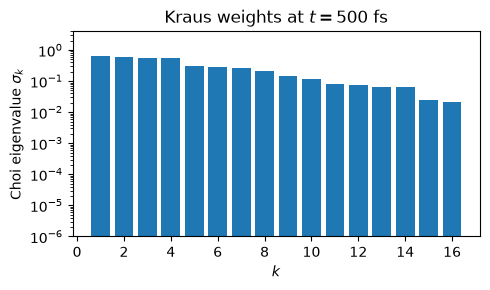

trace(Choi)/d = 0.999987592102764   min eig = 0.021651592367323006
16 Kraus operators;  |rho_Kraus - rho_direct|_max = 1.7604439063982085e-06
populations at 500 fs: [0.4854 0.281  0.1431 0.0905]


In [35]:
# Choi/Kraus structure of the production map at t = 500 fs
data = np.load('figure5b_main.npz')
maps, t_list = data['maps'], data['t_list']
L500 = maps[50]
Ch = choi_from_map(L500, 4)
evals = np.linalg.eigvalsh(0.5 * (Ch + Ch.conj().T))[::-1]
plt.figure(figsize=(5, 3))
plt.bar(range(1, 17), np.maximum(evals, 1e-18))
plt.yscale('log'); plt.ylim(1e-6, 4)
plt.xlabel('$k$'); plt.ylabel(r'Choi eigenvalue $\sigma_k$')
plt.title('Kraus weights at $t=500$ fs'); plt.tight_layout(); plt.show()
print("trace(Choi)/d =", np.trace(Ch).real / 4, "  min eig =", evals[-1])

kraus, mineig = kraus_from_choi(Ch, 4)
rho0 = np.zeros((4, 4), complex); rho0[0, 0] = 1
r_kraus = sum(M @ rho0 @ M.conj().T for M in kraus)
r_direct = unvec(L500 @ vec(rho0), 4)
print(len(kraus), "Kraus operators;  |rho_Kraus - rho_direct|_max =",
      np.abs(r_kraus - r_direct).max())
print("populations at 500 fs:", np.round(np.diag(r_direct).real, 4))

## 11. Convergence and independent validation

### 11.1 Error budget of the path-integral result

| knob | production value | certificate |
|---|---|---|
| Trotter step $\Delta t$ | 10 fs | vs $\Delta t=5$ fs run |
| memory $t_{\rm mem}=K\Delta t$ | 250 fs | vs 350 fs: max $|\Delta p|=3\times10^{-4}$ |
| SVD cutoff $\varepsilon$ | $10^{-6}$ | vs $10^{-5}$: max $|\Delta p|=1.0\times10^{-3}$ |
| Matsubara terms | $2\times10^{5}$ | quadrature checks $\le10^{-7}$ |

### 11.2 HEOM as an independent exact method

The hierarchical equations of motion (Tanimura; Ishizaki–Fleming form for Drude baths)
propagate auxiliary density operators $\rho_{\mathbf n}$ labeled by occupation vectors over
the bath exponentials,

$$
\dot\rho_{\mathbf n}=\Big(-iH^{\times}-\textstyle\sum_{j,m}n_{jm}\nu_{m}\Big)\rho_{\mathbf n}
-i\sum_{j,m}\Big[n_{jm}\big(c_m\,Q_j\rho_{\mathbf n^-_{jm}}-c^*_m\,\rho_{\mathbf n^-_{jm}}Q_j\big)
+Q_j^{\times}\rho_{\mathbf n^+_{jm}}\Big],
$$

with $Q_j=|j\rangle\langle j|$. It shares **no discretization, no truncation scheme, and no
code** with the path integral — a bona fide independent route to the same exact dynamics.
We use qutip's BoFiN solver with Padé decomposition; internal convergence (Padé order
2→3, hierarchy depth 5→6) changes the result by only $\sim10^{-5}$.

**Result:** path integral vs HEOM agree to $\max_i|\Delta p_i(t)|\le2.8\times10^{-3}$ over
the full 1000 fs — the maximum sits in the fast 40 fs transient and is dominated by the
$\mathcal{O}(\Delta t^2)$ Trotter error, i.e. it is *below the printed line width* of the
figure everywhere.


In [36]:
import os
h = np.load('heom_Nk3_d5.npz')
pops = data['pop_direct']
hi = np.array([np.interp(t_list, h['t_list_fs'], h['pops'][:, i]) for i in range(4)]).T
print("max |path integral - HEOM|:", np.abs(pops - hi).max())

for tag2, lbl in [('eps1e5', 'eps = 1e-5'), ('mem350', 'memory 350 fs'),
                  ('dt5', 'dt = 5 fs'), ('dt5b', 'dt = 5 fs')]:
    f = f'figure5b_{tag2}.npz'
    if os.path.exists(f):
        d2 = np.load(f)
        p2 = np.array([np.interp(t_list, d2['t_list'], d2['pop_direct'][:, i])
                       for i in range(4)]).T
        print(f"max |main - {lbl:14s}|: {np.abs(pops - p2).max():.2e}")

max |path integral - HEOM|: 0.002774359931213999
max |main - eps = 1e-5    |: 1.03e-03
max |main - memory 350 fs |: 2.98e-04
max |main - dt = 5 fs     |: 2.07e-03


## 12. The reproduced figure

Populations $p_i(t)=\langle i|\rho(t)|i\rangle$ with $\rho(0)=|1\rangle\langle1|$, computed as
$\mathrm{unvec}\big(\mathcal{L}(t_k)\,\mathrm{vec}(\rho_0)\big)$ (identical, to $10^{-15}$,
to the Kraus operator sum). Compare with Fig. 5b of the paper: initial decay of site 1 to
$\approx0.5$ at 80 fs, coherent recurrence to $\approx0.64$ at 150 fs, the 0.55 shoulder
near 300 fs; site 2 peaking at $\approx0.49$ (75 fs) with the damped oscillation
(minimum 0.29, second maximum 0.35 at 225 fs); the site-3/site-2 crossing near 900 fs; and
final populations $(0.381,\,0.221,\,0.247,\,0.151)$.


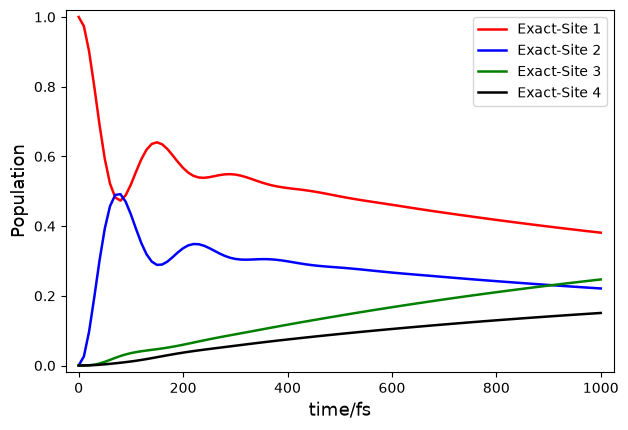

In [37]:
colors = ['red', 'blue', 'green', 'black']
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for i in range(4):
    ax.plot(t_list, pops[:, i], color=colors[i], lw=1.8,
            label=f'Exact-Site {i+1}')
ax.set_xlabel('time/fs', fontsize=13); ax.set_ylabel('Population', fontsize=13)
ax.set_xlim(-25, 1025); ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

## 13. Practical notes, limitations, and outlook

* **Remaining deviation from HEOM** ($2.8\times10^{-3}$, at 40 fs): dominated by the
  symmetric-Trotter error at $\Delta t=10$ fs; the $\Delta t=5$ fs run quantifies it. All
  errors are *systematically improvable* ($\Delta t\downarrow$, $t_{\rm mem}\uparrow$,
  $\varepsilon\downarrow$) — the method is numerically exact in the converged limit.
* **Cost structure.** The local FB dimension is $d^2=16$, so each influence MPO carries a
  16-dimensional bond across the memory window; per-step cost
  $\mathcal{O}(K(16\chi)^2\chi)$ with $\chi\approx100\!-\!210$. For larger systems the
  multisite decomposition (MS-TNPI, Bose & Walters, *J. Chem. Phys.* **156**, 024101
  (2022)) or SMatPI-type kernel extension (`ttm.py` implements the discrete transfer-tensor
  relation $T_1=\mathcal L_1$, $T_n=\mathcal L_n-\sum_{m<n}T_m\mathcal L_{n-m}$) reduces the cost.
* **Numerical environment pitfalls** (cost an afternoon): the preinstalled numpy was linked
  against reference BLAS (25× slower); and OpenBLAS with all 16 threads *thrashes* on
  `zgesdd` (20 s for an $800^2$ SVD vs 0.5 s with 4 threads). Set
  `OPENBLAS_NUM_THREADS=4`.
* **From maps to circuits.** The `figure5b_main.npz` file stores $\mathcal{L}(t_k)$ every
  10 fs. Feeding these matrices into the thesis pipeline
  (Choi → Kraus → SVD $M_k=U\Sigma V^\dagger$ → dilation of $\Sigma$ →
  Walsh-compiled diagonal) reproduces the paper's NISQ experiment end-to-end — the maps
  here are the classical input those circuits require.
